# Exploratory Data Analysis

In [42]:
"""
Read data from cleaned_data.csv that is generated by the data cleaning process,
and encode ordinal survey responses to numeric values based on the scales defined in the config.
"""

'\nRead data from cleaned_data.csv that is generated by the data cleaning process,\nand encode ordinal survey responses to numeric values based on the scales defined in the config.\n'

In [43]:
import sys
import warnings
import logging
from pathlib import Path
import numpy as np

import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from kmodes.kmodes import KModes
import math

sns.set_theme(style="white", context="notebook")


from blended_learning.config.settings import settings

warnings.filterwarnings("ignore")
logging.disable(logging.WARNING)

In [44]:
# read data
df = pd.read_csv(settings.path['output_cleaned_path'])

In [45]:
df.head(n=2)

,gender,age,is_itc_student,itc_campus,province,itc_student_id,education_level,department,faculty,academic_year,...,career_preparation,ideal_balance,prefer_more_blended,open_strengths,open_challenges_suggestions,survey_start,survey_end,response_time_minutes,student_id,flag_speeder
0,Male,36,True,ITC Phnom Penh (Main Campus),Phnom Penh,e20210528,Year5 - Final Year,GIC,NaN,2021–2022,...,2,"More Online than Face-to-Face (e.g., 40% In-pe...",No,NaN,NaN,2026-03-12 00:35:35.641,2026-03-12 00:37:43.468,2.130450,e20210528,True
1,Male,23,True,ITC Phnom Penh (Main Campus),Phnom Penh,e20210686,Year5 - Final Year,GIC,NaN,2025–2026,...,3,"More Online than Face-to-Face (e.g., 40% In-pe...",Neutral/Unsure,Nothing,Nothing,2026-03-17 18:53:40.435,2026-03-17 18:56:16.257,2.597033,e20210686,True


In [46]:
oridinal_cols = list(settings.ordinal_column_scales.keys())
pretty_columns = dict(settings.pretty_print_columns)
categorical_cols = list(settings.categorical_cols)
original_categorical_cols = list(settings.ordinal_categorical_cols)
numeric_vars = list(settings.numeric_vars)
multi_groups = dict(settings.multi_select_cols)

RANDOM_STATE = 42

def pl(col):
    return pretty_columns.get(col, col.replace('_', ' ').title())

## 1 Data quality notes

In [47]:
print("=" * 60)
print("DATA QUALITY NOTES".center(60))
print("=" * 60)
print("Total number of rows: ", len(df))
print(f"Faculty         : {df['faculty'].isna().sum()}/{len(df)}")
print(f"department      : {df['department'].isna().sum()}")
print(f"Non duration    : {df['response_time_minutes'].isna().sum()} — KoboToolbox offline mode")
print(f"Duration > 24h  : {(df['response_time_minutes'] > 24 * 60).sum()} rows — tab left open, not active completion")
print(f"Under 3 min     : {df['flag_speeder'].sum()} rows — likely not a serious response")
print(f"Anomaly         : {(~df['is_itc_student']).sum()} — likely not a itc student")
print(f"ordinal         : {len(settings.ordinal_column_scales.keys())} columns")


                     DATA QUALITY NOTES                     
Total number of rows:  588
Faculty         : 557/588
department      : 31
Non duration    : 258 — KoboToolbox offline mode
Duration > 24h  : 8 rows — tab left open, not active completion
Under 3 min     : 2 rows — likely not a serious response
Anomaly         : 31 — likely not a itc student
ordinal         : 33 columns


### Data quality : Missing Data Analysis

A. Missingness matrix

Good for seeing where values are missing row by row.

<Figure size 1680x720 with 0 Axes>

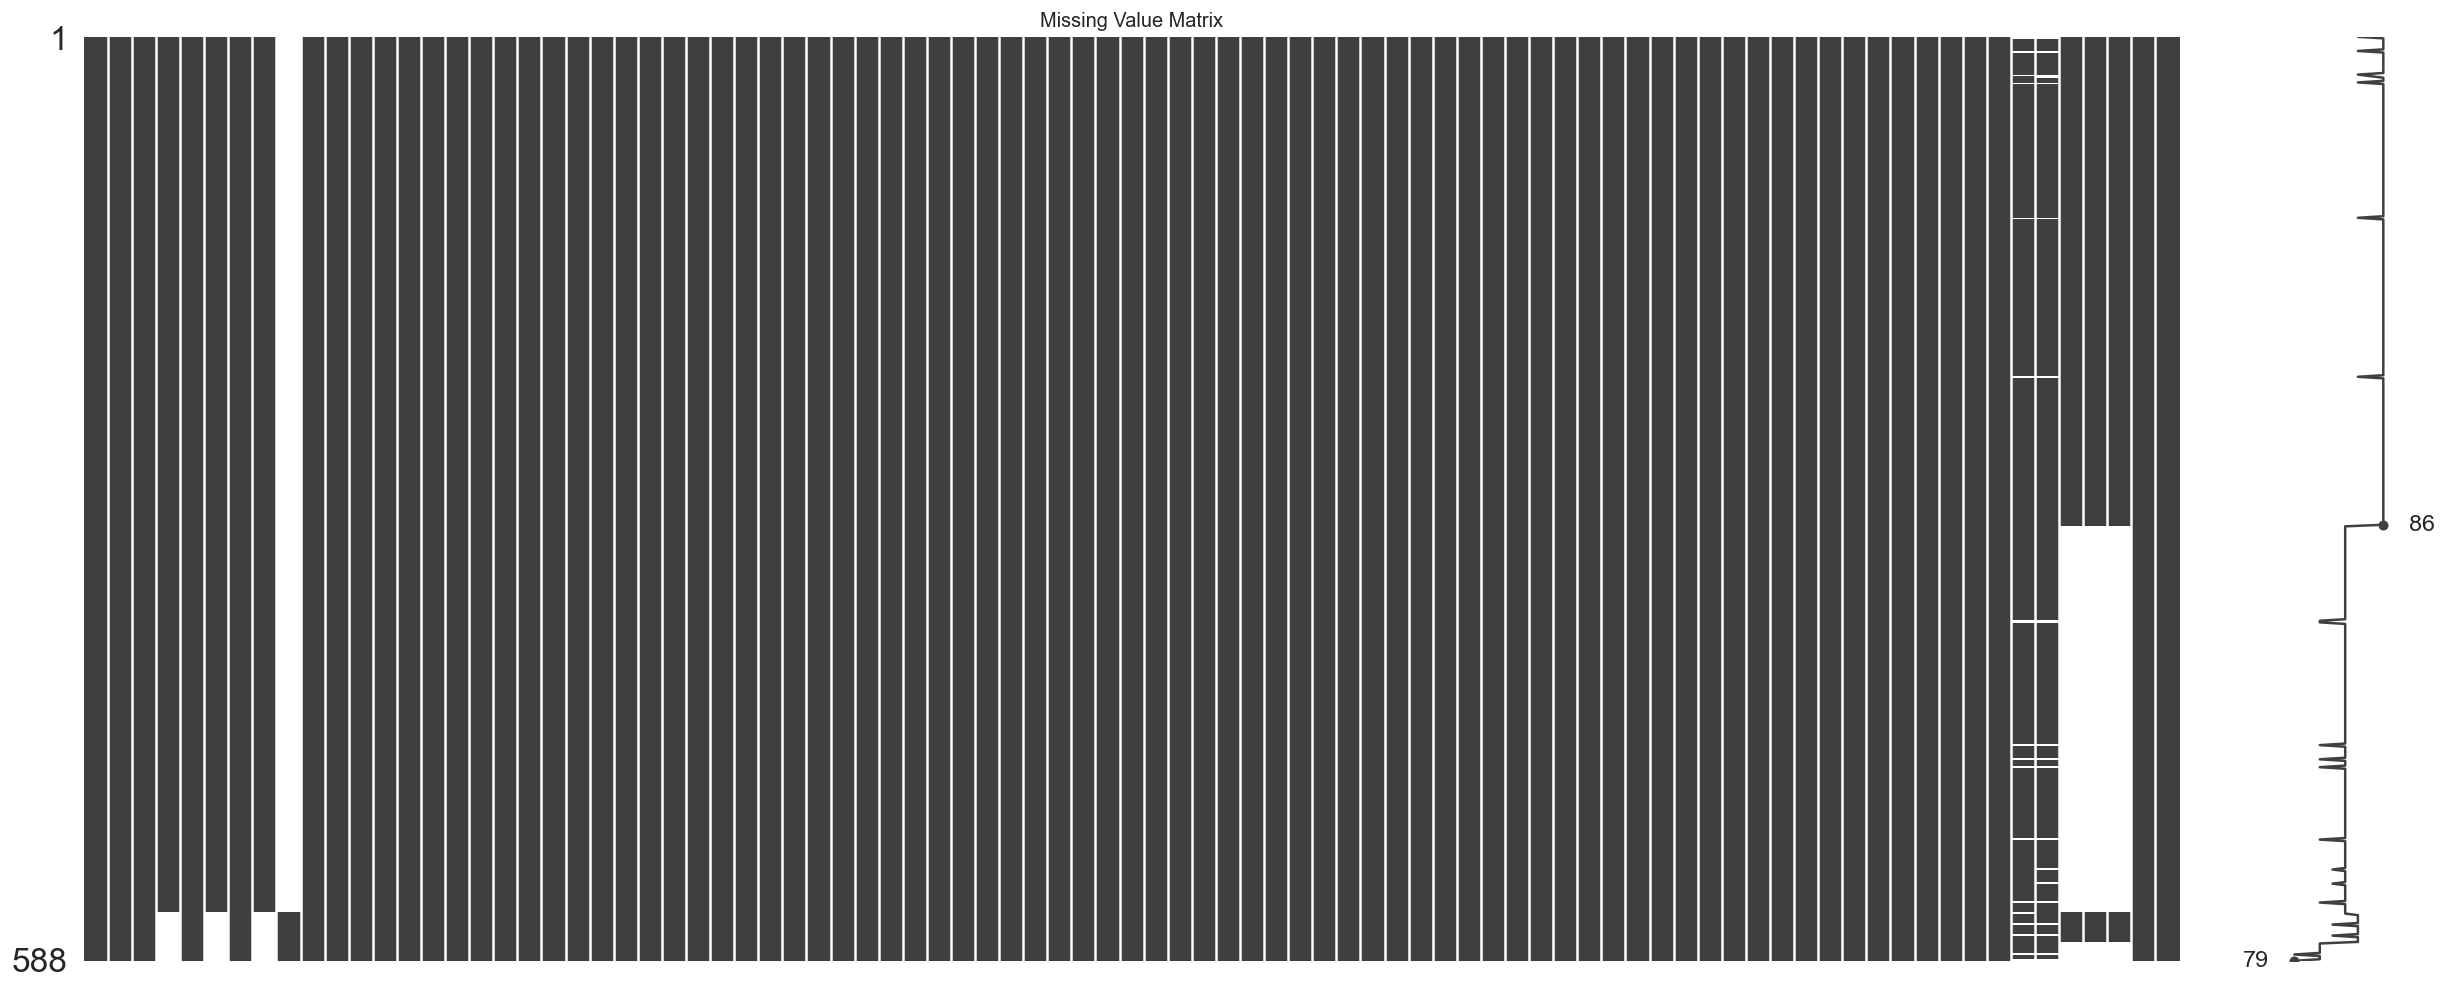

In [48]:
plt.figure(figsize=(14, 6))
msno.matrix(df)
plt.title("Missing Value Matrix")
plt.show()

In [49]:
for key, value in df.isnull().sum().items():
    if value > 0:
        print(f"{key}: {value} missing values")

itc_campus: 31 missing values
itc_student_id: 31 missing values
department: 31 missing values
faculty: 557 missing values
open_strengths: 18 missing values
open_challenges_suggestions: 20 missing values
survey_start: 258 missing values
survey_end: 258 missing values
response_time_minutes: 258 missing values


B. Missingness bar chart

Good for seeing how many non-missing values each column has.

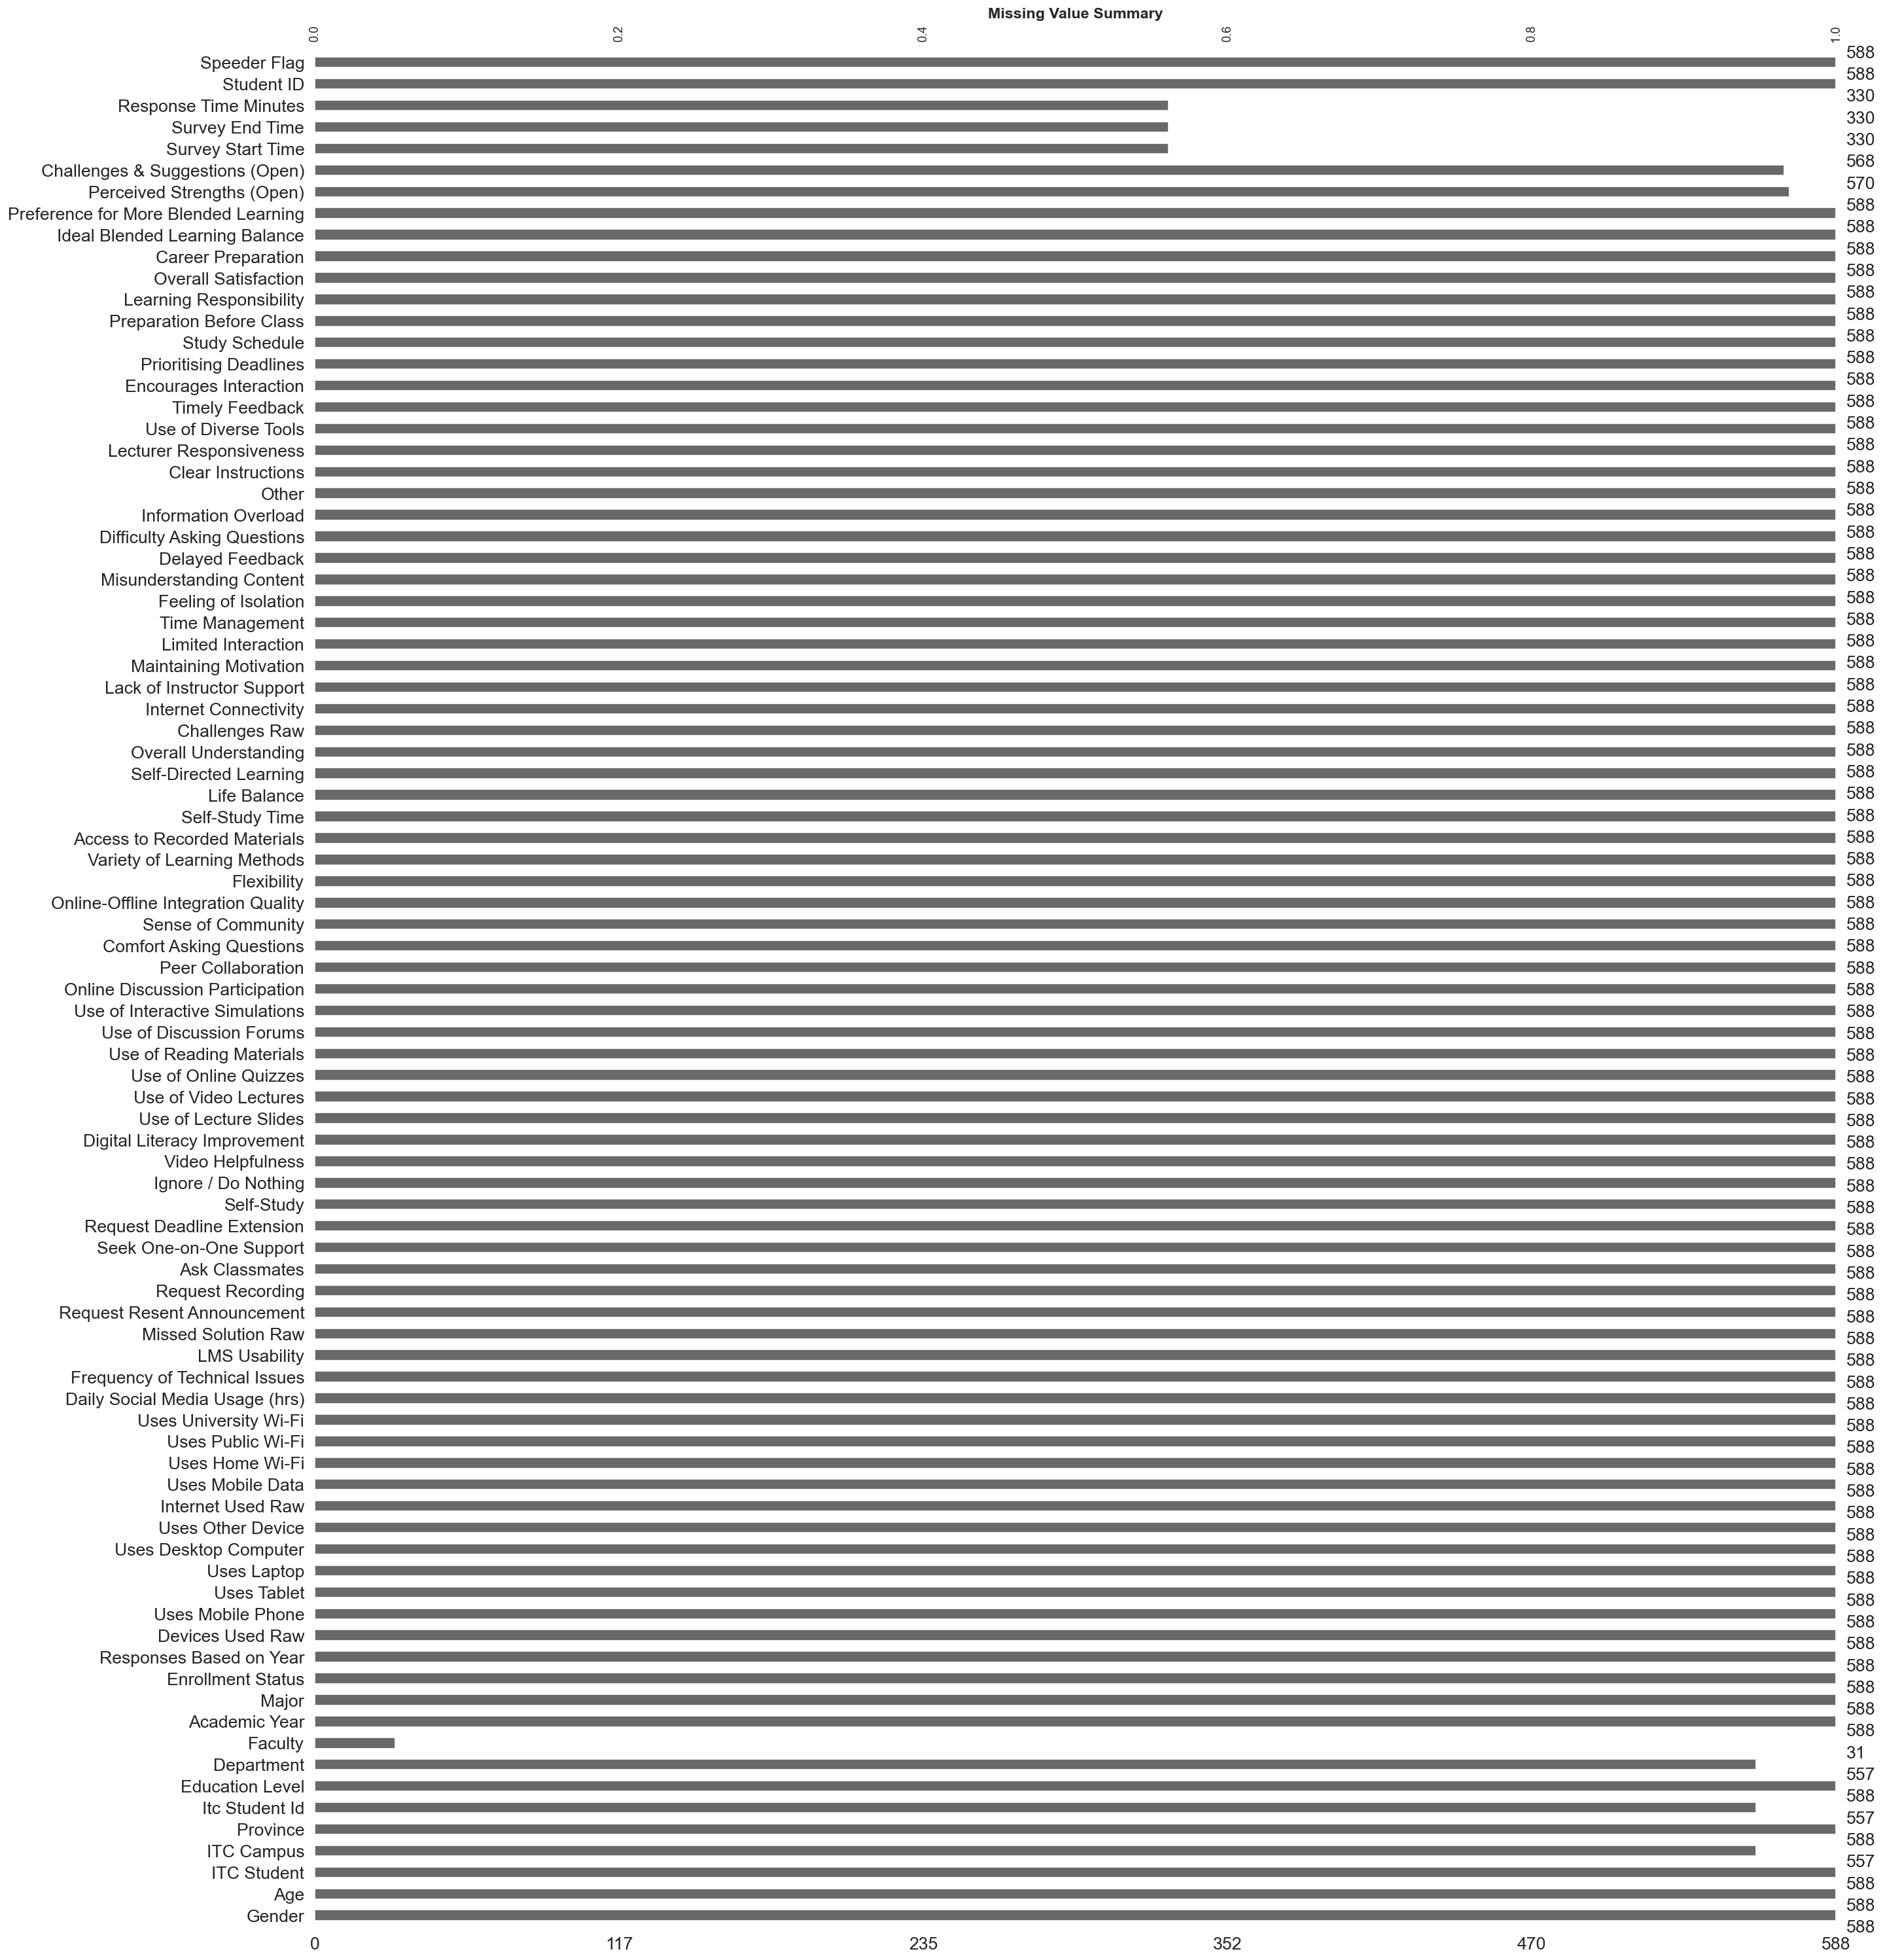

In [50]:
plt.figure(figsize=(14, 6))

# rename columns using pl() function ( pretty label)
df_pretty = df.rename(columns=lambda x: pl(x))

msno.bar(df_pretty)

plt.title("Missing Value Summary", fontsize=14, fontweight='bold')
plt.xticks(rotation=90)  # rotate labels for readability
plt.show()

C. Missingness heatmap

Good for seeing whether missingness in some columns is related to others.

<Figure size 1440x960 with 0 Axes>

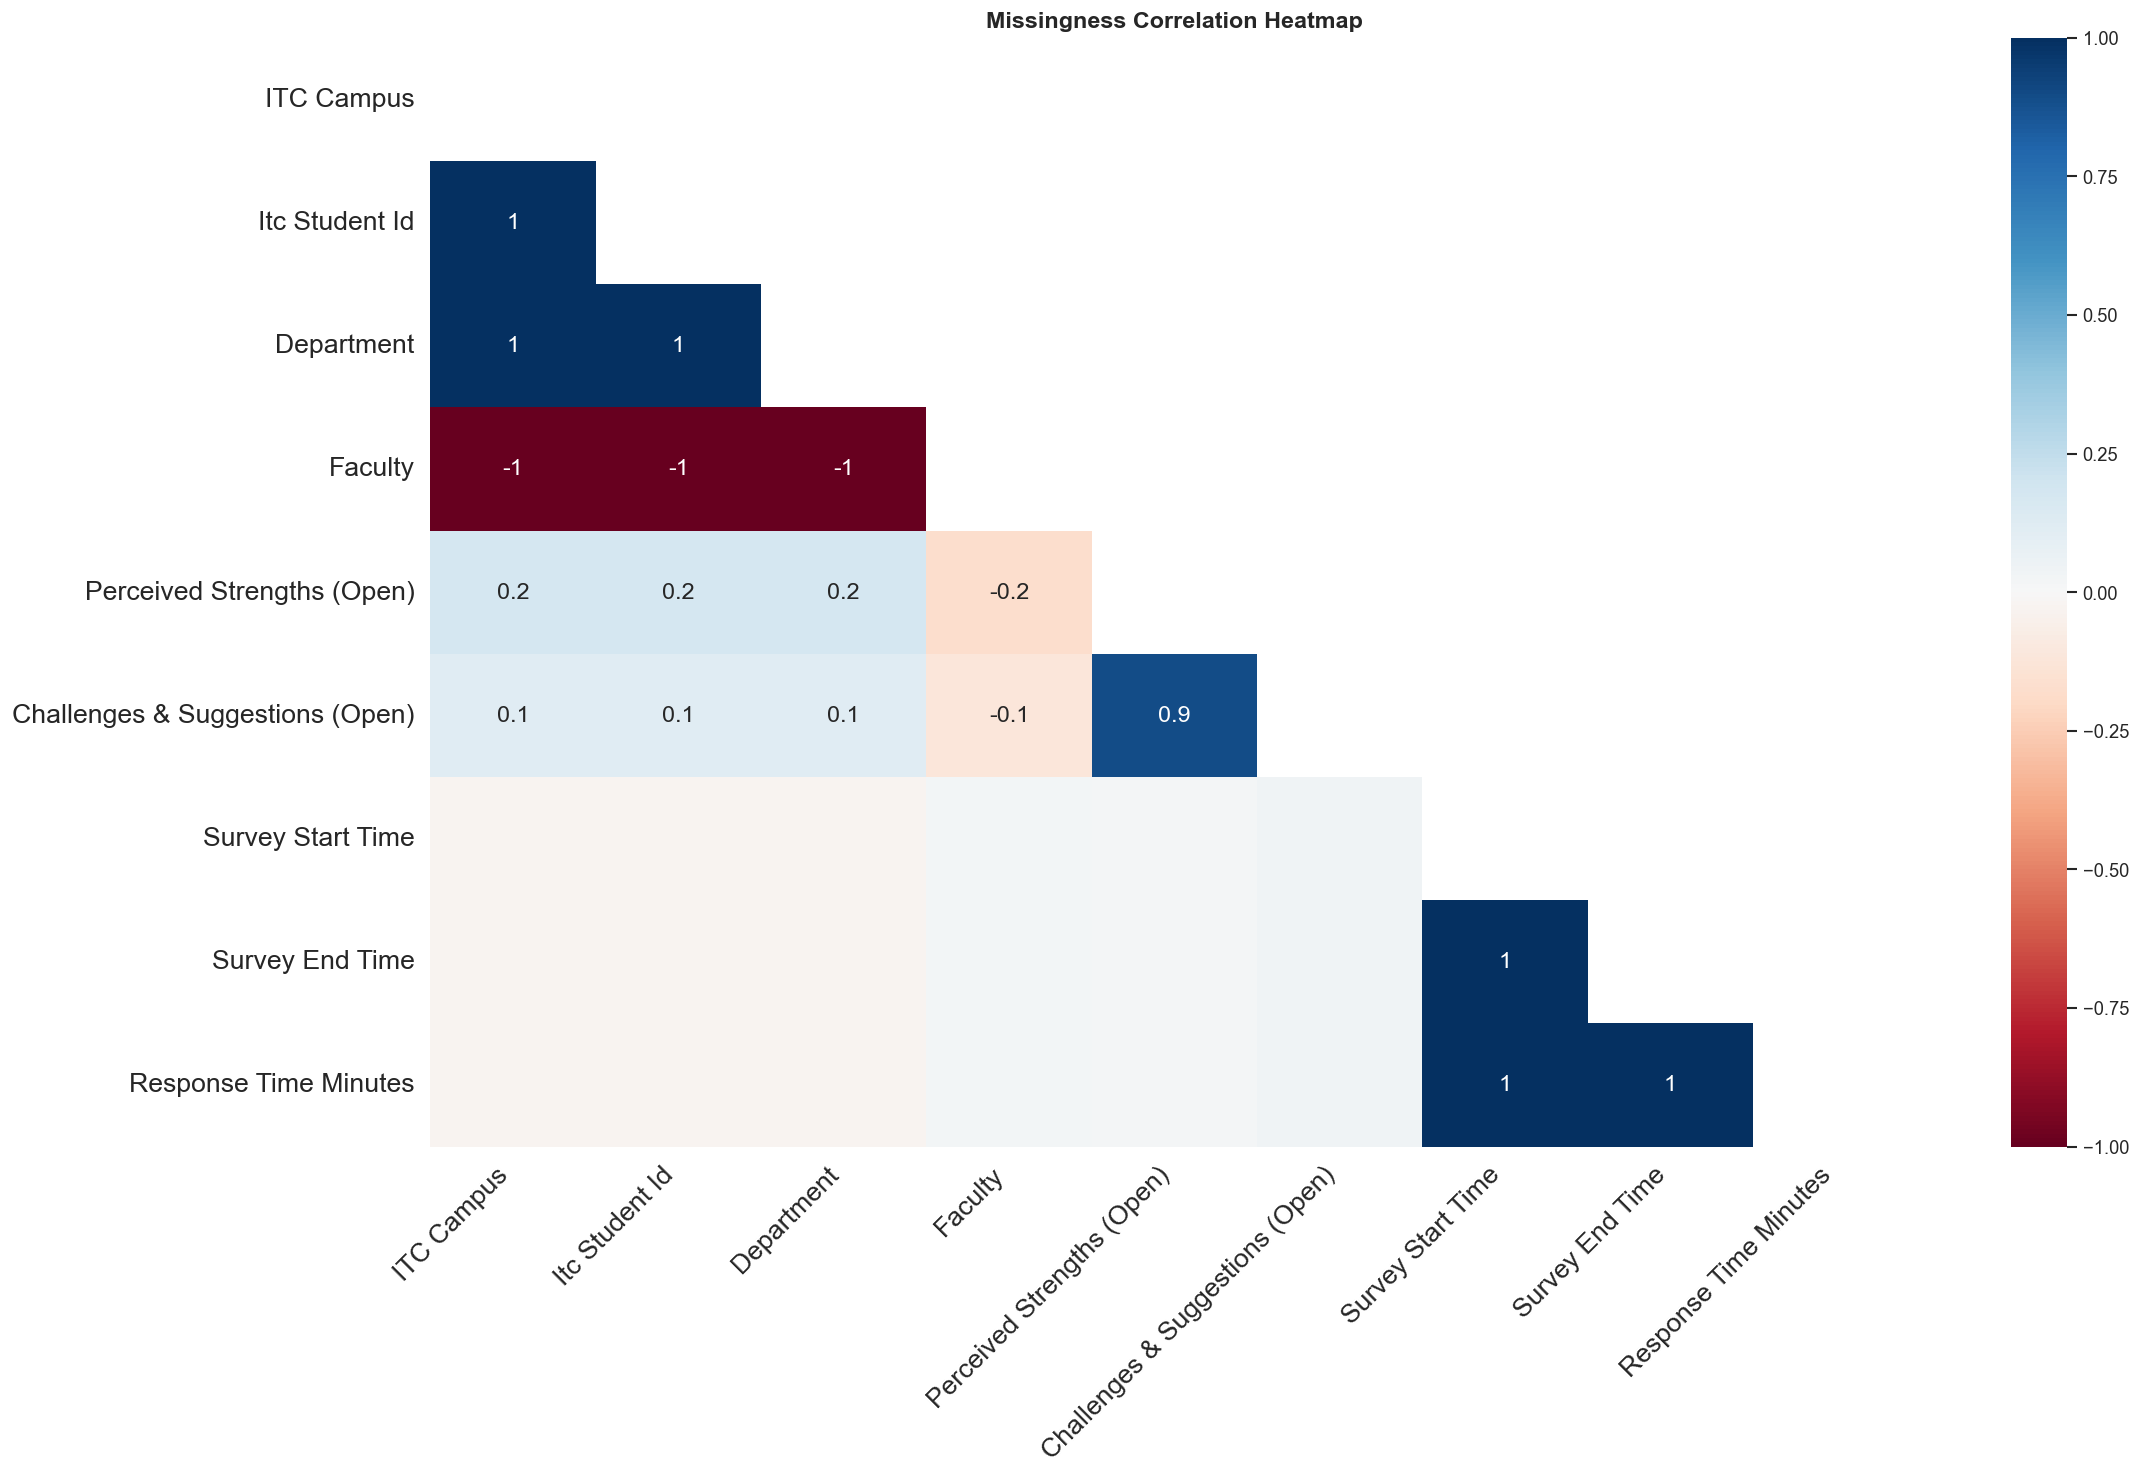

In [51]:
plt.figure(figsize=(12, 8))

msno.heatmap(df_pretty)

plt.title("Missingness Correlation Heatmap", fontsize=14, fontweight='bold')
plt.show()

**Note:** The heatmap shows correlations in missing values (not actual data values). 
Strong positive correlations indicate variables that are missing together, while 
negative correlations indicate mutually exclusive missingness. The observed patterns 
suggest structural missingness (e.g., ITC vs non-ITC students) rather than random 
data quality issues.

A. Missingness for clustering inputs only

This is probably the most important one for Chapter 6.

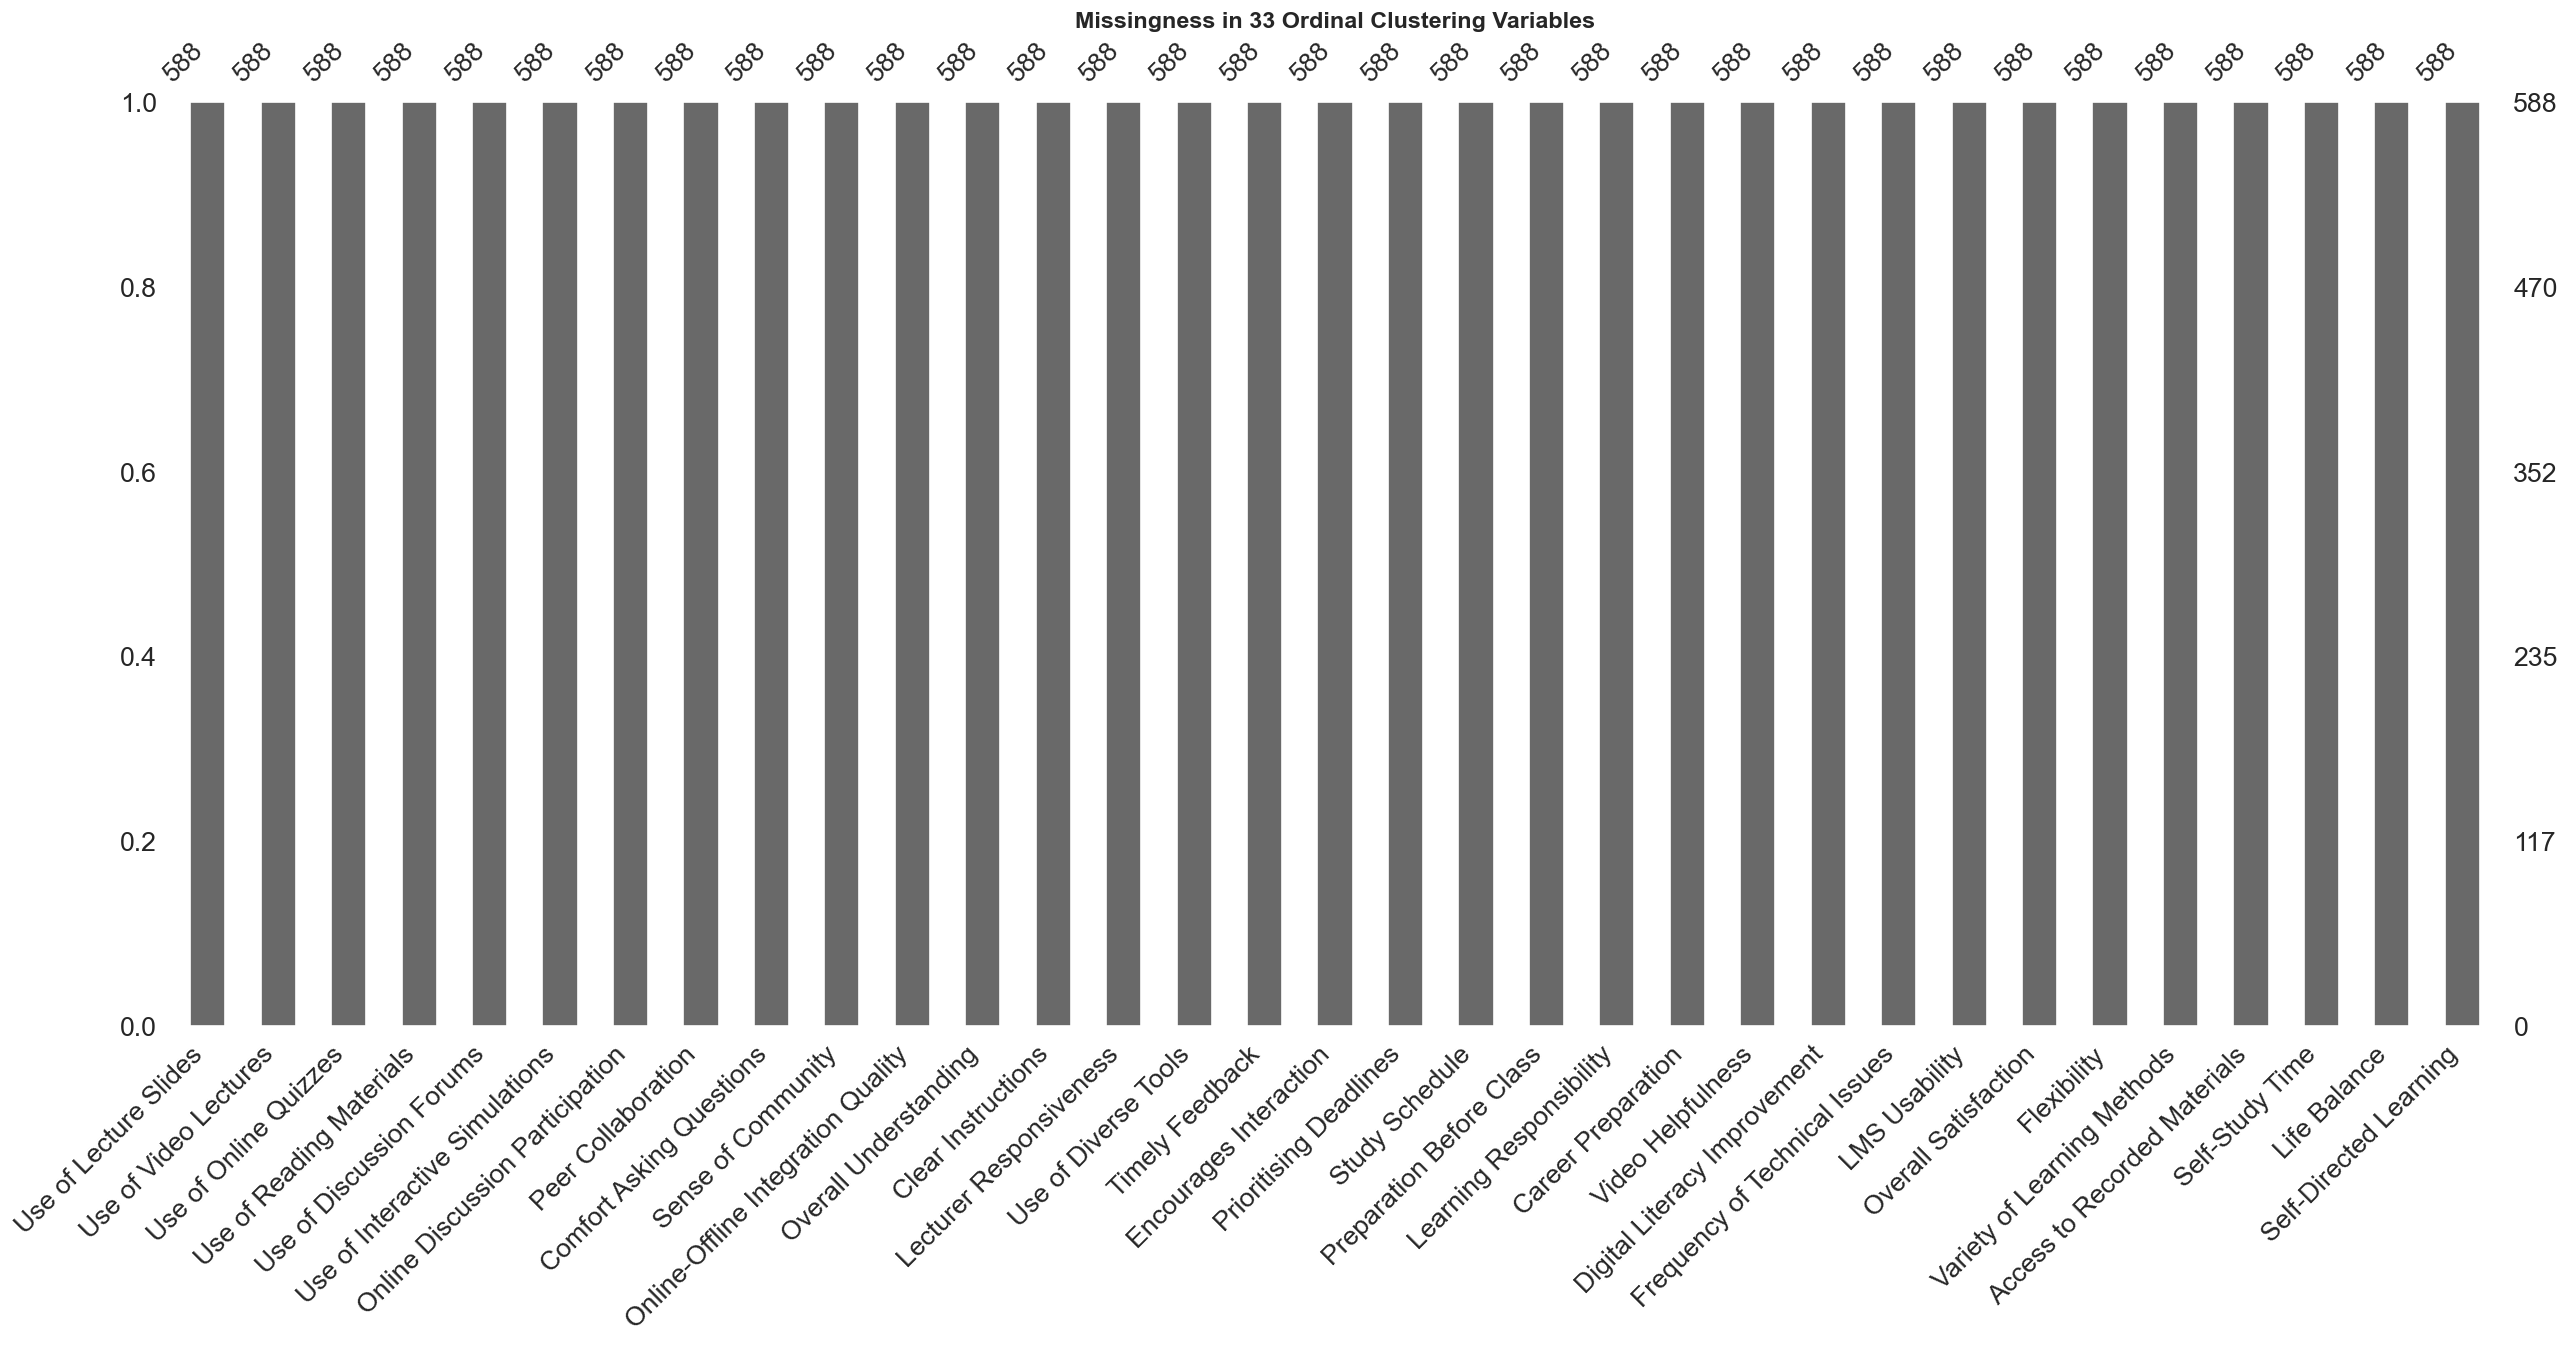

In [52]:
plt.figure(figsize=(12, 5))

df_pretty = df[oridinal_cols].rename(columns=lambda x: pl(x))

msno.bar(df_pretty)

plt.title("Missingness in 33 Ordinal Clustering Variables", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.show()

### Data Quality Assessment: Survey Completion Time

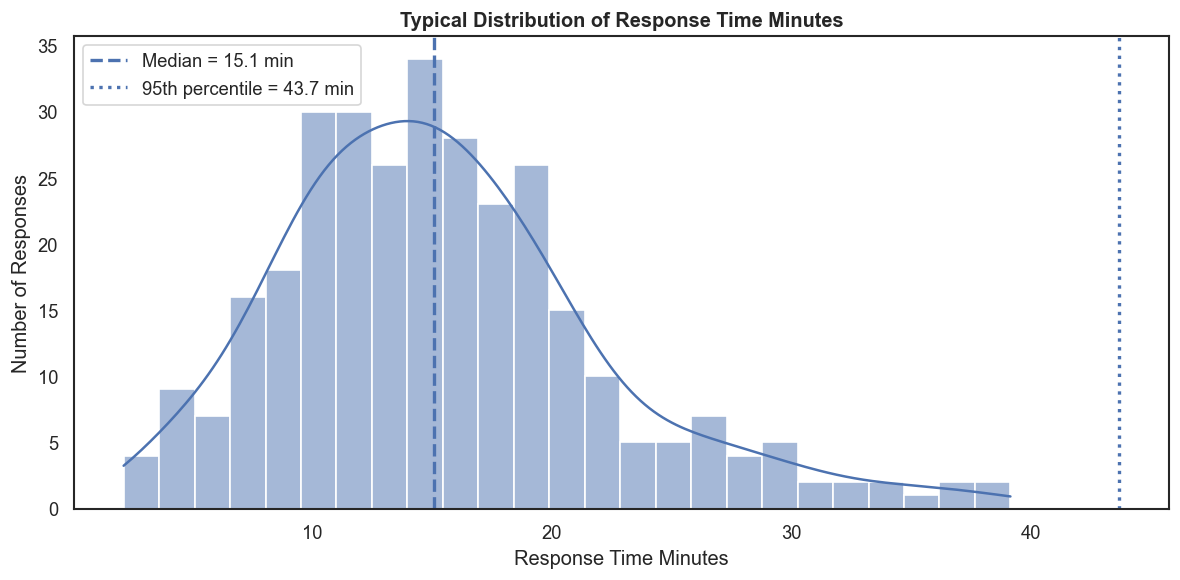

Median duration: 15.10 minutes
95th percentile duration: 43.67 minutes
Responses above 95th percentile: 17


In [53]:
duration_col = "response_time_minutes"
label = pl(duration_col)

# Keep valid duration values
duration_df = df[df[duration_col].notna()].copy()


# Use 95th percentile to focus on typical completion time
upper_95 = duration_df[duration_col].quantile(0.95)
duration_typical = duration_df[duration_df[duration_col] <= upper_95].copy()

plt.figure(figsize=(10, 5))

sns.histplot(
    data=duration_typical,
    x=duration_col,
    bins=25,
    kde=True
)

plt.axvline(
    duration_df[duration_col].median(),
    linestyle="--",
    linewidth=2,
    label=f"Median = {duration_df[duration_col].median():.1f} min"
)

plt.axvline(
    upper_95,
    linestyle=":",
    linewidth=2,
    label=f"95th percentile = {upper_95:.1f} min"
)

plt.title(f"Typical Distribution of {label}", fontweight="bold")
plt.xlabel(label)
plt.ylabel("Number of Responses")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Median duration: {duration_df[duration_col].median():.2f} minutes")
print(f"95th percentile duration: {upper_95:.2f} minutes")
print(f"Responses above 95th percentile: {(duration_df[duration_col] > upper_95).sum()}")

The distribution of survey completion time is moderately right-skewed. The median completion time is approximately 15 minutes, indicating that most respondents completed the survey within a reasonable duration. The majority of responses fall below the 95th percentile (around 36 minutes), suggesting that extreme durations are limited and likely caused by respondents leaving the survey open rather than actively completing it.

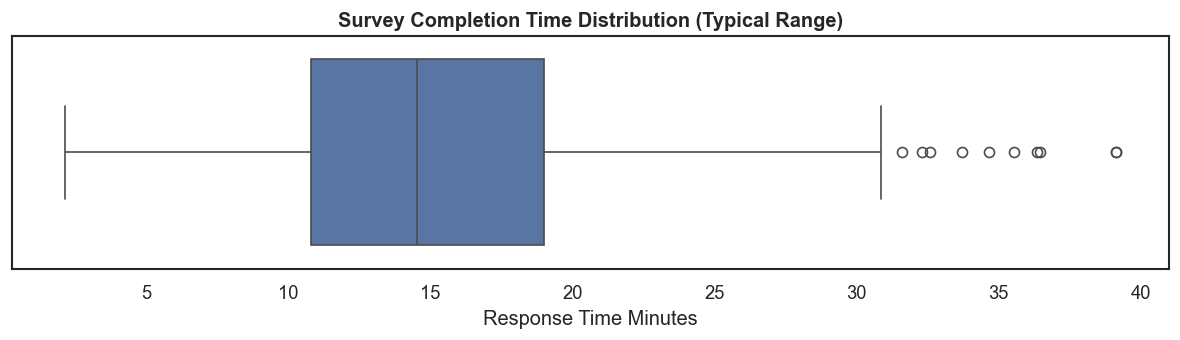

In [54]:
# Remove extreme values using 95th percentile
upper_95 = duration_df[duration_col].quantile(0.95)
duration_typical = duration_df[duration_df[duration_col] <= upper_95]

plt.figure(figsize=(10, 3))

sns.boxplot(
    data=duration_typical,
    x=duration_col
)

plt.title("Survey Completion Time Distribution (Typical Range)", fontweight="bold")
plt.xlabel(pl(duration_col))

plt.tight_layout()
plt.show()

The typical survey completion time ranges approximately between 10 and 20 minutes, with a median around 15 minutes. A small number of higher values (above 30 minutes) are observed, but these remain within a reasonable range compared to extreme outliers removed earlier. This indicates that most respondents completed the survey within a consistent and realistic time frame.

## 2 Exploratory Data Analysis

This chapter covers univariate distributions (demographic and Likert variables) and bivariate relationships between key demographic groups and outcome variables.

In [55]:
from scipy.stats import skew
sns.set_theme(style="white", context="talk")
plt.rcParams['axes.grid'] = False

def pct(x):
    return x.value_counts(dropna=False, normalize=True).mul(100)

def missing_summary(df):
    out = pd.DataFrame({
        'missing_n': df.isna().sum(),
        'missing_pct': df.isna().mean() * 100,
        'dtype': df.dtypes.astype(str)
    }).sort_values(['missing_pct', 'missing_n'], ascending=False)
    return out

def add_barh_labels(ax, offset=0.4, fmt='{:.1f}%'):
    for p in ax.patches:
        w = p.get_width()
        y = p.get_y() + p.get_height()/2
        ax.text(w + offset, y, fmt.format(w), va='center', fontsize=10)

def add_bar_labels(ax, fmt='{:.1f}%'):
    for p in ax.patches:
        h = p.get_height()
        x = p.get_x() + p.get_width()/2
        ax.text(x, h + 0.8, fmt.format(h), ha='center', va='bottom', fontsize=9)

In [56]:
X = df[oridinal_cols]
summary = X.describe()
display(summary)

,use_lecture_slides,use_video_lectures,use_quizzes,use_articles,use_forums,use_simulations,online_discussion_participation,peer_collaboration,comfort_asking_questions,sense_of_community,...,digital_literacy_improvement,tech_issues_freq,lms_usability,overall_satisfaction,benefit_flexibility,benefit_variety,benefit_recorded_access,benefit_self_study_time,benefit_life_balance,benefit_self_directed
count,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,...,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000
mean,4.093537,3.309524,3.636054,3.064626,2.998299,2.812925,2.887755,3.343537,3.394558,3.215986,...,3.396259,3.318027,3.423469,3.484694,3.692177,3.619048,3.925170,3.943878,3.668367,3.797619
std,0.892764,1.063300,0.904386,0.948004,1.102111,1.119307,0.994527,0.994538,0.815588,0.787000,...,0.936367,0.911341,0.784818,0.781889,0.777981,0.798920,0.872354,0.860993,0.858202,0.803439
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4.000000,3.000000,3.000000,3.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
75%,5.000000,4.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


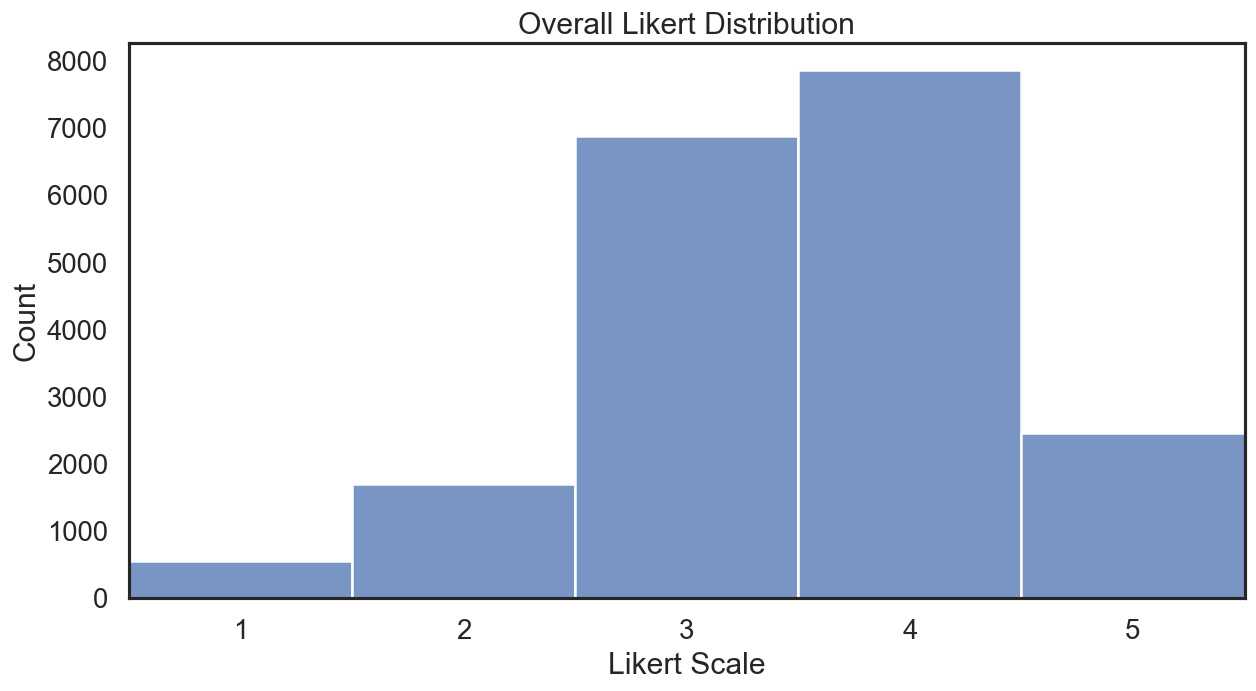

In [57]:
# Overall response tendency across ALL 33 variables and ALL students
plt.figure(figsize=(12, 6))

sns.histplot(
    X.values.flatten(),
    bins=np.arange(0.5, 6, 1),   # bins centered on 1,2,3,4,5
    discrete=True
)

plt.title("Overall Likert Distribution")
plt.xlabel("Likert Scale")
plt.ylabel("Count")
plt.xticks([1, 2, 3, 4, 5])
plt.xlim(0.5, 5.5)

plt.show()

Missingness and data quality

,missing_n,missing_pct,dtype
faculty,557,94.73,str
survey_start,258,43.88,str
survey_end,258,43.88,str
response_time_minutes,258,43.88,float64
itc_campus,31,5.27,str
itc_student_id,31,5.27,str
department,31,5.27,str
open_challenges_suggestions,20,3.40,str
open_strengths,18,3.06,str
gender,0,0.00,str


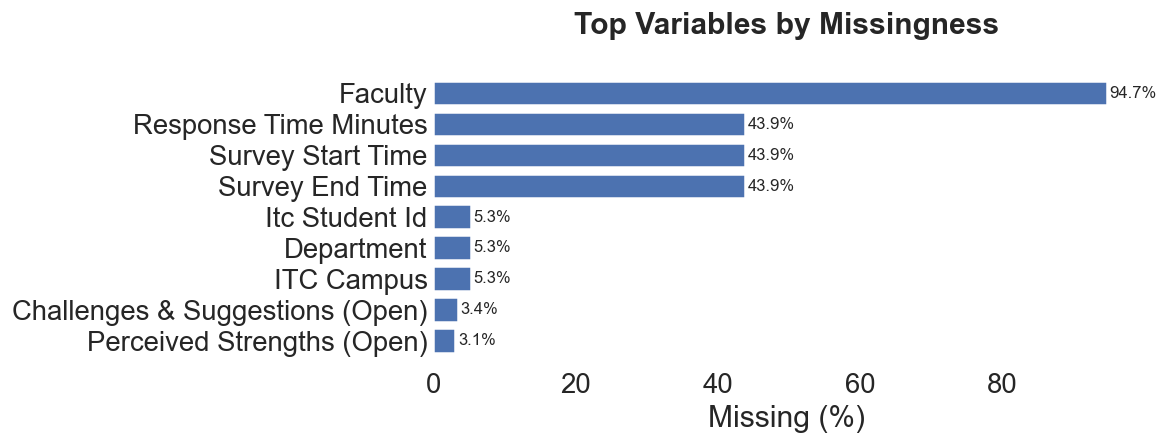


=== Data quality indicators ===
Speeders flagged        : 2
ID anomalies flagged    : 31
count       330.00
mean       1290.62
std       10843.90
min           2.13
25%          10.97
50%          15.10
75%          19.55
max      111858.34
Name: response_time_minutes, dtype: float64


In [58]:
miss_tbl = missing_summary(df)
display(miss_tbl.head(20).round(2))

miss_nonzero = miss_tbl[miss_tbl["missing_n"] > 0].copy()

if not miss_nonzero.empty:
    top_miss = (
        miss_nonzero
        .head(15)
        .sort_values("missing_pct", ascending=True)
    )

    fig, ax = plt.subplots(
        figsize=(10, max(4, len(top_miss) * 0.45))
    )

    ax.barh(
        [pl(c) for c in top_miss.index],
        top_miss["missing_pct"]
    )

    add_barh_labels(ax)

    ax.set_xlabel("Missing (%)")

    ax.set_title(
        "Top Variables by Missingness",
        fontweight="bold",
        pad=20
    )

    # Remove grid
    ax.grid(False)

    # Remove bounding box
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Remove tick marks
    ax.tick_params(axis="both", length=0)

    plt.tight_layout()
    plt.show()

else:
    print("No missing values detected.")


# Data quality check for metadata variables if present
quality_flags = [
    c for c in [
        "flag_speeder",
        "flag_id_anomaly",
        "response_time_minutes"
    ]
    if c in df.columns
]

if quality_flags:
    print("\n=== Data quality indicators ===")

    if "flag_speeder" in df.columns:
        print(f"Speeders flagged        : {int(df['flag_speeder'].sum())}")

    if "is_itc_student" in df.columns:
        print(f"ID anomalies flagged    : {int((~df['is_itc_student']).sum())}")

    if "response_time_minutes" in df.columns:
        print(df["response_time_minutes"].describe().round(2))

Numeric variables

=== Numeric descriptive statistics ===


,count,mean,median,std,min,max,skewness
age,588,20.31,20.0,2.27,17,43,3.77


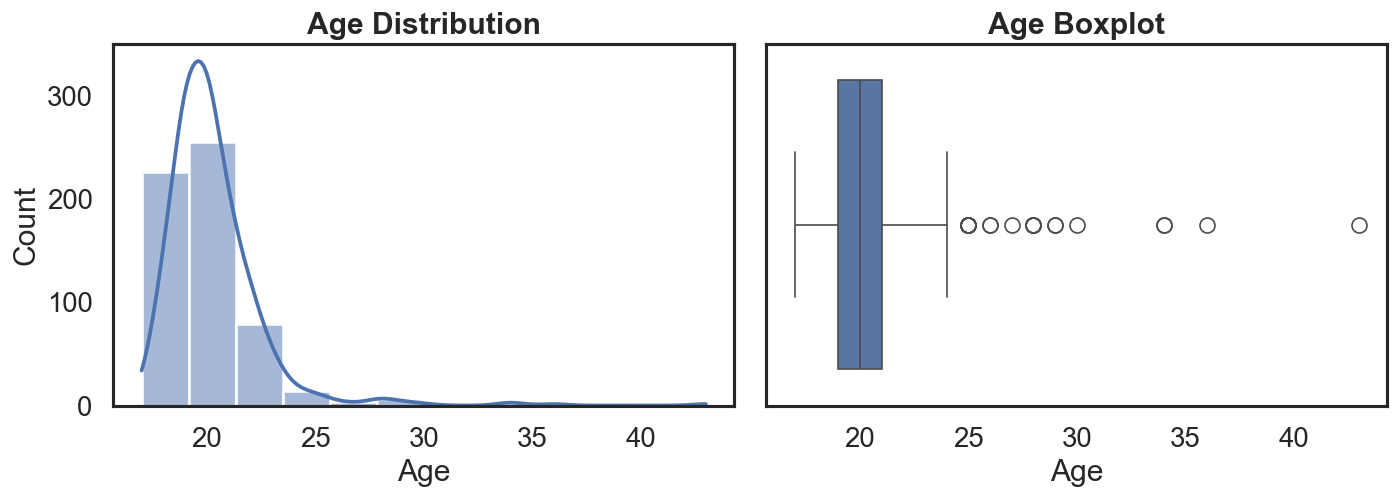

In [59]:
# ── 3.1.2 Numeric variables ───────────────────────────────────────────────────
numeric_vars = settings.numeric_vars
if numeric_vars:
    num_desc = pd.DataFrame({
        'count': df[numeric_vars].count(),
        'mean': df[numeric_vars].mean(),
        'median': df[numeric_vars].median(),
        'std': df[numeric_vars].std(),
        'min': df[numeric_vars].min(),
        'max': df[numeric_vars].max(),
        'skewness': df[numeric_vars].apply(lambda s: skew(s.dropna()) if s.dropna().shape[0] > 2 else np.nan)
    }).round(2)

    print("=== Numeric descriptive statistics ===")
    display(num_desc)

    for col in numeric_vars:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

        sns.histplot(df[col].dropna(), bins=12, kde=True, ax=axes[0])
        axes[0].set_title(f'{pl(col)} Distribution', fontweight='bold')
        axes[0].set_xlabel(pl(col))

        sns.boxplot(x=df[col].dropna(), ax=axes[1])
        axes[1].set_title(f'{pl(col)} Boxplot', fontweight='bold')
        axes[1].set_xlabel(pl(col))

        plt.tight_layout()
        plt.show()


=== Gender ===


,count,percent
Male,387,65.8
Female,192,32.7
Prefer Not To Say,9,1.5


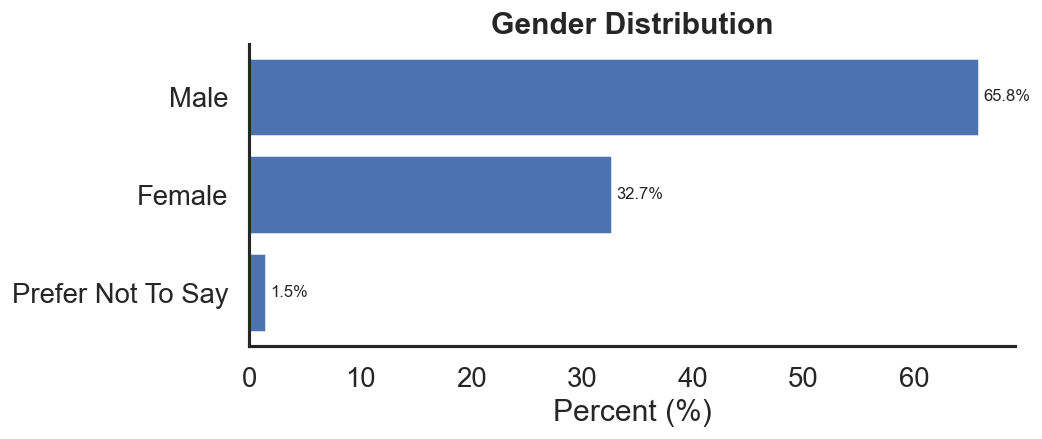


=== ITC Student ===


,count,percent
True,557,94.7
False,31,5.3


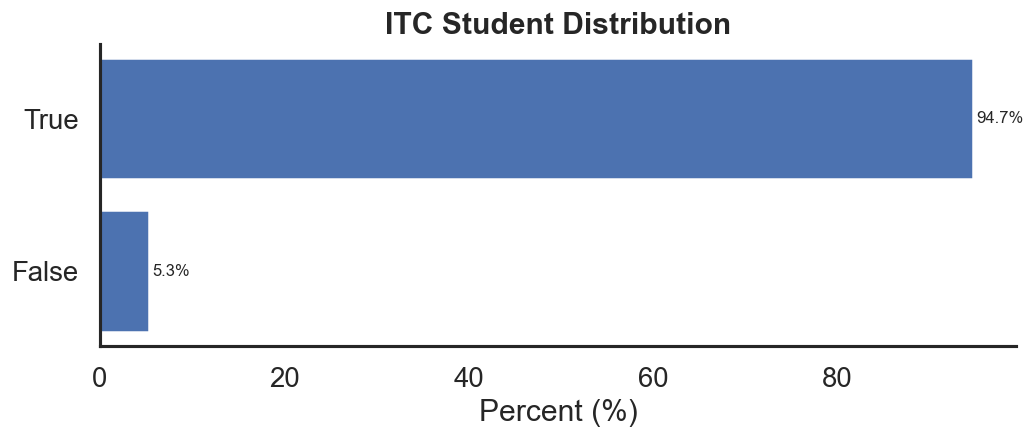


=== Education Level ===


,count,percent
Year2 - Sophomore,309,52.6
Year3 - Junior,89,15.1
Year4 - Senior,80,13.6
Year5 - Final Year,54,9.2
Year1 - Freshman,23,3.9
Master,21,3.6
Other,11,1.9
PHD,1,0.2


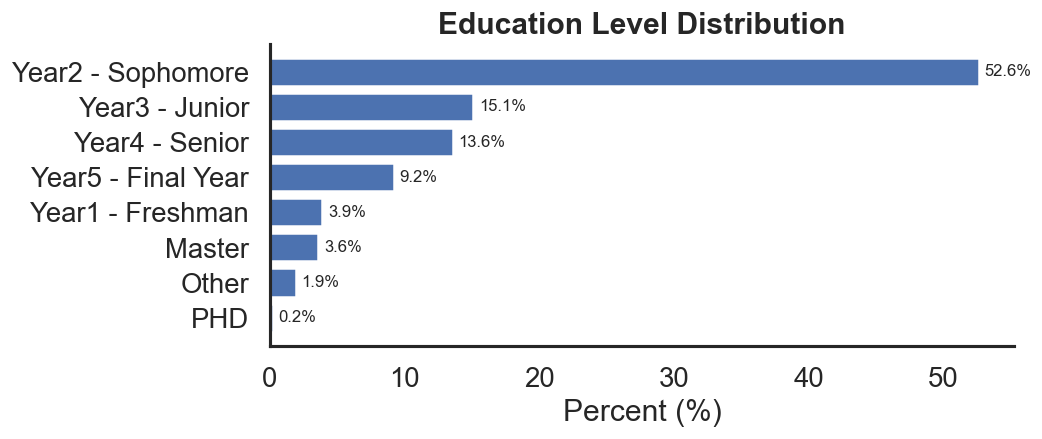


=== Major ===


,count,percent
Engineering,209,35.5
Data Science,177,30.1
Computer Science / IT,80,13.6
Software Engineering,45,7.7
Other,33,5.6
Cybersecurity,28,4.8
Finance,9,1.5
Education,2,0.3
Medicine / Health Sciences,2,0.3
Accounting,1,0.2


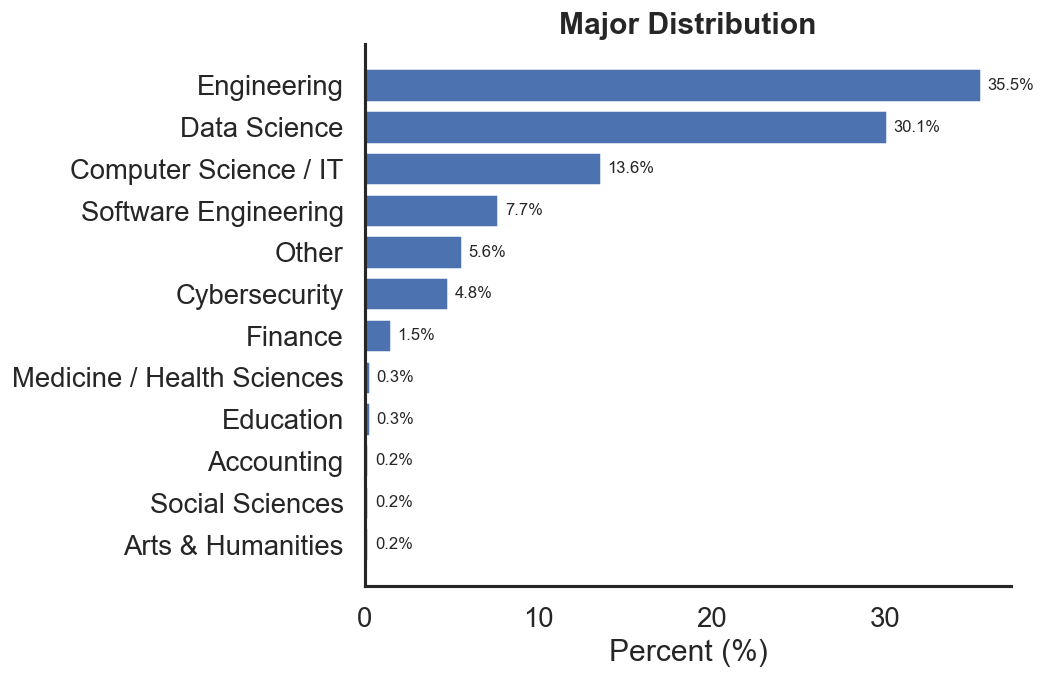


=== Department ===


,count,percent
AMS,165,28.1
GIC,113,19.2
GEE,59,10.0
Foundation Year,54,9.2
GIM,51,8.7
GAR,40,6.8
Missing,31,5.3
GRU,26,4.4
GTR,23,3.9
GCI,10,1.7


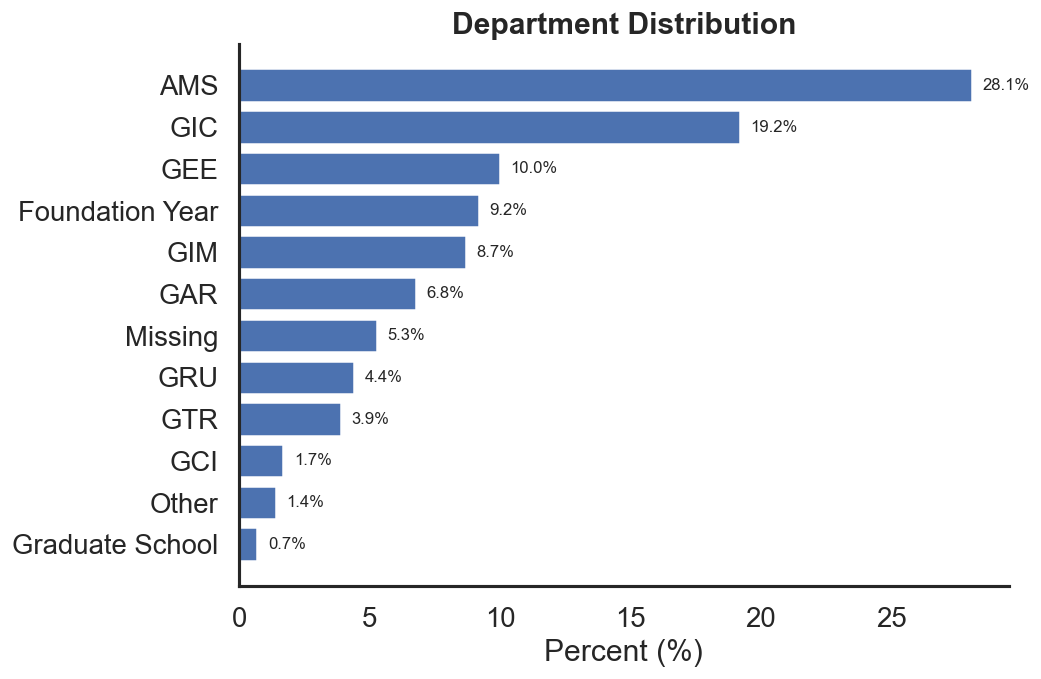


=== Province ===


,count,percent
Phnom Penh,579,98.5
Other,6,1.0
Kep,1,0.2
Tboung Khmum,1,0.2
Battambang,1,0.2


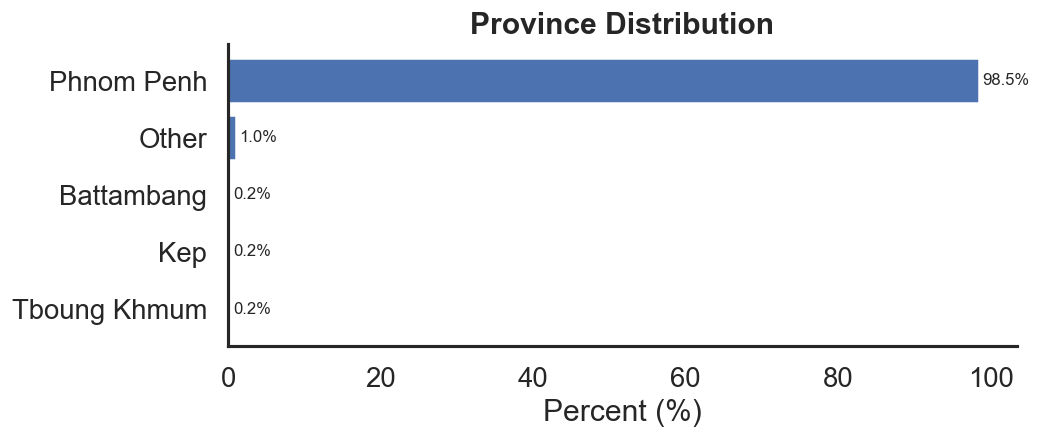


=== ITC Campus ===


,count,percent
ITC Phnom Penh (Main Campus),556,94.6
Missing,31,5.3
ITC Kep Campus,1,0.2


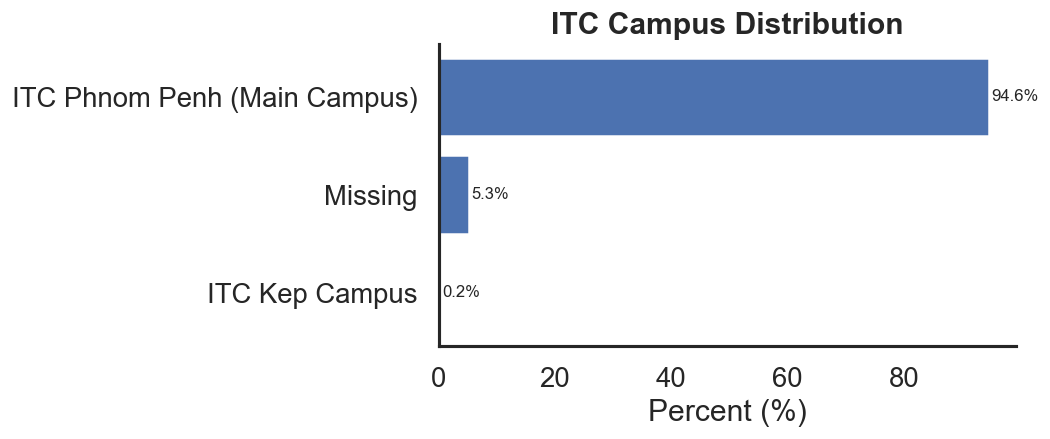


=== Ideal Blended Learning Balance ===


,count,percent
"Mostly Face-to-Face (e.g., 80% In-person, 20% Online)",240,40.8
"More Face-to-Face than Online (e.g., 60% In-person, 40% Online)",169,28.7
"Balanced Half and Half (50% In-person, 50% Online)",124,21.1
"More Online than Face-to-Face (e.g., 40% In-person, 60% Online)",37,6.3
"Mostly Online (e.g., 20% In-person, 80% Online)",18,3.1


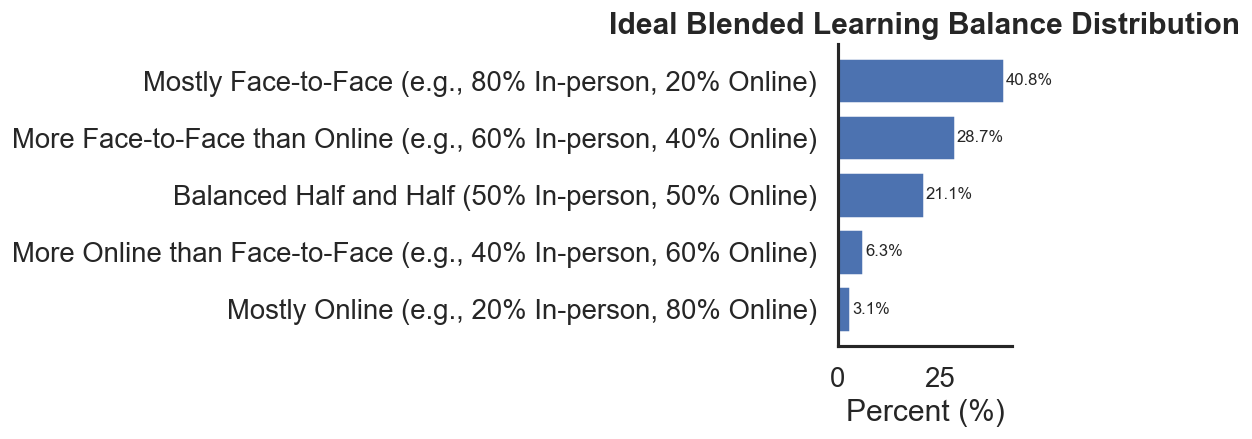


=== Preference for More Blended Learning ===


,count,percent
Yes,319,54.3
Neutral/Unsure,242,41.2
No,27,4.6


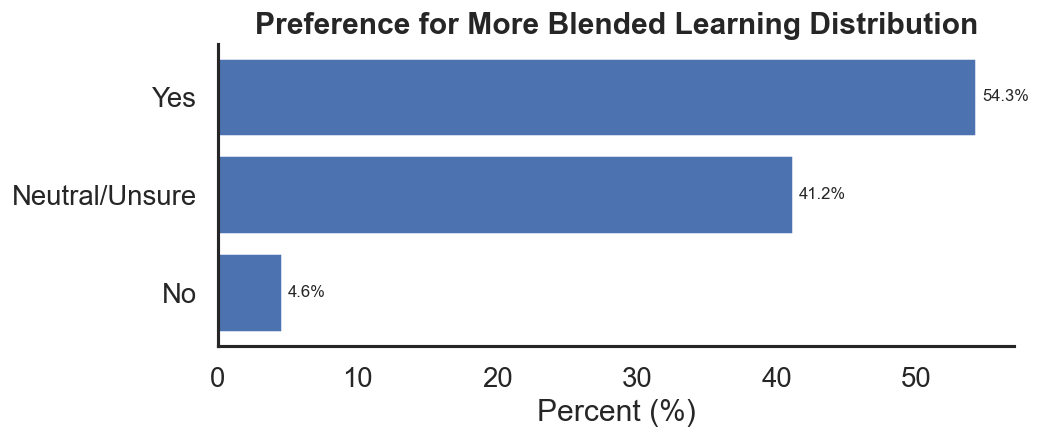


=== Enrollment Status ===


,count,percent
Currently enrolled,465,79.1
On academic leave,72,12.2
Recently graduated,31,5.3
Not currently enrolled,20,3.4


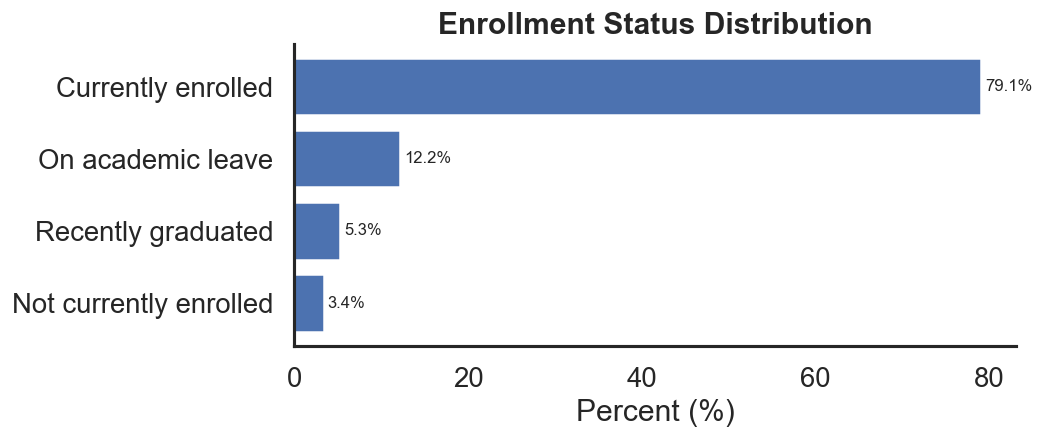

In [60]:
# ── 3.1.3 Nominal categorical variables ───────────────────────────────────────

for col in categorical_cols:
    # Frequency and percentage table
    freq = df[col].value_counts(dropna=False)
    pct_ = (
        df[col]
        .value_counts(dropna=False, normalize=True)
        .mul(100)
        .round(1)
    )

    out = pd.DataFrame({
        "count": freq,
        "percent": pct_
    })

    # Clean index labels for display
    out.index = [
        "Missing" if pd.isna(x) else str(x)
        for x in out.index
    ]

    print(f"\n=== {pl(col)} ===")
    display(out)

    # Prepare plot data
    plot_data = pct_.copy()

    # Keep only top 12 categories if too many
    if len(plot_data) > 12:
        plot_data = plot_data.sort_values(ascending=False).head(12)

    # Sort ascending for better horizontal bar readability
    plot_data = plot_data.sort_values(ascending=True)

    labels = [
        "Missing" if pd.isna(x) else str(x)
        for x in plot_data.index
    ]

    values = plot_data.astype(float).tolist()

    # Plot
    fig, ax = plt.subplots(
        figsize=(9, max(4, len(plot_data) * 0.5))
    )

    ax.barh(labels, values)

    add_barh_labels(ax)

    ax.set_xlabel("Percent (%)")
    ax.set_title(
        f"{pl(col)} Distribution",
        fontweight="bold"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

Ordinal categorical variables


=== Academic Year (ordered) ===


,count,percent
academic_year,,
2019–2020,2,0.3
2020–2021,7,1.2
2021–2022,15,2.6
2022–2023,27,4.6
2023–2024,29,4.9
2024–2025,138,23.5
2025–2026,370,62.9


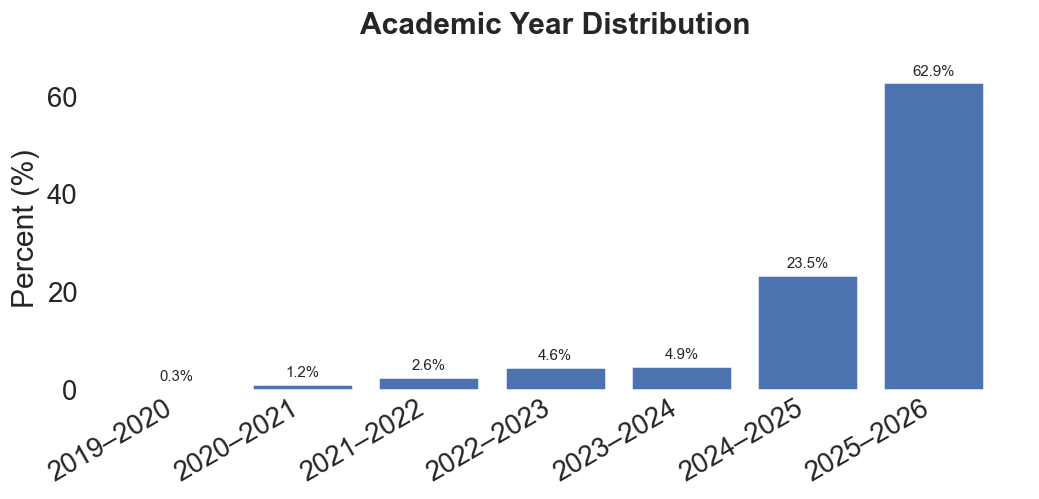


=== Daily Social Media Usage (hrs) (ordered) ===


,count,percent
social_media_hours,,
Less than 1 hour,33,5.6
1 Hour,77,13.1
2 hours,147,25.0
3 hours,142,24.1
4 hours,97,16.5
More than 5 hours,92,15.6


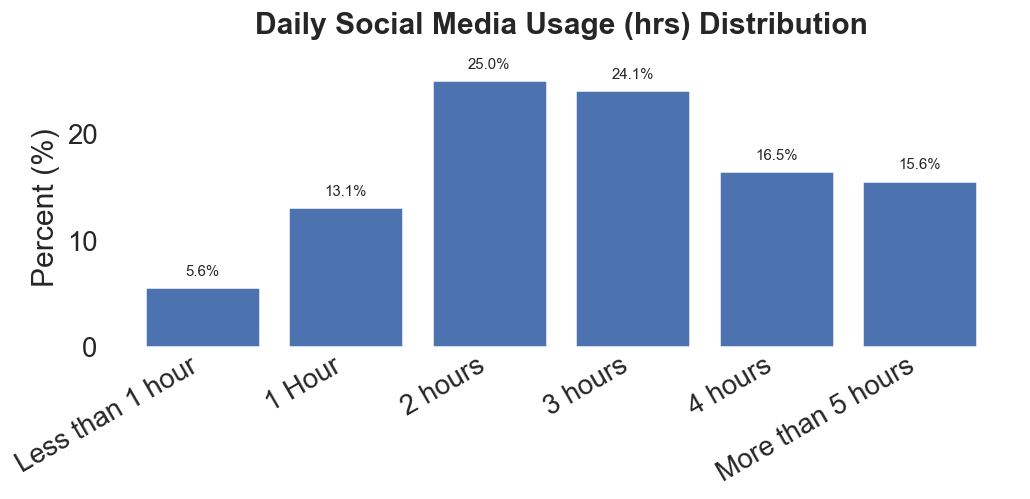

In [61]:
# ── 3.1.4 Ordinal categorical variables ───────────────────────────────────────

ordinal_orders = {
    "social_media_hours": [
        "Less than 1 hour",
        "1 Hour",
        "2 hours",
        "3 hours",
        "4 hours",
        "More than 5 hours"
    ],

    "ACADEMIC_YEAR": [
        "Year 1 - Freshman",
        "Year 2 - Sophomore",
        "Year 3 - Junior",
        "Year 4 - Senior",
        "Year 5 - Final Year",
        "Master",
        "PHD",
        "Other"
    ],
}


for col in original_categorical_cols:
    s = df[col].dropna().astype(str)

    if col in ordinal_orders:
        order = [
            x for x in ordinal_orders[col]
            if x in s.unique()
        ]

        freq = (
            s.value_counts()
             .reindex(order, fill_value=0)
        )

    else:
        freq = s.value_counts().sort_index()

    pct_ = (freq / freq.sum() * 100).round(1)

    out = pd.DataFrame({
        "count": freq,
        "percent": pct_
    })

    print(f"\n=== {pl(col)} (ordered) ===")
    display(out)

    fig, ax = plt.subplots(figsize=(9, 4.5))

    ax.bar(range(len(freq)), pct_.values)

    ax.set_xticks(range(len(freq)))
    ax.set_xticklabels(
        freq.index,
        rotation=30,
        ha="right"
    )

    ax.set_ylabel("Percent (%)")

    ax.set_title(
        f"{pl(col)} Distribution",
        fontweight="bold",
        pad=20
         
    )

    add_bar_labels(ax)

    # Remove grid
    ax.grid(False)

    # Remove bounding box / plot frame
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Optional: keep ticks clean
    ax.tick_params(axis="both", length=0)

    plt.tight_layout()
    plt.show()

Likert-scale variables

=== Likert descriptive statistics ===


,mean,median,std,min,max,skewness,range_width
use_lecture_slides,4.09,4.0,0.89,1,5,-0.74,4
video_helpfulness,4.00,4.0,0.99,1,5,-0.90,4
self_responsibility,3.96,4.0,0.73,1,5,-0.67,4
benefit_self_study_time,3.94,4.0,0.86,1,5,-0.55,4
benefit_recorded_access,3.93,4.0,0.87,1,5,-0.64,4
self_prioritize_deadlines,3.88,4.0,0.78,1,5,-0.78,4
overall_understanding,3.83,4.0,0.73,1,5,-0.39,4
benefit_self_directed,3.80,4.0,0.80,1,5,-0.45,4
benefit_flexibility,3.69,4.0,0.78,1,5,-0.51,4
benefit_life_balance,3.67,4.0,0.86,1,5,-0.38,4


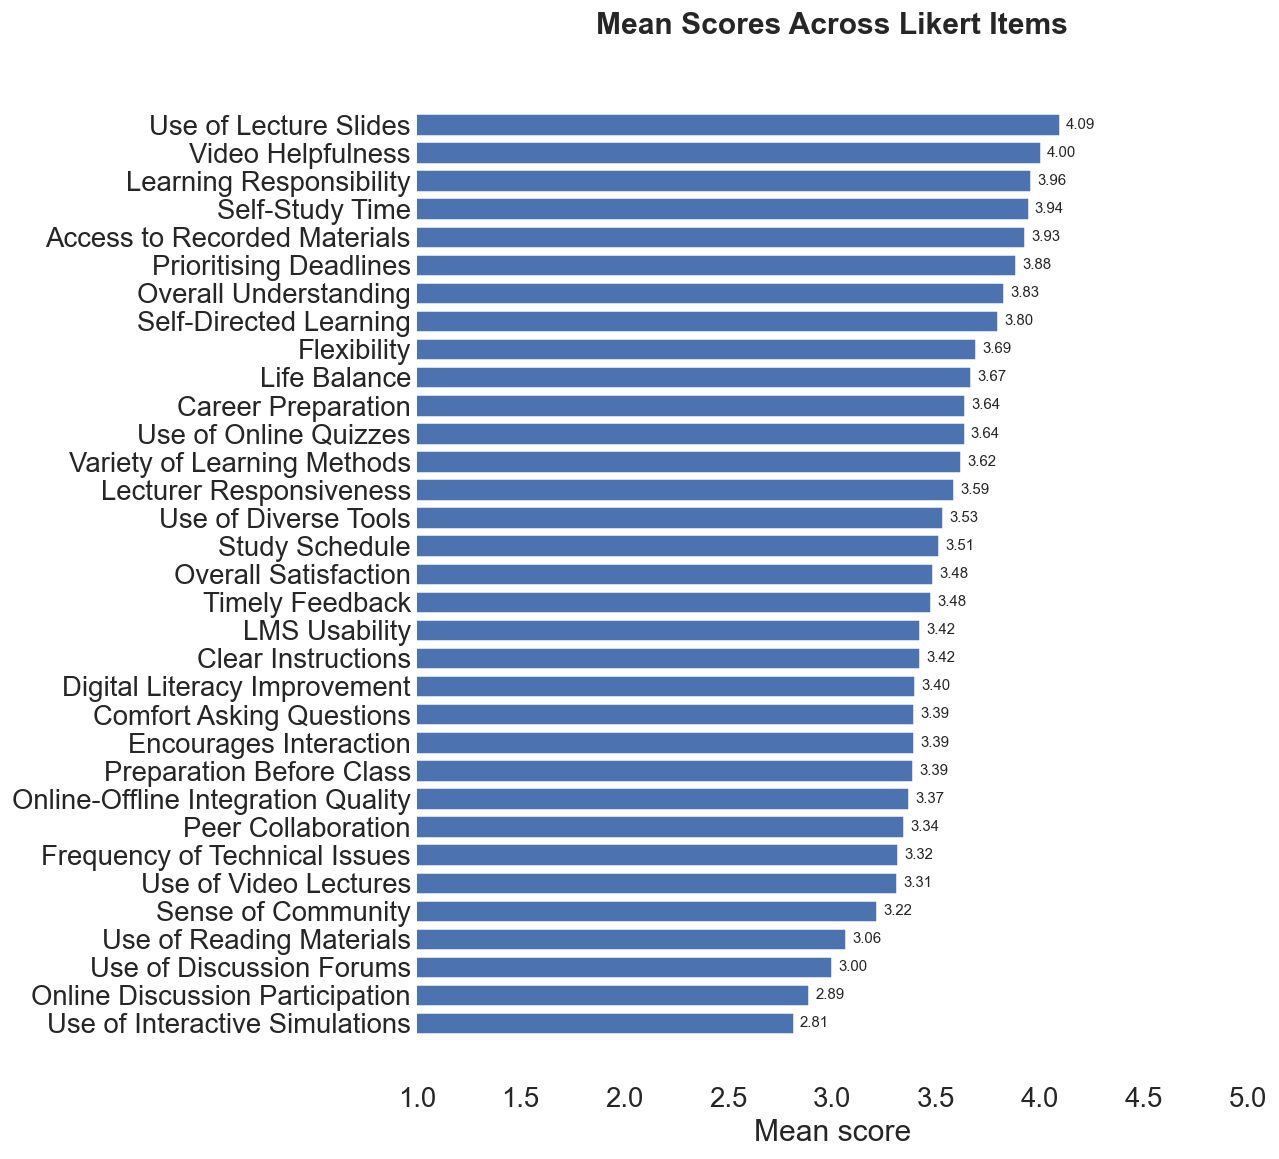

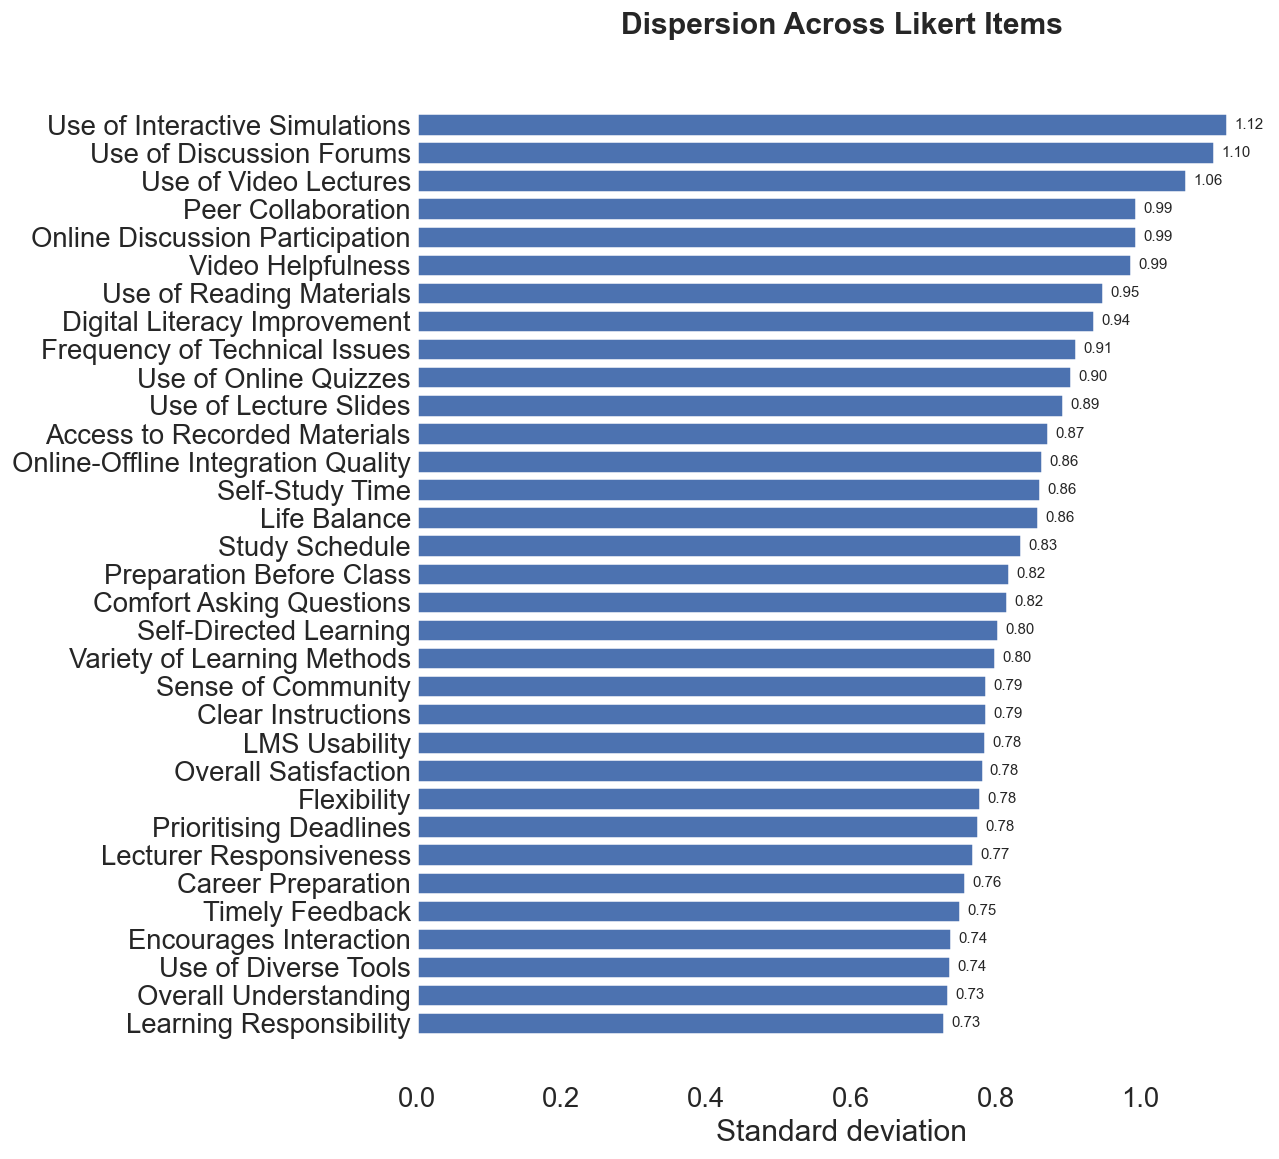

In [62]:
# ── 3.1.5 Likert-scale variables (Ordinal33) ──────────────────────────────────

if oridinal_cols:
    likert_desc = pd.DataFrame({
        'mean': df[oridinal_cols].mean(),
        'median': df[oridinal_cols].median(),
        'std': df[oridinal_cols].std(),
        'min': df[oridinal_cols].min(),
        'max': df[oridinal_cols].max(),
        'skewness': df[oridinal_cols].apply(
            lambda s: skew(s.dropna()) if s.dropna().shape[0] > 2 else np.nan
        )
    }).round(2)

    likert_desc['range_width'] = likert_desc['max'] - likert_desc['min']
    likert_desc = likert_desc.sort_values('mean', ascending=False)

    print("=== Likert descriptive statistics ===")
    display(likert_desc)

    # Mean plot
    mean_s = df[oridinal_cols].mean().sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(11, 10))

    ax.barh(
        [pl(c) for c in mean_s.index],
        mean_s.values
    )

    ax.set_xlim(1, 5)
    ax.set_xlabel('Mean score')

    ax.set_title(
        'Mean Scores Across Likert Items',
        fontweight='bold',
        pad=20
    )

    for i, v in enumerate(mean_s.values):
        ax.text(
            v + 0.03,
            i,
            f'{v:.2f}',
            va='center',
            fontsize=9
        )

    # Remove grid
    ax.grid(False)

    # Remove bounding box
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Remove tick marks
    ax.tick_params(axis="both", length=0)

    plt.tight_layout()
    plt.show()

    # Dispersion plot
    std_s = df[oridinal_cols].std().sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(11, 10))

    ax.barh(
        [pl(c) for c in std_s.index],
        std_s.values
    )

    ax.set_xlabel('Standard deviation')

    ax.set_title(
        'Dispersion Across Likert Items',
        fontweight='bold',
        pad=20
    )

    for i, v in enumerate(std_s.values):
        ax.text(
            v + 0.01,
            i,
            f'{v:.2f}',
            va='center',
            fontsize=9
        )

    # Remove grid
    ax.grid(False)

    # Remove bounding box
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Remove tick marks
    ax.tick_params(axis="both", length=0)

    plt.tight_layout()
    plt.show()

Binary multi-response variables


=== Devices ===


,count_selected,percent_selected
Uses Other Device,3,0.5
Uses Desktop Computer,63,10.7
Uses Tablet,189,32.1
Uses Mobile Phone,492,83.7
Uses Laptop,500,85.0


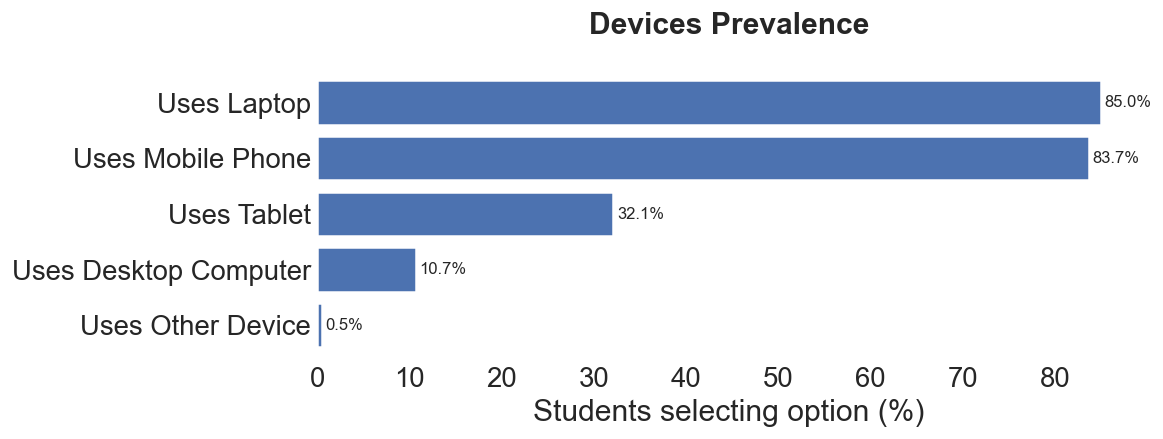


=== Internet Access ===


,count_selected,percent_selected
Uses Public Wi-Fi,129,21.9
Uses University Wi-Fi,275,46.8
Uses Home Wi-Fi,360,61.2
Uses Mobile Data,510,86.7


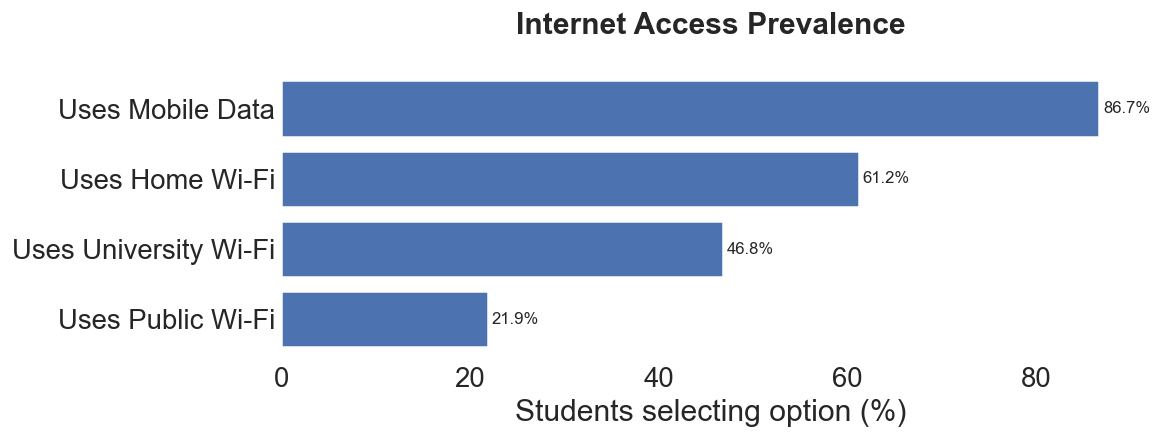


=== Coping Mechanisms ===


,count_selected,percent_selected
Ignore / Do Nothing,42,7.1
Seek One-on-One Support,45,7.7
Request Deadline Extension,146,24.8
Request Resent Announcement,214,36.4
Self-Study,218,37.1
Request Recording,359,61.1
Ask Classmates,360,61.2


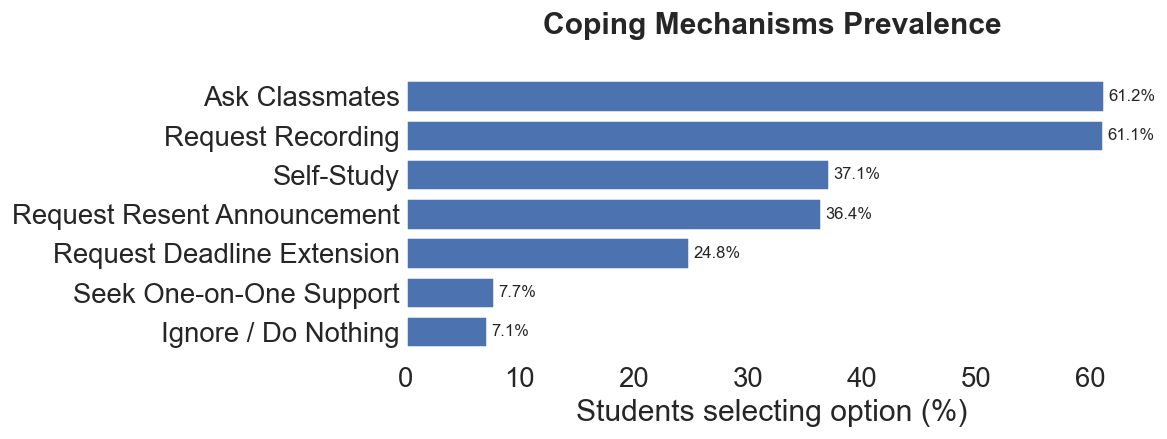


=== Challenges ===


,count_selected,percent_selected
Other,8,1.4
Information Overload,135,23.0
Delayed Feedback,136,23.1
Feeling of Isolation,139,23.6
Time Management,156,26.5
Misunderstanding Content,187,31.8
Limited Interaction,206,35.0
Difficulty Asking Questions,216,36.7
Lack of Instructor Support,237,40.3
Maintaining Motivation,305,51.9


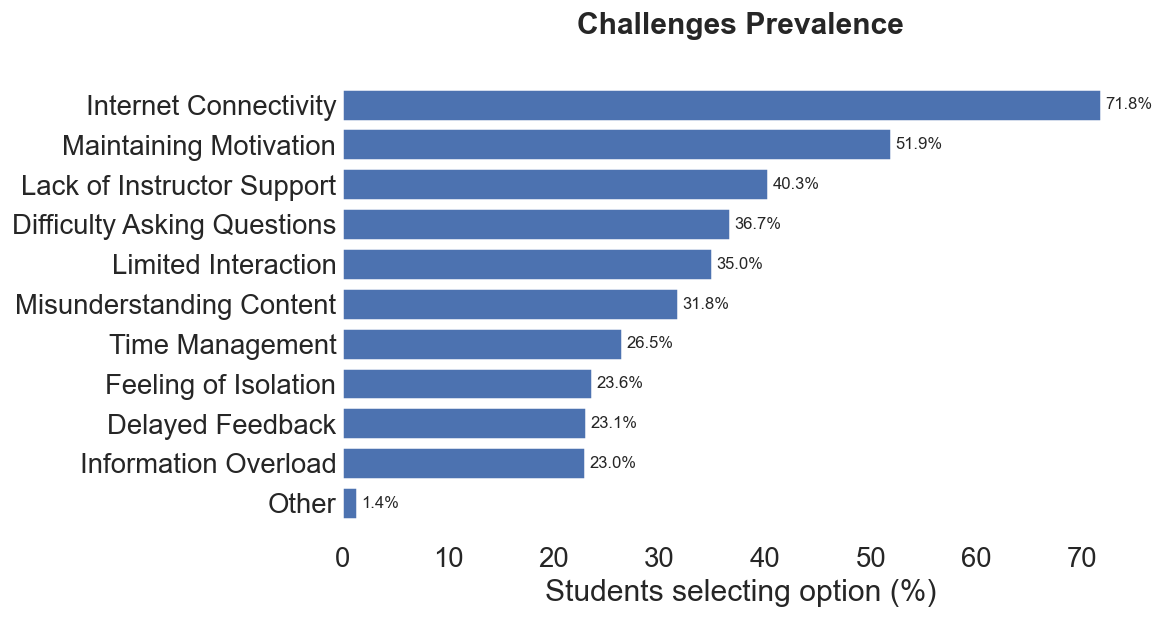


=== Thesis Focus: Reported Blended Learning Challenges ===


,count_selected,percent_selected
Other,8,1.4
Information Overload,135,23.0
Delayed Feedback,136,23.1
Feeling of Isolation,139,23.6
Time Management,156,26.5
Misunderstanding Content,187,31.8
Limited Interaction,206,35.0
Difficulty Asking Questions,216,36.7
Lack of Instructor Support,237,40.3
Maintaining Motivation,305,51.9


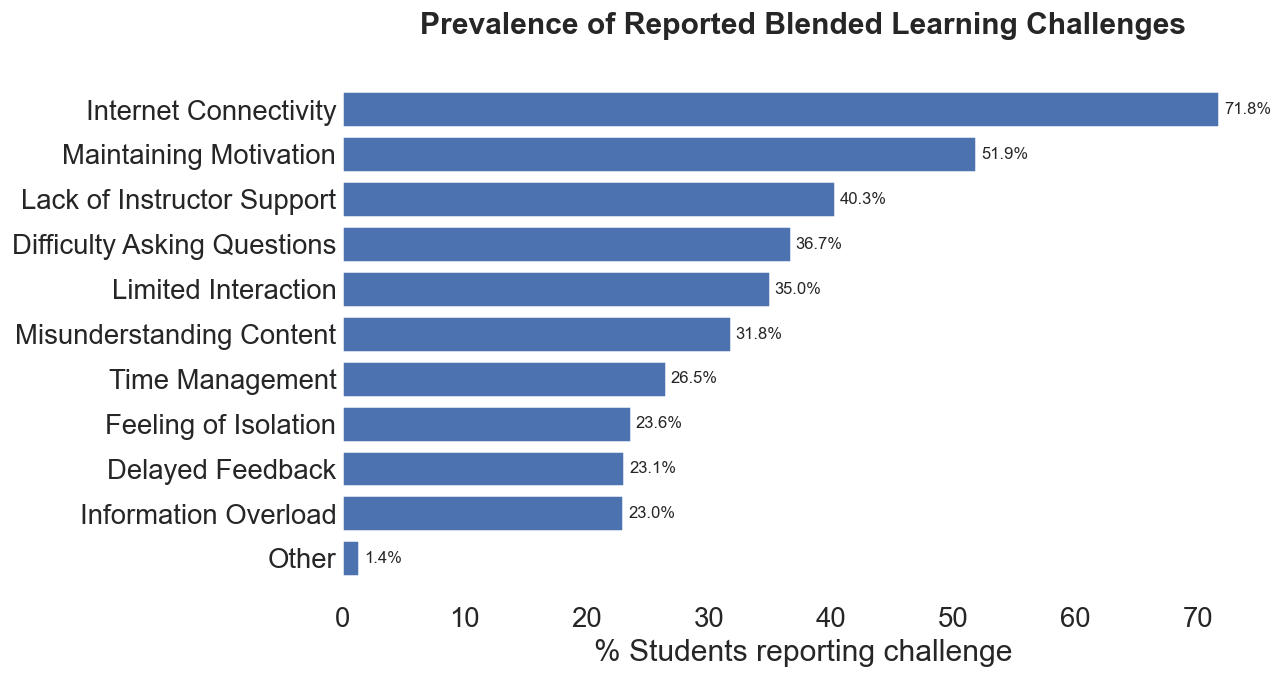

In [63]:
# ── 3.1.6 Binary multi-response variables ─────────────────────────────────────

MULTI_GROUPS = {
    g: [c for c in cols if c in df.columns]
    for g, cols in multi_groups.items()
}

for group_name, cols in MULTI_GROUPS.items():
    if not cols:
        continue

    rates = (df[cols].mean() * 100).sort_values(ascending=True)
    counts = df[cols].sum().reindex(rates.index).astype(int)

    out = pd.DataFrame({
        "count_selected": counts,
        "percent_selected": rates.round(1)
    })

    out.index = [pl(c) for c in out.index]

    print(f"\n=== {pl(group_name)} ===")
    display(out)

    fig, ax = plt.subplots(
        figsize=(10, max(4, len(out) * 0.5))
    )

    ax.barh(
        out.index,
        out["percent_selected"]
    )

    add_barh_labels(ax)

    ax.set_xlabel("Students selecting option (%)")

    ax.set_title(
        f"{pl(group_name)} Prevalence",
        fontweight="bold",
        pad=20
    )

    # Remove grid
    ax.grid(False)

    # Remove bounding box
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Remove tick marks
    ax.tick_params(axis="both", length=0)

    plt.tight_layout()
    plt.show()


# ── Optional: dedicated thesis-quality challenge prevalence ───────────────────

if "challenges" in MULTI_GROUPS and MULTI_GROUPS["challenges"]:
    ch_cols = MULTI_GROUPS["challenges"]

    ch_rates = (
        df[ch_cols]
        .mean()
        .mul(100)
        .sort_values(ascending=True)
    )

    ch_counts = (
        df[ch_cols]
        .sum()
        .reindex(ch_rates.index)
        .astype(int)
    )

    ch_out = pd.DataFrame({
        "count_selected": ch_counts,
        "percent_selected": ch_rates.round(1)
    })

    ch_out.index = [pl(c) for c in ch_out.index]

    print("\n=== Thesis Focus: Reported Blended Learning Challenges ===")
    display(ch_out)

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.barh(
        ch_out.index,
        ch_out["percent_selected"]
    )

    add_barh_labels(ax)

    ax.set_xlabel("% Students reporting challenge")

    ax.set_title(
        "Prevalence of Reported Blended Learning Challenges",
        fontweight="bold",
        pad=20
    )

    # Remove grid
    ax.grid(False)

    # Remove bounding box
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Remove tick marks
    ax.tick_params(axis="both", length=0)

    plt.tight_layout()
    plt.show()

In [64]:
# ── 3.1.7 Summary table by variable type ──────────────────────────────────────

summary_tbl = pd.DataFrame({
    'Variable Type': [
        'Numeric',
        'Nominal categorical',
        'Ordinal categorical',
        'Likert-scale items',
        'Binary multi-response variables'
    ],
    'Count': [
        len(numeric_vars),
        len(categorical_cols),
        len(original_categorical_cols),
        len(oridinal_cols),
        sum(len(v) for v in MULTI_GROUPS.values())
    ],
    'Examples': [
        ', '.join(numeric_vars[:3]) if numeric_vars else '-',
        ', '.join(categorical_cols[:3]) if categorical_cols else '-',
        ', '.join(original_categorical_cols[:3]) if original_categorical_cols else '-',
        ', '.join(oridinal_cols[:3]) if oridinal_cols else '-',
        ', '.join(list(MULTI_GROUPS.keys())[:3]) if MULTI_GROUPS else '-'
    ]
})

display(summary_tbl)

,Variable Type,Count,Examples
0,Numeric,1,age
1,Nominal categorical,10,"gender, is_itc_student, education_level"
2,Ordinal categorical,2,"academic_year, social_media_hours"
3,Likert-scale items,33,"use_lecture_slides, use_video_lectures, use_qu..."
4,Binary multi-response variables,27,"devices, internet_access, coping_mechanisms"


### 2.1 Univariate Analysis

#### 2.1.1 Demographic Overview

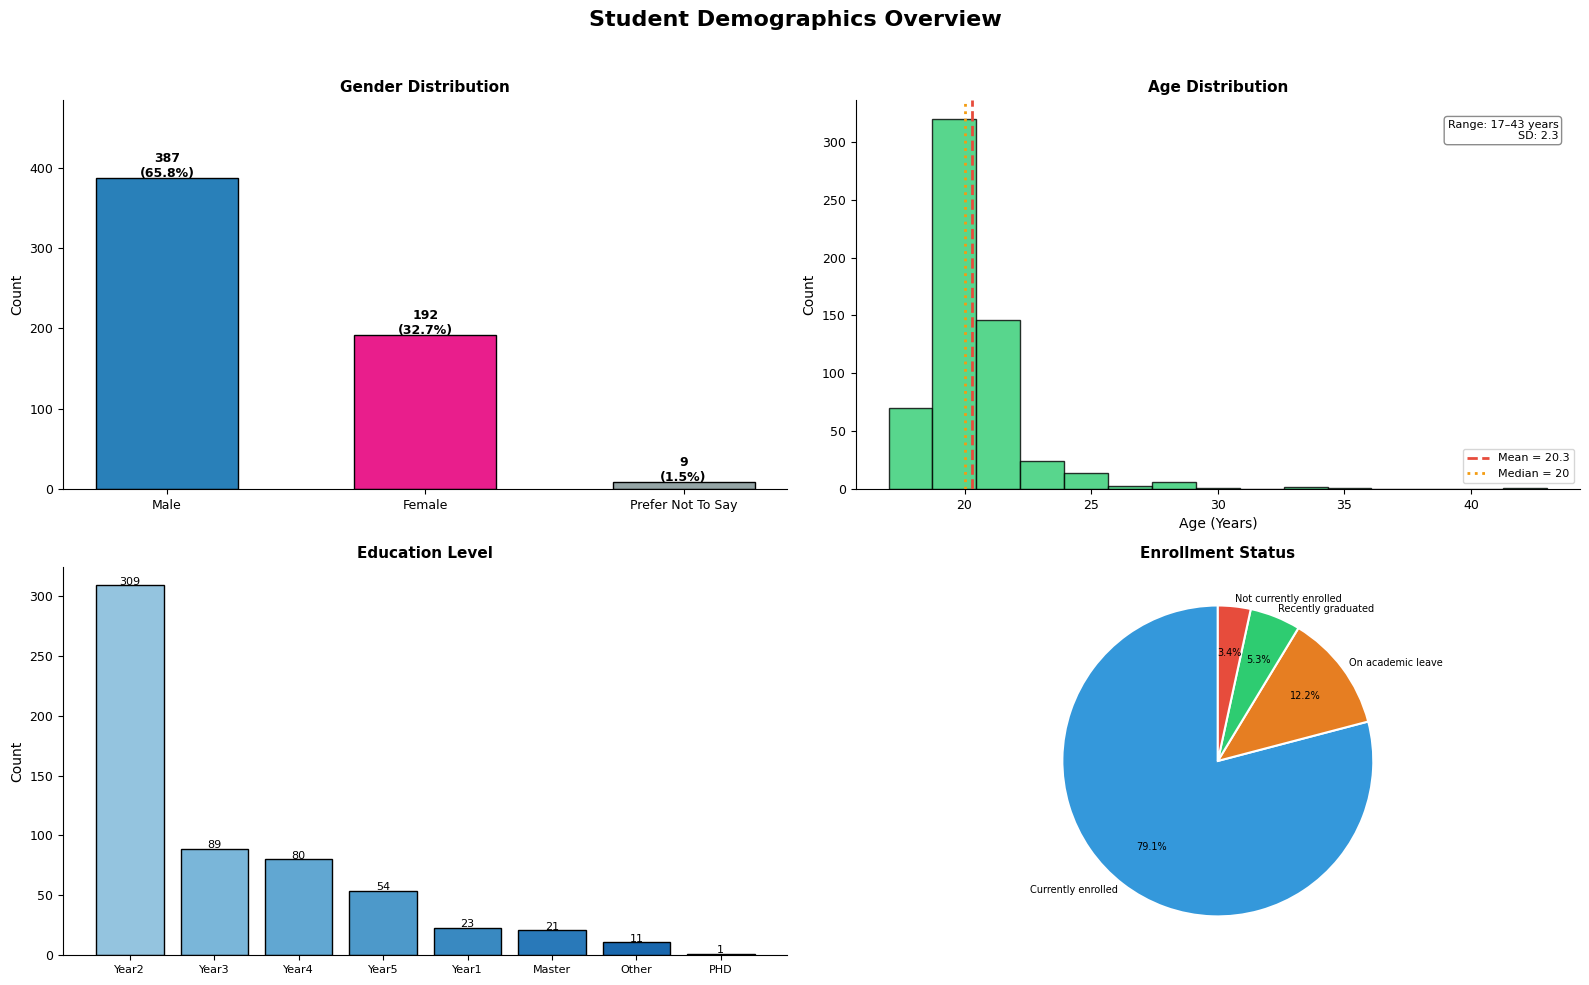


Demographic Summary
--------------------------------------------------
Age: mean=20.3, median=20, SD=2.3, range=17–43


In [65]:
# ── 3.1.1 Demographics Overview ──────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import textwrap

# Clean thesis-style formatting
plt.style.use('default')

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

fig.suptitle(
    'Student Demographics Overview',
    fontsize=16,
    fontweight='bold',
    y=0.98
)

# ── Gender Distribution ──────────────────────────────────────────────────────
gender_counts = df['gender'].value_counts()

colors_g = ['#2980b9', '#e91e8c', '#95a5a6']

bars = axes[0,0].bar(
    gender_counts.index,
    gender_counts.values,
    color=colors_g[:len(gender_counts)],
    edgecolor='black',
    width=0.55
)

for bar, val in zip(bars, gender_counts.values):
    pct = val / len(df) * 100
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{val}\n({pct:.1f}%)',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

axes[0,0].set_title('Gender Distribution', fontweight='bold')
axes[0,0].set_ylabel('Count')
axes[0,0].set_ylim(0, gender_counts.max() * 1.25)

# ── Age Distribution ─────────────────────────────────────────────────────────
age_data = df['age'].dropna()

axes[0,1].hist(
    age_data,
    bins=15,
    color='#2ecc71',
    edgecolor='black',
    alpha=0.8
)

axes[0,1].axvline(
    age_data.mean(),
    color='#e74c3c',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {age_data.mean():.1f}'
)

axes[0,1].axvline(
    age_data.median(),
    color='#f39c12',
    linestyle=':',
    linewidth=2,
    label=f'Median = {age_data.median():.0f}'
)

axes[0,1].set_title('Age Distribution', fontweight='bold')
axes[0,1].set_xlabel('Age (Years)')
axes[0,1].set_ylabel('Count')
axes[0,1].legend(fontsize=8)

axes[0,1].annotate(
    f'Range: {int(age_data.min())}–{int(age_data.max())} years\n'
    f'SD: {age_data.std():.1f}',
    xy=(0.97, 0.95),
    xycoords='axes fraction',
    ha='right',
    va='top',
    fontsize=8,
    bbox=dict(
        boxstyle='round,pad=0.3',
        facecolor='white',
        edgecolor='gray',
        alpha=0.9
    )
)

# ── Education Level ──────────────────────────────────────────────────────────
edu_order = (
    df['education_level']
    .value_counts()
    .sort_values(ascending=False)
    .index
)

edu_counts = (
    df['education_level']
    .value_counts()
    .reindex(edu_order)
)

bar_colors = plt.cm.Blues(
    np.linspace(0.4, 0.85, len(edu_counts))
)

bars = axes[1,0].bar(
    range(len(edu_counts)),
    edu_counts.values,
    color=bar_colors,
    edgecolor='black'
)

axes[1,0].set_xticks(range(len(edu_counts)))

axes[1,0].set_xticklabels(
    [
        textwrap.fill(
            e.split(' - ')[0],
            width=12
        )
        for e in edu_counts.index
    ],
    rotation=0,
    ha='center',
    fontsize=8
)

for bar, val in zip(bars, edu_counts.values):
    axes[1,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        str(val),
        ha='center',
        fontsize=8
    )

axes[1,0].set_title('Education Level', fontweight='bold')
axes[1,0].set_ylabel('Count')

# ── Enrollment Status ────────────────────────────────────────────────────────
enroll_counts = df['enrollment_status'].value_counts()

axes[1,1].pie(
    enroll_counts.values,
    labels=enroll_counts.index,
    colors=['#3498db', '#e67e22', '#2ecc71', '#e74c3c'][:len(enroll_counts)],
    startangle=90,
    autopct='%1.1f%%',
    pctdistance=0.70,
    labeldistance=1.05,
    textprops={'fontsize': 7},
    wedgeprops=dict(
        edgecolor='white',
        linewidth=1.5
    )
)

axes[1,1].set_title(
    'Enrollment Status',
    fontweight='bold'
)

# ── Clean Academic Style ─────────────────────────────────────────────────────
for ax in [axes[0,0], axes[0,1], axes[1,0]]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Layout ───────────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

# ── Summary Statistics ───────────────────────────────────────────────────────
print("\nDemographic Summary")
print("-" * 50)
print(
    f"Age: mean={age_data.mean():.1f}, "
    f"median={age_data.median():.0f}, "
    f"SD={age_data.std():.1f}, "
    f"range={int(age_data.min())}–{int(age_data.max())}"
)

#### 2.1.2 Academic Profile

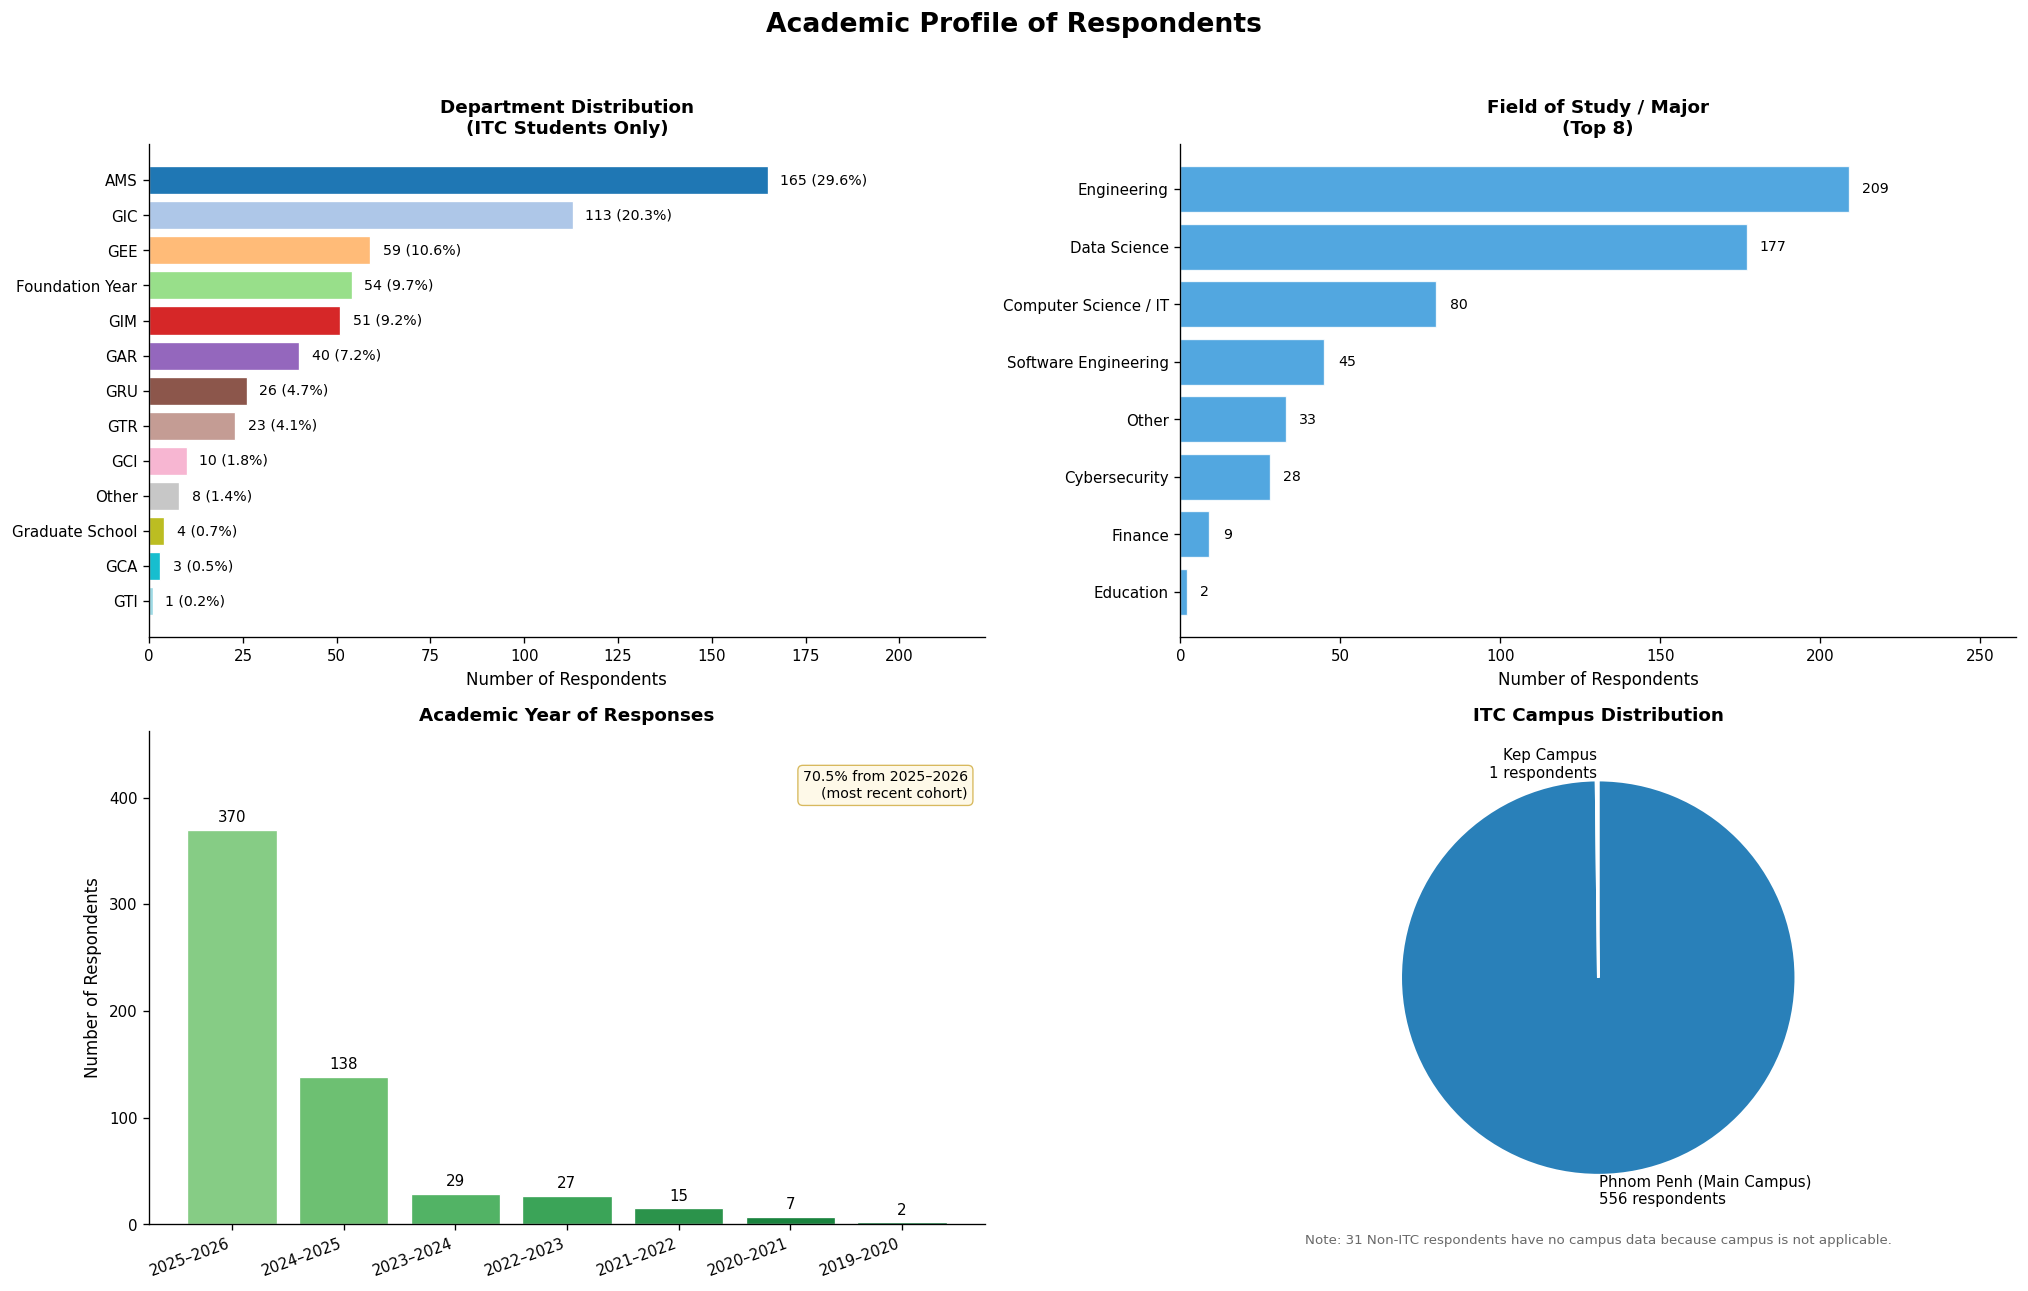

In [66]:
# ── 3.1.2 Academic profile ────────────────────────────────────────────────
import textwrap
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 120
})

fig, axes = plt.subplots(2, 2, figsize=(17, 10.5))
fig.suptitle(
    "Academic Profile of Respondents",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

def wrap_labels(labels, width=28):
    return ["\n".join(textwrap.wrap(str(label), width=width)) for label in labels]


# ── Department ────────────────────────────────────────────────────────────
dept_counts = df["department"].value_counts()
dept_total = df["department"].notna().sum()

dept_labels = wrap_labels(dept_counts.index[::-1], width=30)
dept_values = dept_counts.values[::-1]

colors_d = plt.cm.tab20(np.linspace(0, 1, len(dept_counts)))

bars = axes[0, 0].barh(
    dept_labels,
    dept_values,
    color=colors_d[::-1],
    edgecolor="white",
    linewidth=0.8
)

for bar, val in zip(bars, dept_values):
    pct = val / dept_total * 100
    axes[0, 0].text(
        val + dept_counts.max() * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{val} ({pct:.1f}%)",
        va="center",
        fontsize=8.5
    )

axes[0, 0].set_title("Department Distribution\n(ITC Students Only)", fontweight="bold")
axes[0, 0].set_xlabel("Number of Respondents")
axes[0, 0].set_xlim(0, dept_counts.max() * 1.35)


# ── Major ─────────────────────────────────────────────────────────────────
major_counts = df["major"].value_counts().head(8)

major_labels = wrap_labels(major_counts.index[::-1], width=30)
major_values = major_counts.values[::-1]

bars = axes[0, 1].barh(
    major_labels,
    major_values,
    color="#3498db",
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8
)

for bar, val in zip(bars, major_values):
    axes[0, 1].text(
        val + major_counts.max() * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{val}",
        va="center",
        fontsize=8.5
    )

axes[0, 1].set_title("Field of Study / Major\n(Top 8)", fontweight="bold")
axes[0, 1].set_xlabel("Number of Respondents")
axes[0, 1].set_xlim(0, major_counts.max() * 1.25)


# ── Academic Year ─────────────────────────────────────────────────────────
yr_counts = df["academic_year"].value_counts().sort_values(ascending=False)

bars = axes[1, 0].bar(
    range(len(yr_counts)),
    yr_counts.values,
    color=plt.cm.Greens(np.linspace(0.45, 0.85, len(yr_counts))),
    edgecolor="white",
    linewidth=0.8
)

axes[1, 0].set_xticks(range(len(yr_counts)))
axes[1, 0].set_xticklabels(
    wrap_labels(yr_counts.index, width=16),
    rotation=20,
    ha="right"
)

for bar, val in zip(bars, yr_counts.values):
    axes[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + yr_counts.max() * 0.02,
        str(val),
        ha="center",
        fontsize=9
    )

axes[1, 0].set_title("Academic Year of Responses", fontweight="bold")
axes[1, 0].set_ylabel("Number of Respondents")
axes[1, 0].set_ylim(0, yr_counts.max() * 1.25)

axes[1, 0].annotate(
    "70.5% from 2025–2026\n(most recent cohort)",
    xy=(0.98, 0.92),
    xycoords="axes fraction",
    ha="right",
    va="top",
    fontsize=8.5,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="#fef9e7",
        edgecolor="#d6b656",
        linewidth=0.8,
        alpha=0.95
    )
)


# ── ITC Campus ────────────────────────────────────────────────────────────
campus_counts = df["itc_campus"].value_counts(dropna=True)

campus_labels = [
    f"{str(lbl).replace('ITC ', '')}\n{val} respondents"
    for lbl, val in campus_counts.items()
]

axes[1, 1].pie(
    campus_counts.values,
    labels=campus_labels,
    colors=["#2980b9", "#27ae60", "#e67e22"],
    startangle=90,
    counterclock=False,
    labeldistance=1.08,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
    textprops=dict(fontsize=9)
)

axes[1, 1].set_title("ITC Campus Distribution", fontweight="bold")

axes[1, 1].text(
    0,
    -1.35,
    "Note: 31 Non-ITC respondents have no campus data because campus is not applicable.",
    ha="center",
    fontsize=8,
    color="dimgray"
)


# ── Clean visual style, no grid ───────────────────────────────────────────
for ax in [axes[0, 0], axes[0, 1], axes[1, 0]]:
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### 2.1.3 Technology access

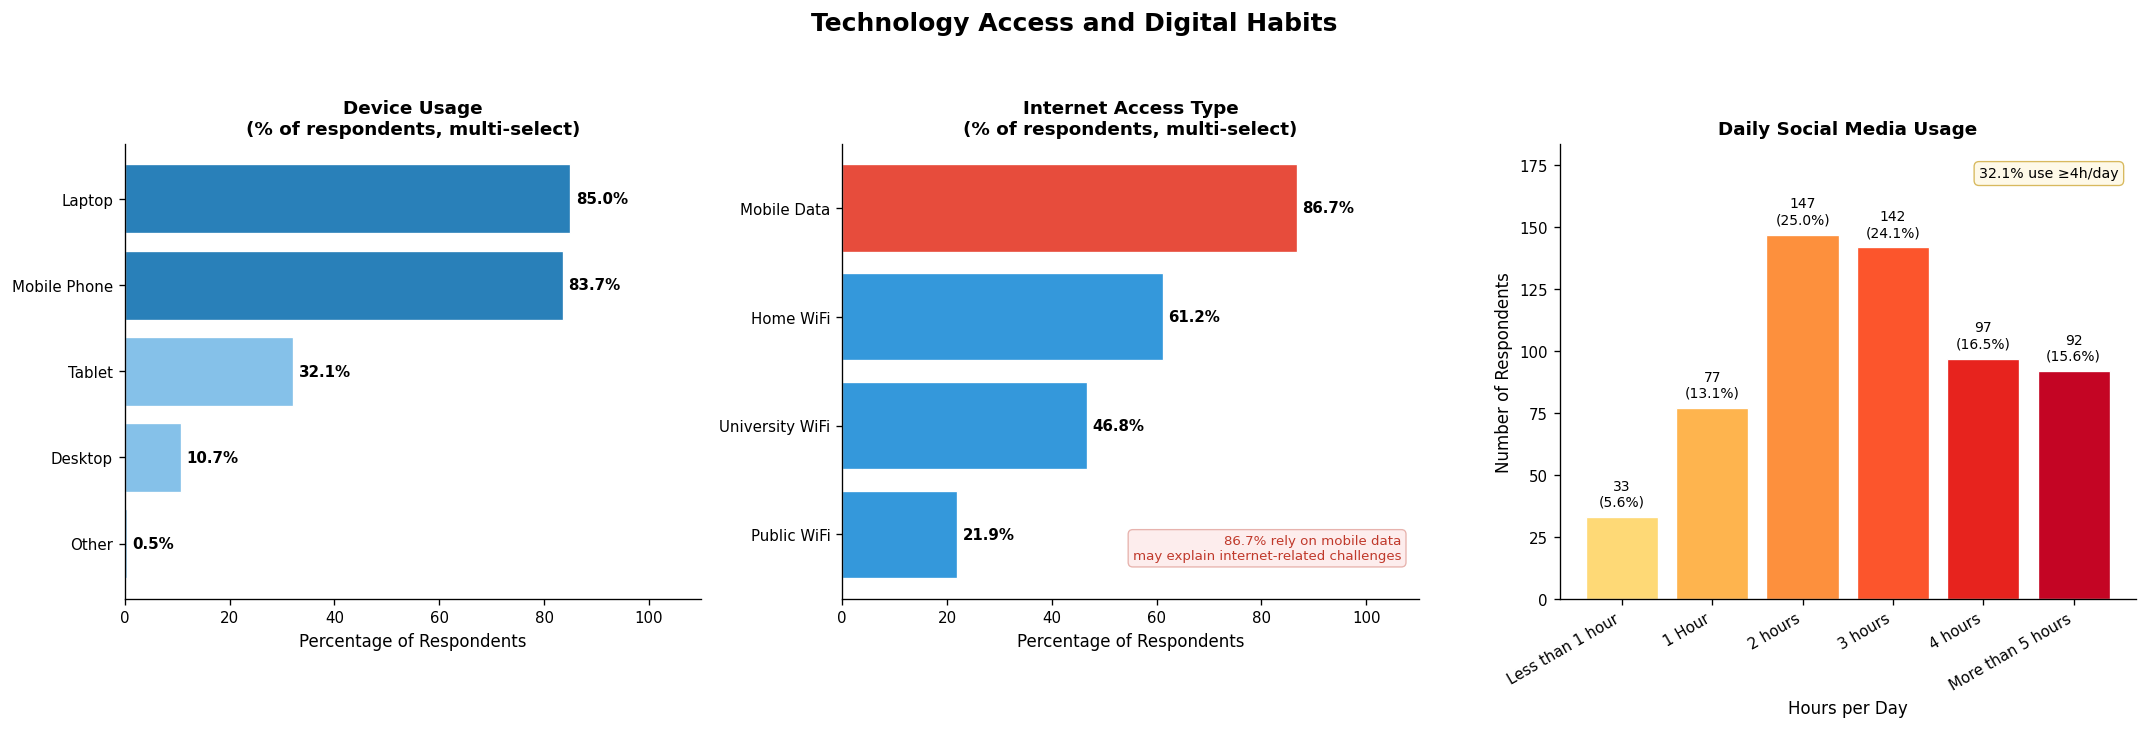

Median social media usage: 4 (scale 1=Less than 1 hour ... 6=More than 5 hours)
Students using ≥4h/day: 189 (32.1%)


In [67]:
# ── 3.1.3 Technology access ───────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 120
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5.8))

fig.suptitle(
    "Technology Access and Digital Habits",
    fontsize=15,
    fontweight="bold",
    y=1.04
)

# ── Devices ───────────────────────────────────────────────────────────────
dev_cols = [
    "device_laptop",
    "device_mobile",
    "device_tablet",
    "device_desktop",
    "device_other"
]

dev_labels = [
    "Laptop",
    "Mobile Phone",
    "Tablet",
    "Desktop",
    "Other"
]

dev_pcts = [df[c].fillna(0).mean() * 100 for c in dev_cols]

dev_data = sorted(
    zip(dev_labels, dev_pcts),
    key=lambda x: x[1],
    reverse=True
)

dev_labels_s, dev_pcts_s = zip(*dev_data)

bars = axes[0].barh(
    dev_labels_s[::-1],
    dev_pcts_s[::-1],
    color=["#2980b9" if p > 50 else "#85c1e9" for p in dev_pcts_s[::-1]],
    edgecolor="white",
    linewidth=0.8
)

for bar, val in zip(bars, dev_pcts_s[::-1]):
    axes[0].text(
        val + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

axes[0].set_xlim(0, 110)
axes[0].set_title(
    "Device Usage\n(% of respondents, multi-select)",
    fontweight="bold"
)
axes[0].set_xlabel("Percentage of Respondents")


# ── Internet Access ───────────────────────────────────────────────────────
inet_cols = [
    "inet_mobile_data",
    "inet_university_wifi",
    "inet_home_wifi",
    "inet_public_wifi"
]

inet_labels = [
    "Mobile Data",
    "University WiFi",
    "Home WiFi",
    "Public WiFi"
]

inet_pcts = [df[c].fillna(0).mean() * 100 for c in inet_cols]

inet_data = sorted(
    zip(inet_labels, inet_pcts),
    key=lambda x: x[1],
    reverse=True
)

inet_labels_s, inet_pcts_s = zip(*inet_data)

colors_inet = [
    "#e74c3c" if label == "Mobile Data" else "#3498db"
    for label in inet_labels_s[::-1]
]

bars = axes[1].barh(
    inet_labels_s[::-1],
    inet_pcts_s[::-1],
    color=colors_inet,
    edgecolor="white",
    linewidth=0.8
)

for bar, val in zip(bars, inet_pcts_s[::-1]):
    axes[1].text(
        val + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

axes[1].set_xlim(0, 110)
axes[1].set_title(
    "Internet Access Type\n(% of respondents, multi-select)",
    fontweight="bold"
)
axes[1].set_xlabel("Percentage of Respondents")

mobile_data_pct = df["inet_mobile_data"].fillna(0).mean() * 100

axes[1].annotate(
    f"{mobile_data_pct:.1f}% rely on mobile data\nmay explain internet-related challenges",
    xy=(0.97, 0.08),
    xycoords="axes fraction",
    ha="right",
    va="bottom",
    fontsize=8,
    color="#c0392b",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="#fdedec",
        edgecolor="#e6b0aa",
        linewidth=0.8,
        alpha=0.95
    )
)


# ── Social Media Hours ────────────────────────────────────────────────────
sm_order = [
    "Less than 1 hour",
    "1 Hour",
    "2 hours",
    "3 hours",
    "4 hours",
    "More than 5 hours"
]

sm_counts = (
    df["social_media_hours"]
    .value_counts()
    .reindex(sm_order, fill_value=0)
)

sm_colors = plt.cm.YlOrRd(np.linspace(0.25, 0.85, len(sm_counts)))

bars = axes[2].bar(
    sm_order,
    sm_counts.values,
    color=sm_colors,
    edgecolor="white",
    linewidth=0.8
)

for bar, val in zip(bars, sm_counts.values):
    pct = val / df["social_media_hours"].notna().sum() * 100
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + sm_counts.max() * 0.03,
        f"{val}\n({pct:.1f}%)",
        ha="center",
        fontsize=8.3
    )

axes[2].set_title(
    "Daily Social Media Usage",
    fontweight="bold"
)
axes[2].set_xlabel("Hours per Day")
axes[2].set_ylabel("Number of Respondents")
axes[2].set_ylim(0, sm_counts.max() * 1.25)

axes[2].tick_params(axis="x", labelrotation=30)
for label in axes[2].get_xticklabels():
    label.set_ha("right")


# Numeric mapping for social media usage
sm_mapping = {
    "Less than 1 hour": 1,
    "1 Hour": 2,
    "2 hours": 3,
    "3 hours": 4,
    "4 hours": 5,
    "More than 5 hours": 6
}

sm_numeric = df["social_media_hours"].map(sm_mapping)

# True ≥4h/day means categories: 4 hours and More than 5 hours
heavy_count = sm_numeric.ge(5).sum()
heavy_pct = sm_numeric.ge(5).mean() * 100

axes[2].annotate(
    f"{heavy_pct:.1f}% use ≥4h/day",
    xy=(0.97, 0.95),
    xycoords="axes fraction",
    ha="right",
    va="top",
    fontsize=8.5,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="#fef9e7",
        edgecolor="#d6b656",
        linewidth=0.8,
        alpha=0.95
    )
)


# ── Clean visual style, no grid ───────────────────────────────────────────
for ax in axes:
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ── Summary printout ──────────────────────────────────────────────────────
print(
    f"Median social media usage: {sm_numeric.median():.0f} "
    f"(scale 1=Less than 1 hour ... 6=More than 5 hours)"
)

print(
    f"Students using ≥4h/day: {heavy_count} "
    f"({heavy_pct:.1f}%)"
)

### 2.1.4  Non-ITC Student Demographic Profile

ITC: n=557  |  Non-ITC: n=31


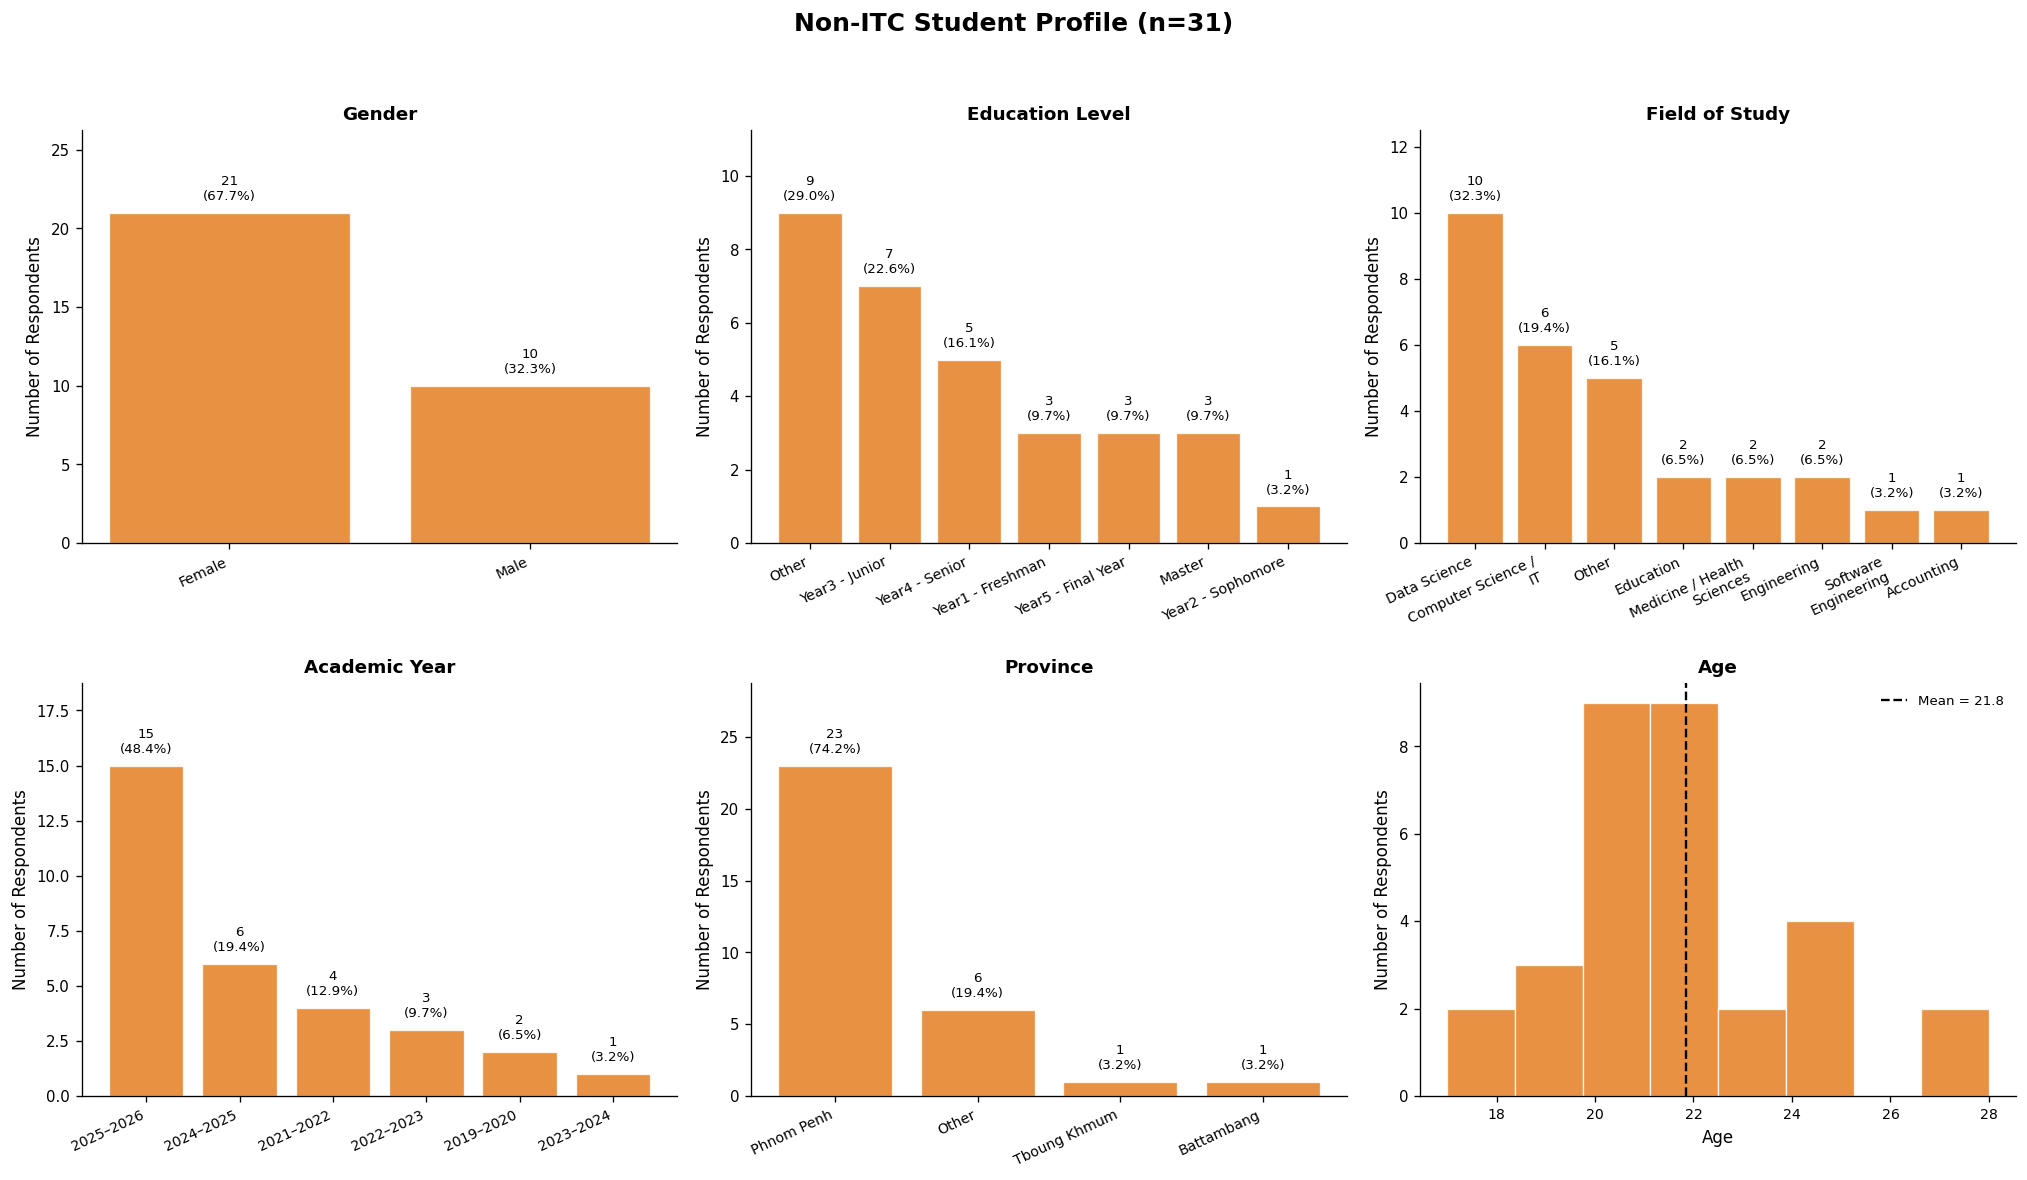


Non-ITC: Female respondents account for 67.7% compared with 30.7% among ITC students.
Non-ITC: The sample is mainly concentrated in Data Science, Computer Science, and related technology fields.
Note: faculty, department, and itc_campus are structurally null for Non-ITC students because these fields are only applicable to ITC respondents.


In [68]:
# ── 3.1.4 Non-ITC student profile ─────────────────────────────────────────
import textwrap
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 9,
    "figure.dpi": 120
})

# Split ITC and Non-ITC students
itc = df[df["is_itc_student"] == True]
non_itc = df[df["is_itc_student"] == False]

print(f"ITC: n={len(itc)}  |  Non-ITC: n={len(non_itc)}")

# Helper function for long labels
def wrap_labels(labels, width=18):
    return ["\n".join(textwrap.wrap(str(label), width=width)) for label in labels]

fig, axes = plt.subplots(2, 3, figsize=(17, 9.5))

fig.suptitle(
    f"Non-ITC Student Profile (n={len(non_itc)})",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

panels = [
    ("gender", "Gender", "#e67e22"),
    ("education_level", "Education Level", "#e67e22"),
    ("major", "Field of Study", "#e67e22"),
    ("academic_year", "Academic Year", "#e67e22"),
    ("province", "Province", "#e67e22"),
    ("age", "Age", "#e67e22"),
]

for ax, (col, title, color) in zip(axes.flatten(), panels):

    if col not in non_itc.columns:
        ax.set_visible(False)
        continue

    data = non_itc[col].dropna()

    if data.empty:
        ax.set_visible(False)
        continue

    # ── Age histogram ─────────────────────────────────────────────────────
    if col == "age":
        data = data.astype(float)

        ax.hist(
            data,
            bins=8,
            color=color,
            edgecolor="white",
            linewidth=0.8,
            alpha=0.85
        )

        mean_age = data.mean()

        ax.axvline(
            mean_age,
            color="black",
            linestyle="--",
            linewidth=1.4,
            label=f"Mean = {mean_age:.1f}"
        )

        ax.set_xlabel("Age")
        ax.set_ylabel("Number of Respondents")
        ax.legend(fontsize=8, frameon=False)

    # ── Categorical bar charts ────────────────────────────────────────────
    else:
        counts = data.value_counts().head(8)
        labels = wrap_labels(counts.index, width=18)

        bars = ax.bar(
            range(len(counts)),
            counts.values,
            color=color,
            alpha=0.85,
            edgecolor="white",
            linewidth=0.8
        )

        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(
            labels,
            rotation=25,
            ha="right"
        )

        for bar, val in zip(bars, counts.values):
            pct = val / len(data) * 100
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + counts.max() * 0.03,
                f"{val}\n({pct:.1f}%)",
                ha="center",
                va="bottom",
                fontsize=8
            )

        ax.set_ylabel("Number of Respondents")
        ax.set_ylim(0, counts.max() * 1.25)

    ax.set_title(title, fontweight="bold")

    # Clean thesis style
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ── Summary statistics ────────────────────────────────────────────────────
non_itc_female_pct = (
    non_itc["gender"]
    .astype(str)
    .str.lower()
    .eq("female")
    .mean() * 100
)

itc_female_pct = (
    itc["gender"]
    .astype(str)
    .str.lower()
    .eq("female")
    .mean() * 100
)

print(
    f"\nNon-ITC: Female respondents account for {non_itc_female_pct:.1f}% "
    f"compared with {itc_female_pct:.1f}% among ITC students."
)

print(
    "Non-ITC: The sample is mainly concentrated in Data Science, Computer Science, "
    "and related technology fields."
)

print(
    "Note: faculty, department, and itc_campus are structurally null for Non-ITC students "
    "because these fields are only applicable to ITC respondents."
)

#### 2.1.5 Distribution of Student Responses (Likert Scale Analysis)

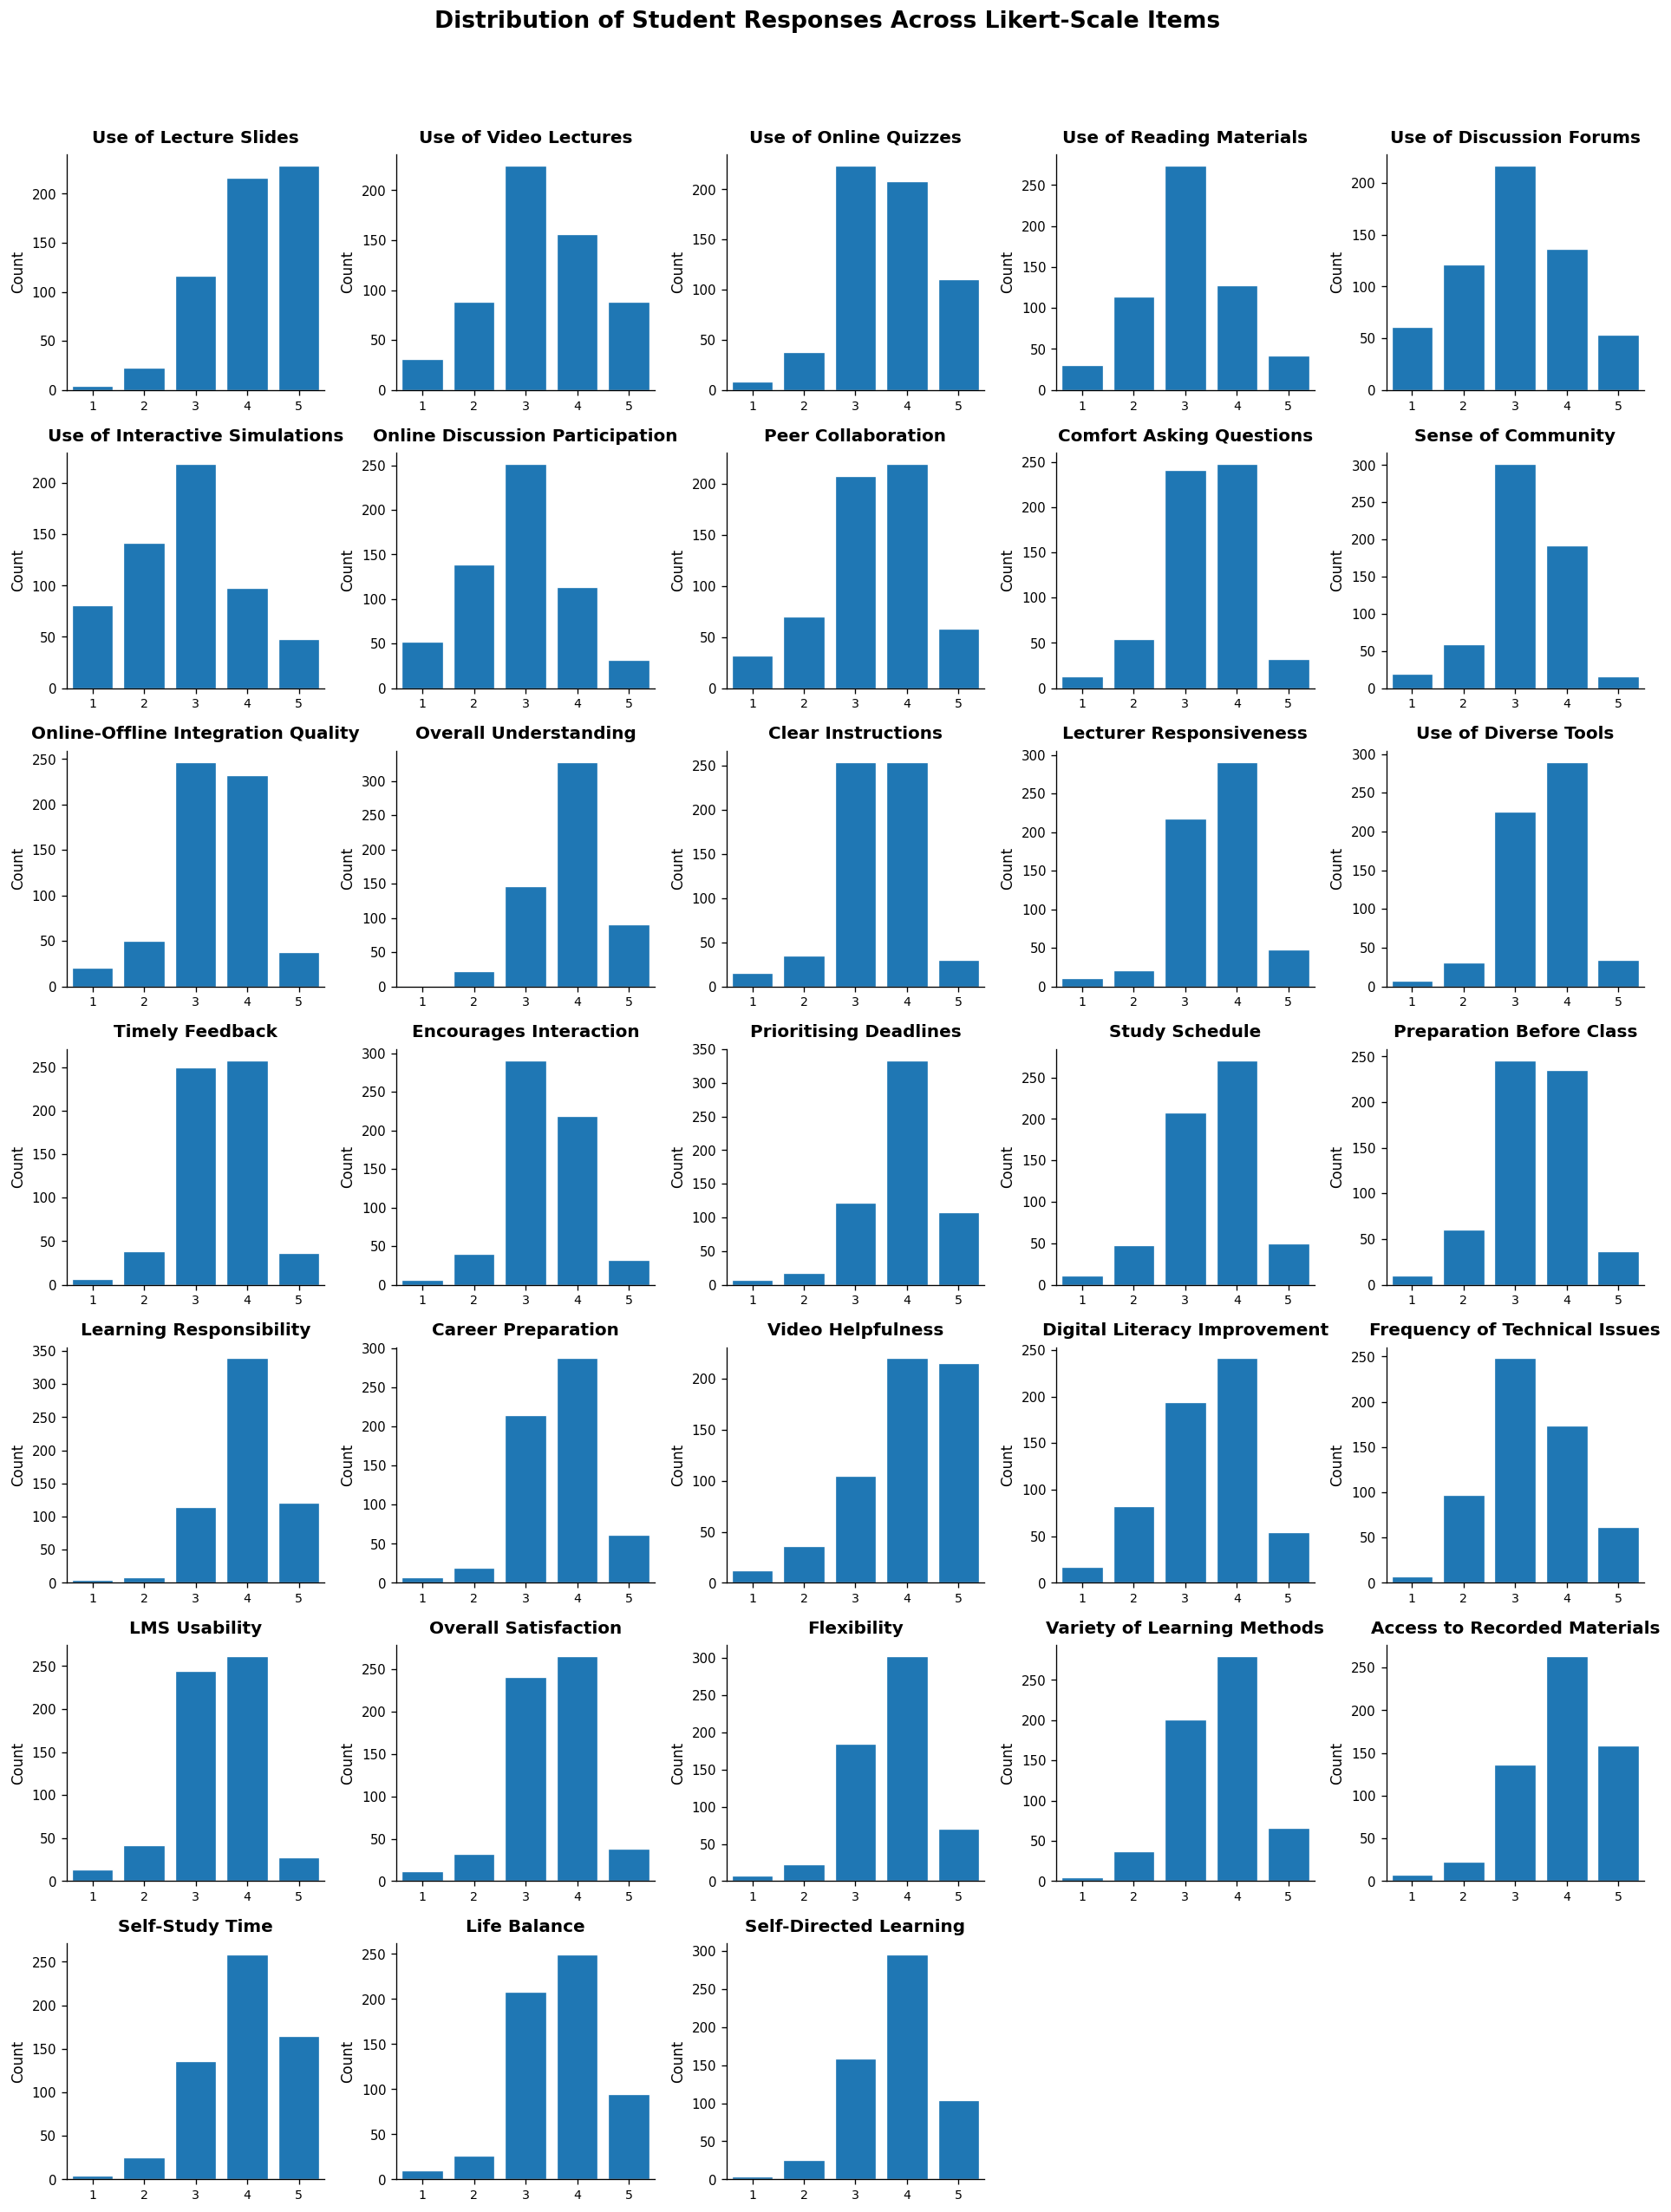

In [69]:
# ── Distribution of Likert-scale responses ────────────────────────────────
import math
import matplotlib.pyplot as plt

cols = oridinal_cols   # keep this if your variable name is really oridinal_cols
n_cols = 5
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, n_rows * 3)
)

axes = axes.flatten()

fig.suptitle(
    "Distribution of Student Responses Across Likert-Scale Items",
    fontsize=16,
    fontweight="bold",
    y=1.01
)

for i, col in enumerate(cols):
    vc = df[col].value_counts().sort_index()

    axes[i].bar(
        vc.index,
        vc.values,
        edgecolor="white",
        linewidth=0.8
    )

    axes[i].set_title(
        pl(col),
        fontsize=12,
        fontweight="bold",
        pad=8
    )

    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].set_xticks([1, 2, 3, 4, 5])
    axes[i].set_xlim(0.5, 5.5)

    # Clean thesis style
    axes[i].grid(False)
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### 2.2 Bivariate Analysis

#### 2.2.1  Satisfaction by Education Level & Enrollment Status

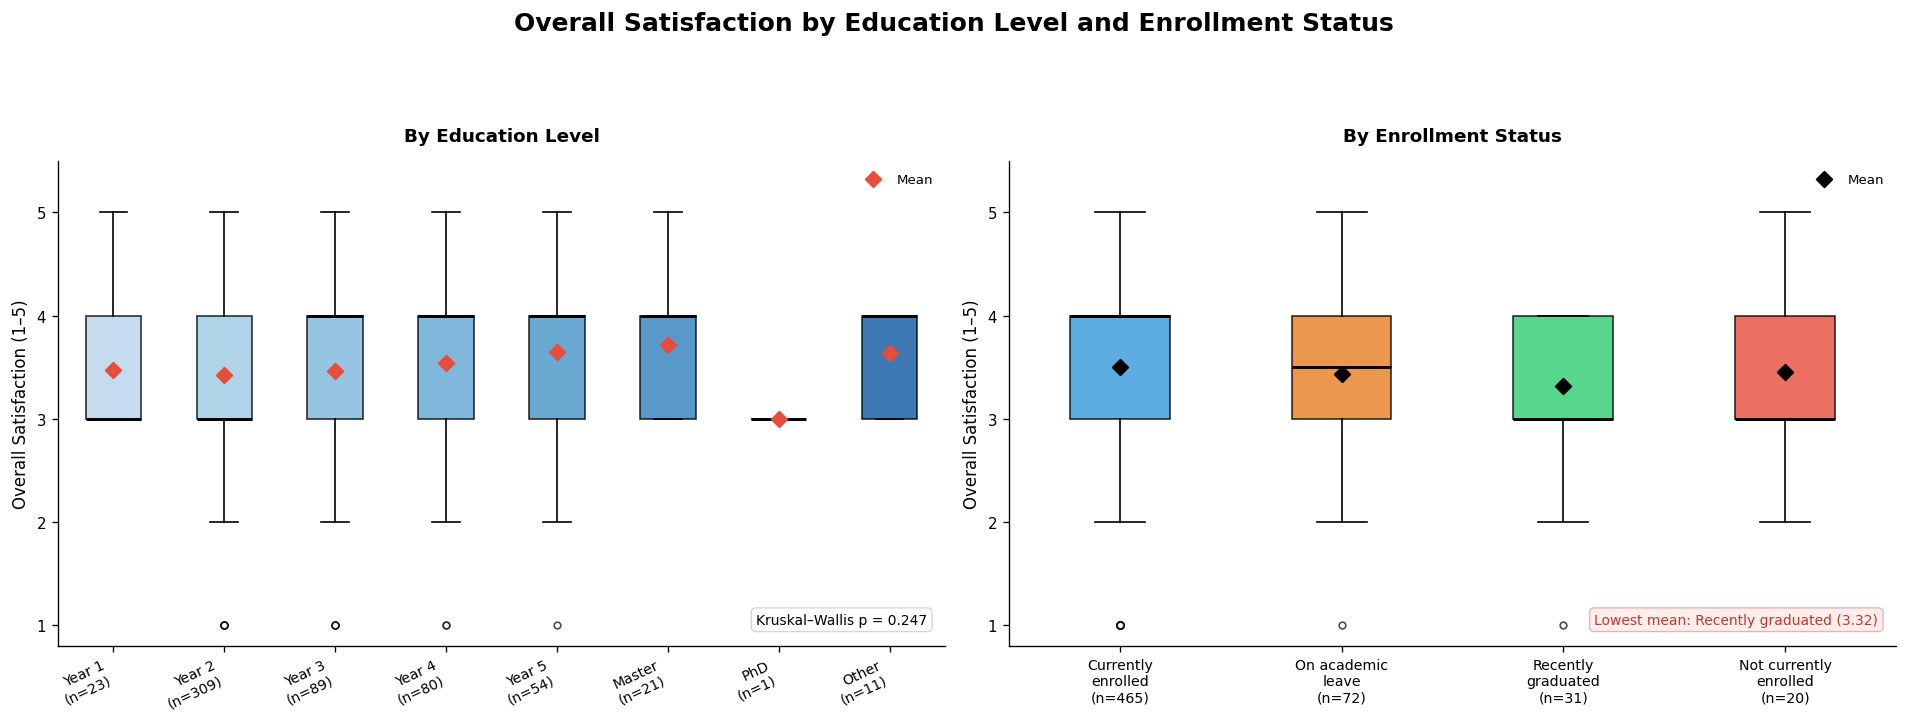

In [70]:
# ── 3.2.1 Satisfaction by education level and enrollment status ─────────
import numpy as np
import matplotlib.pyplot as plt
import textwrap
from scipy.stats import kruskal

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 9,
    "figure.dpi": 120
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5.8))

fig.suptitle(
    "Overall Satisfaction by Education Level and Enrollment Status",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

rating_col = "overall_satisfaction"

def wrap_label(text, width=18):
    return "\n".join(textwrap.wrap(str(text), width=width))

def clean_edu_label(label):
    label = str(label)
    label = label.replace("Year1", "Year 1")
    label = label.replace("Year2", "Year 2")
    label = label.replace("Year3", "Year 3")
    label = label.replace("Year4", "Year 4")
    label = label.replace("Year5", "Year 5")
    label = label.replace("PHD", "PhD")
    return label

# ── Education level boxplot ─────────────────────────────────────────────
edu_order_full = [
    "Year1 - Freshman",
    "Year2 - Sophomore",
    "Year3 - Junior",
    "Year4 - Senior",
    "Year5 - Final Year",
    "Master",
    "PHD",
    "Other"
]

edu_order_present = [
    e for e in edu_order_full
    if e in df["education_level"].dropna().unique()
]

data_edu = [
    df.loc[df["education_level"] == e, rating_col].dropna().values
    for e in edu_order_present
]

ns_edu = [len(d) for d in data_edu]

labels_edu = [
    f"{clean_edu_label(e.split(' - ')[0] if ' - ' in e else e)}\n(n={n})"
    for e, n in zip(edu_order_present, ns_edu)
]

bp = axes[0].boxplot(
    data_edu,
    labels=labels_edu,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.8),
    boxprops=dict(linewidth=1.0),
    whiskerprops=dict(linewidth=1.0),
    capprops=dict(linewidth=1.0),
    flierprops=dict(
        marker="o",
        markersize=4,
        markerfacecolor="white",
        markeredgecolor="black",
        alpha=0.7
    )
)

colors_edu = plt.cm.Blues(np.linspace(0.30, 0.85, len(edu_order_present)))

for patch, color in zip(bp["boxes"], colors_edu):
    patch.set_facecolor(color)
    patch.set_alpha(0.80)

means_edu = [
    np.mean(d) if len(d) > 0 else np.nan
    for d in data_edu
]

axes[0].scatter(
    range(1, len(means_edu) + 1),
    means_edu,
    color="#e74c3c",
    zorder=5,
    s=45,
    marker="D",
    label="Mean"
)

axes[0].set_title(
    "By Education Level",
    fontweight="bold",
    pad=12
)

axes[0].set_ylabel("Overall Satisfaction (1–5)")
axes[0].set_ylim(0.8, 5.5)

plt.setp(
    axes[0].get_xticklabels(),
    rotation=25,
    ha="right"
)

valid_edu_groups = [d for d in data_edu if len(d) > 0]

if len(valid_edu_groups) >= 2:
    stat, p = kruskal(*valid_edu_groups)
    p_text = f"Kruskal–Wallis p = {p:.3f}"
else:
    p_text = "Kruskal–Wallis test not available"

axes[0].annotate(
    p_text,
    xy=(0.98, 0.04),
    xycoords="axes fraction",
    ha="right",
    va="bottom",
    fontsize=8.3,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="lightgray",
        linewidth=0.8,
        alpha=0.95
    )
)

axes[0].legend(
    fontsize=8,
    frameon=False,
    loc="upper right"
)


# ── Enrollment status boxplot ───────────────────────────────────────────
enroll_order = df["enrollment_status"].dropna().value_counts().index.tolist()

data_enroll = [
    df.loc[df["enrollment_status"] == s, rating_col].dropna().values
    for s in enroll_order
]

ns_enroll = [len(d) for d in data_enroll]

labels_enroll = [
    f"{wrap_label(s, width=16)}\n(n={n})"
    for s, n in zip(enroll_order, ns_enroll)
]

bp2 = axes[1].boxplot(
    data_enroll,
    labels=labels_enroll,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.8),
    boxprops=dict(linewidth=1.0),
    whiskerprops=dict(linewidth=1.0),
    capprops=dict(linewidth=1.0),
    flierprops=dict(
        marker="o",
        markersize=4,
        markerfacecolor="white",
        markeredgecolor="black",
        alpha=0.7
    )
)

colors_enroll = ["#3498db", "#e67e22", "#2ecc71", "#e74c3c", "#9b59b6"]

for patch, color in zip(bp2["boxes"], colors_enroll):
    patch.set_facecolor(color)
    patch.set_alpha(0.80)

means_enroll = [
    np.mean(d) if len(d) > 0 else np.nan
    for d in data_enroll
]

axes[1].scatter(
    range(1, len(means_enroll) + 1),
    means_enroll,
    color="black",
    zorder=5,
    s=45,
    marker="D",
    label="Mean"
)

axes[1].set_title(
    "By Enrollment Status",
    fontweight="bold",
    pad=12
)

axes[1].set_ylabel("Overall Satisfaction (1–5)")
axes[1].set_ylim(0.8, 5.5)

plt.setp(
    axes[1].get_xticklabels(),
    rotation=0,
    ha="center"
)

# Dynamic lowest-mean annotation
mean_series = (
    df.groupby("enrollment_status")[rating_col]
      .mean()
      .dropna()
      .sort_values()
)

if not mean_series.empty:
    lowest_group = mean_series.index[0]
    lowest_mean = mean_series.iloc[0]

    axes[1].annotate(
        f"Lowest mean: {wrap_label(lowest_group, 18)} ({lowest_mean:.2f})",
        xy=(0.98, 0.04),
        xycoords="axes fraction",
        ha="right",
        va="bottom",
        fontsize=8.3,
        color="#c0392b",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="#fdedec",
            edgecolor="#e6b0aa",
            linewidth=0.8,
            alpha=0.95
        )
    )

axes[1].legend(
    fontsize=8,
    frameon=False,
    loc="upper right"
)


# ── Clean thesis style ──────────────────────────────────────────────────
for ax in axes:
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

The purpose is to see whether students from different academic groups show different satisfaction levels.

Across enrollment statuses, overall satisfaction remains mostly concentrated between 3 and 4. Recently graduated respondents show the lowest mean satisfaction score, although the difference appears modest. This may suggest that students who have already completed their studies evaluate the blended learning experience slightly more critically than currently enrolled students.
Kruskal–Wallis p = 0.247.This means the difference in satisfaction across education levels is not statistically significant.

#### 2.2.2  Learning Format Preferences

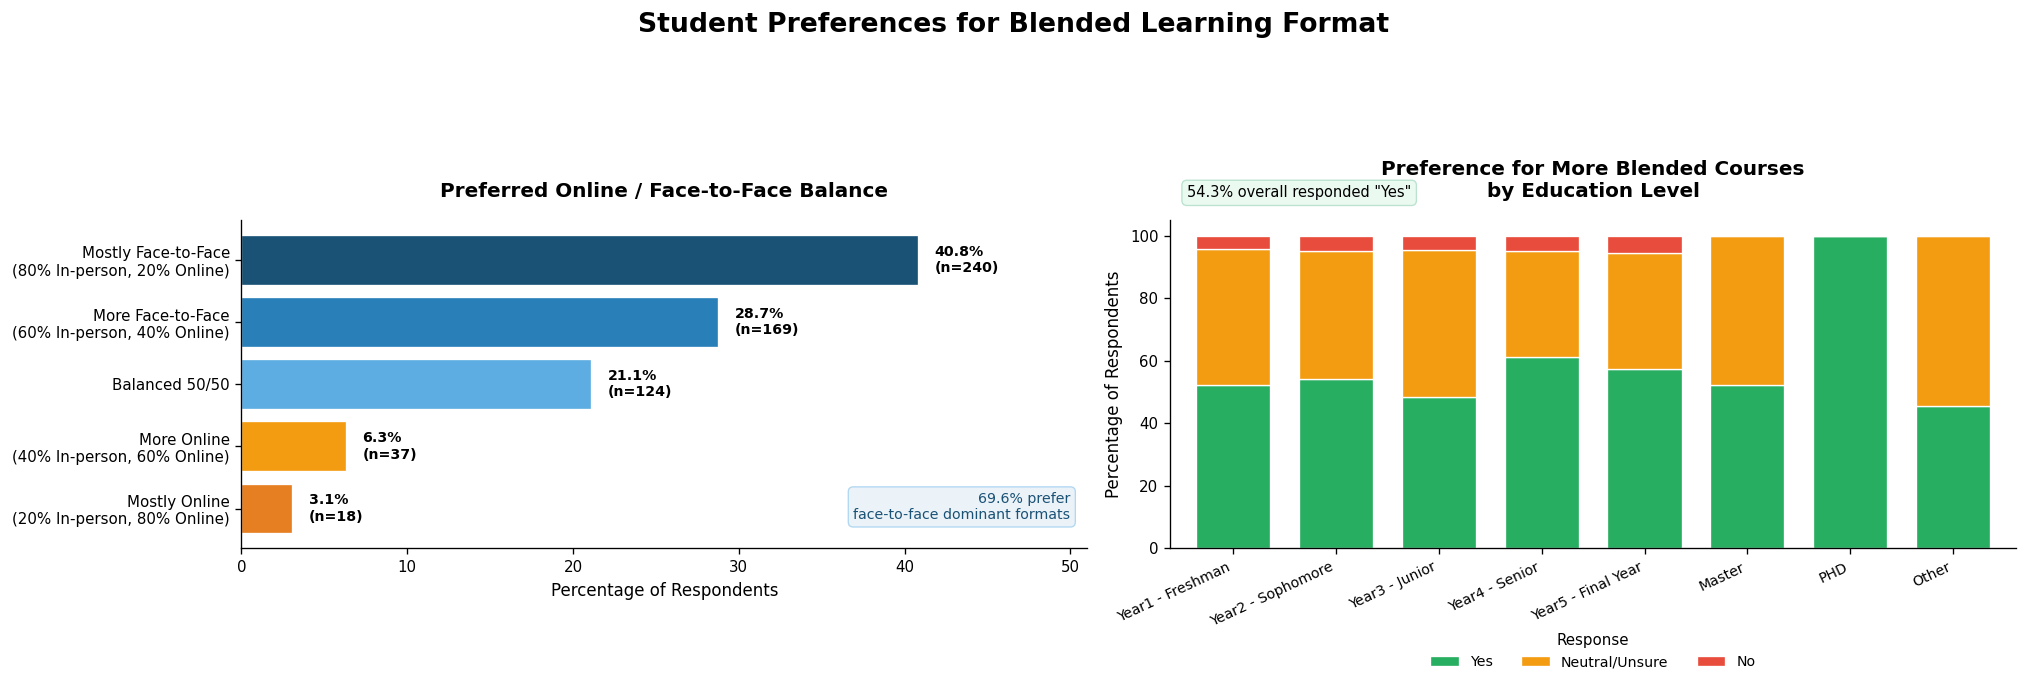

In [71]:
# ── 3.2.3 Learning format preferences ──────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import textwrap

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 120
})

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

fig.suptitle(
    "Student Preferences for Blended Learning Format",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

# Helper function
def wrap_label(text, width=34):
    return "\n".join(textwrap.wrap(str(text), width=width))


# ── Left panel: Preferred Online / Face-to-Face Balance ─────────────────
balance_counts = df["ideal_balance"].value_counts()

balance_label_map = {
    "Mostly Face-to-Face (e.g., 80% In-person, 20% Online)": "Mostly Face-to-Face\n(80% In-person, 20% Online)",
    "More Face-to-Face than Online (e.g., 60% In-person, 40% Online)": "More Face-to-Face\n(60% In-person, 40% Online)",
    "Balanced Half and Half (50% In-person, 50% Online)": "Balanced 50/50",
    "More Online than Face-to-Face (e.g., 40% In-person, 60% Online)": "More Online\n(40% In-person, 60% Online)",
    "Mostly Online (e.g., 20% In-person, 80% Online)": "Mostly Online\n(20% In-person, 80% Online)",

    # fallback for shortened values
    "80% F2F 20% Online": "Mostly Face-to-Face\n(80% F2F, 20% Online)",
    "60% F2F 40% Online": "More Face-to-Face\n(60% F2F, 40% Online)",
    "50/50": "Balanced 50/50",
    "40% F2F 60% Online": "More Online\n(40% F2F, 60% Online)",
    "20% F2F 80% Online": "Mostly Online\n(20% F2F, 80% Online)"
}

balance_order = [
    "Mostly Face-to-Face (e.g., 80% In-person, 20% Online)",
    "More Face-to-Face than Online (e.g., 60% In-person, 40% Online)",
    "Balanced Half and Half (50% In-person, 50% Online)",
    "More Online than Face-to-Face (e.g., 40% In-person, 60% Online)",
    "Mostly Online (e.g., 20% In-person, 80% Online)",
    "80% F2F 20% Online",
    "60% F2F 40% Online",
    "50/50",
    "40% F2F 60% Online",
    "20% F2F 80% Online"
]

balance_counts = balance_counts.reindex(
    [x for x in balance_order if x in balance_counts.index]
).dropna()

balance_pct = balance_counts / balance_counts.sum() * 100

balance_labels = [
    balance_label_map.get(label, wrap_label(label, 32))
    for label in balance_counts.index
]

colors_balance = [
    "#1a5276",
    "#2980b9",
    "#5dade2",
    "#f39c12",
    "#e67e22"
]

bars = axes[0].barh(
    balance_labels[::-1],
    balance_pct.values[::-1],
    color=colors_balance[:len(balance_pct)][::-1],
    edgecolor="white",
    linewidth=0.8
)

for bar, pct, count in zip(
    bars,
    balance_pct.values[::-1],
    balance_counts.values[::-1]
):
    axes[0].text(
        pct + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%\n(n={int(count)})",
        va="center",
        fontsize=8.5,
        fontweight="bold"
    )

axes[0].set_title(
    "Preferred Online / Face-to-Face Balance",
    fontweight="bold",
    pad=14
)

axes[0].set_xlabel("Percentage of Respondents")
axes[0].set_xlim(0, max(balance_pct.max() * 1.25, 50))

# Face-to-face dominant calculation
f2f_patterns = [
    "Mostly Face-to-Face",
    "More Face-to-Face",
    "80% F2F",
    "60% F2F"
]

f2f_dominant_count = balance_counts[
    balance_counts.index.to_series().astype(str).apply(
        lambda x: any(pattern in x for pattern in f2f_patterns)
    )
].sum()

f2f_dominant_pct = f2f_dominant_count / balance_counts.sum() * 100

axes[0].annotate(
    f"{f2f_dominant_pct:.1f}% prefer\nface-to-face dominant formats",
    xy=(0.98, 0.08),
    xycoords="axes fraction",
    ha="right",
    va="bottom",
    fontsize=8.5,
    color="#1a5276",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="#eaf2f8",
        edgecolor="#aed6f1",
        linewidth=0.8,
        alpha=0.95
    )
)


# ── Right panel: Preference for More Blended Courses ─────────────────────
pref_order = ["Yes", "Neutral/Unsure", "No"]
pref_colors = ["#27ae60", "#f39c12", "#e74c3c"]

# Safe education order
if "edu_order_full" in globals():
    edu_order = [
        e for e in edu_order_full
        if e in df["education_level"].dropna().unique()
    ]
else:
    edu_order = list(df["education_level"].dropna().value_counts().index)

pref_edu = (
    df.groupby(["education_level", "prefer_more_blended"], observed=True)
      .size()
      .unstack(fill_value=0)
      .reindex(edu_order)
)

for col in pref_order:
    if col not in pref_edu.columns:
        pref_edu[col] = 0

pref_edu = pref_edu[pref_order]
pref_edu_pct = pref_edu.div(pref_edu.sum(axis=1), axis=0) * 100

pref_edu_pct.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=pref_colors,
    edgecolor="white",
    linewidth=0.8,
    width=0.72
)

axes[1].set_title(
    "Preference for More Blended Courses\nby Education Level",
    fontweight="bold",
    pad=14
)

axes[1].set_xlabel("")
axes[1].set_ylabel("Percentage of Respondents")
axes[1].set_ylim(0, 105)

plt.setp(
    axes[1].get_xticklabels(),
    rotation=25,
    ha="right",
    fontsize=8.5
)

axes[1].legend(
    title="Response",
    fontsize=8.5,
    title_fontsize=9,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    frameon=False
)

overall_yes = (df["prefer_more_blended"] == "Yes").mean() * 100

# Annotation moved above the chart to avoid overlap
axes[1].annotate(
    f'{overall_yes:.1f}% overall responded "Yes"',
    xy=(0.02, 1.06),
    xycoords="axes fraction",
    ha="left",
    va="bottom",
    fontsize=8.8,
    clip_on=False,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="#eafaf1",
        edgecolor="#b7e1cd",
        linewidth=0.8,
        alpha=0.95
    )
)


# ── Clean thesis style ───────────────────────────────────────────────────
for ax in axes:
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0.08, 1, 0.92])
plt.show()

### 2.2.4  ITC vs Non-ITC Students — Comparative Analysis

#### 2.2.4.1  Group Sizes & Demographic Breakdown

  ITC vs Non-ITC — Group Sizes
  ITC        :  557  (94.7%)
  Non-ITC    :   31  (5.3%)
  Total      :  588


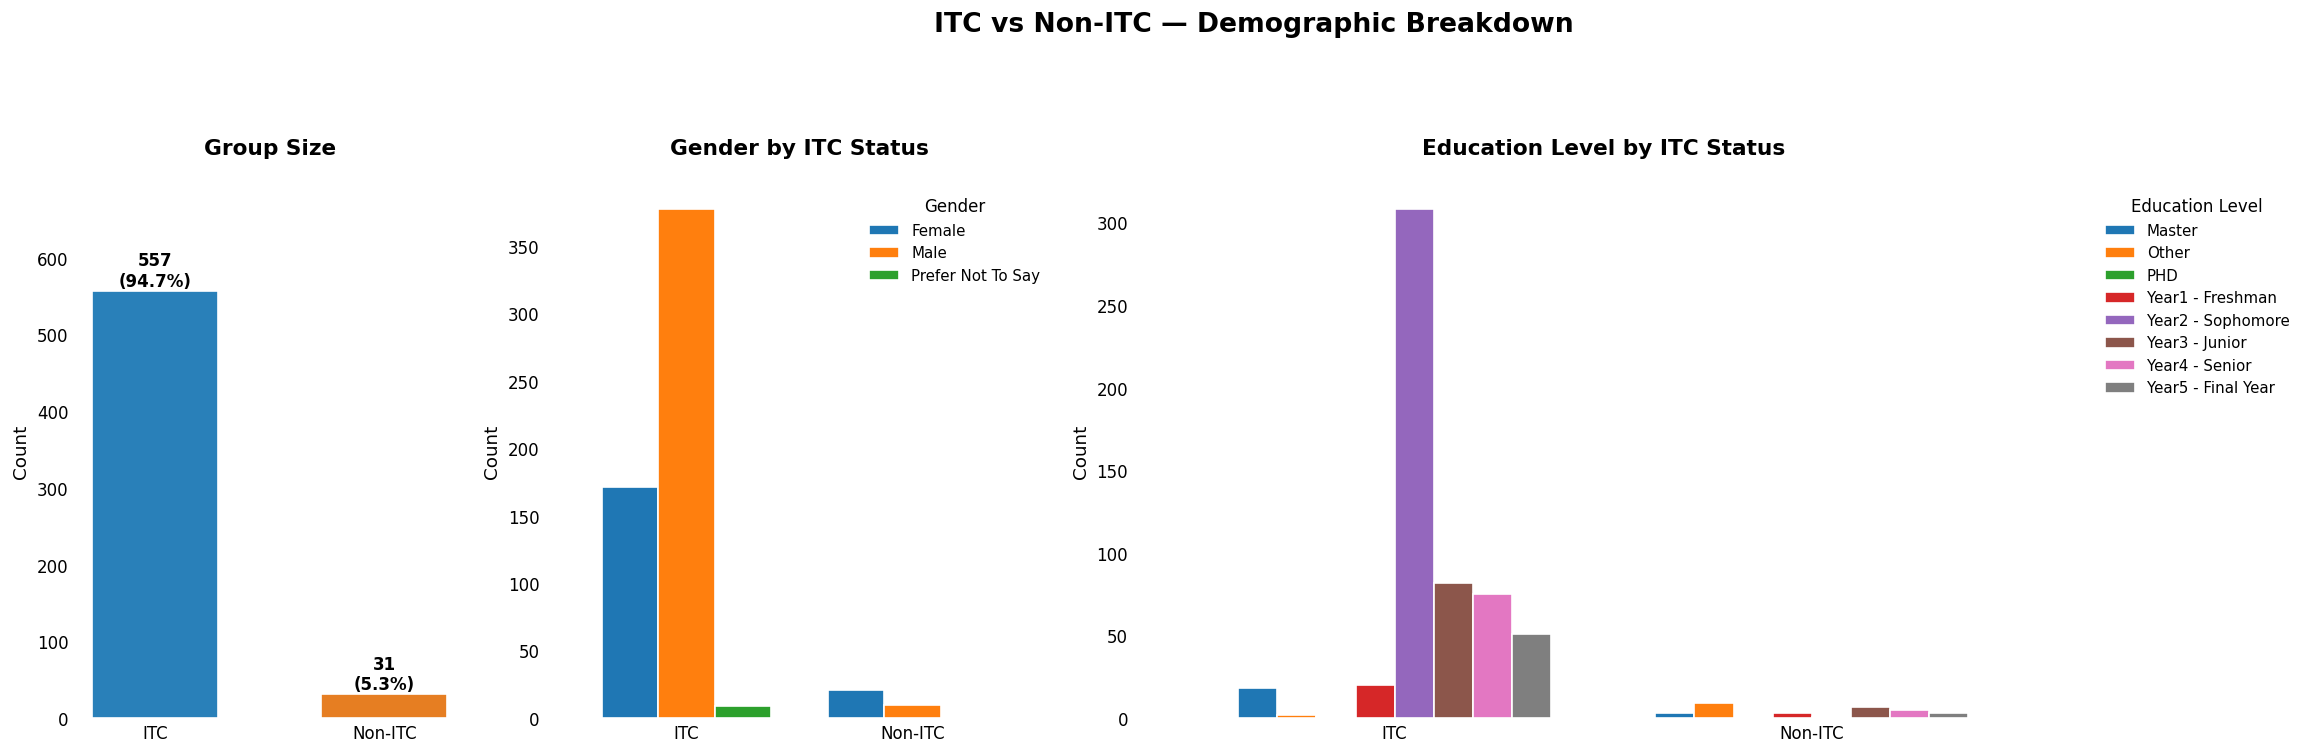

In [72]:
# ── ITC vs Non-ITC: group sizes and demographic overview ───────────────────────

ITC_COL = "is_itc_student"

ITC_PALETTE = {
    "ITC": "#2980b9",
    "Non-ITC": "#e67e22",
    "Unknown": "#888888"
}

# Guard
if ITC_COL not in df.columns:
    print(f"[!] '{ITC_COL}' column not found. Run cleaner first.")

else:
    # --------------------------------------------------
    # Convert boolean → readable labels
    # --------------------------------------------------
    df["itc_group"] = df[ITC_COL].map({
        True: "ITC",
        False: "Non-ITC"
    }).fillna("Unknown")

    # --------------------------------------------------
    # Group sizes
    # --------------------------------------------------
    groups = df["itc_group"].value_counts().sort_index()
    pcts = groups / groups.sum() * 100

    print("=" * 50)
    print("  ITC vs Non-ITC — Group Sizes")
    print("=" * 50)

    for grp in groups.index:
        print(f"  {grp:<10} : {groups[grp]:>4}  ({pcts[grp]:.1f}%)")

    print(f"  {'Total':<10} : {groups.sum():>4}")

    # --------------------------------------------------
    # Figure layout - larger and clearer
    # --------------------------------------------------
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(21, 6),
        gridspec_kw={
            "width_ratios": [1, 1.3, 2.4]
        }
    )

    fig.suptitle(
        "ITC vs Non-ITC — Demographic Breakdown",
        fontsize=16,
        fontweight="bold",
        y=1.04
    )

    # ==================================================
    # Panel 1: Group size
    # ==================================================
    colors = [
        ITC_PALETTE.get(g, "#888888")
        for g in groups.index
    ]

    bars = axes[0].bar(
        groups.index,
        groups.values,
        color=colors,
        edgecolor="white",
        width=0.55
    )

    for bar, val, pct in zip(bars, groups.values, pcts.values):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{val}\n({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    axes[0].set_title(
        "Group Size",
        fontsize=13,
        fontweight="bold",
        pad=18
    )

    axes[0].set_ylabel("Count", fontsize=11)
    axes[0].set_ylim(0, groups.max() * 1.25)
    axes[0].tick_params(axis="x", labelsize=10)
    axes[0].tick_params(axis="y", labelsize=10)

    # ==================================================
    # Panel 2: Gender by ITC status
    # ==================================================
    if "gender" in df.columns:

        gender_itc = (
            df.groupby(["itc_group", "gender"], observed=True)
              .size()
              .unstack(fill_value=0)
        )

        gender_itc.plot(
            kind="bar",
            ax=axes[1],
            edgecolor="white",
            width=0.75
        )

        axes[1].set_title(
            "Gender by ITC Status",
            fontsize=13,
            fontweight="bold",
            pad=18
        )

        axes[1].set_xlabel("")
        axes[1].set_ylabel("Count", fontsize=11)

        plt.setp(
            axes[1].get_xticklabels(),
            rotation=0,
            fontsize=10
        )

        axes[1].tick_params(axis="y", labelsize=10)

        axes[1].legend(
            title="Gender",
            fontsize=9,
            title_fontsize=10,
            frameon=False
        )

    else:
        axes[1].axis("off")
        axes[1].set_title(
            "Gender column not found",
            fontsize=11,
            fontweight="bold"
        )

    # ==================================================
    # Panel 3: Education level
    # ==================================================
    if "education_level" in df.columns:

        edu_itc = (
            df.groupby(["itc_group", "education_level"], observed=True)
              .size()
              .unstack(fill_value=0)
        )

        edu_itc.plot(
            kind="bar",
            ax=axes[2],
            edgecolor="white",
            width=0.75
        )

        axes[2].set_title(
            "Education Level by ITC Status",
            fontsize=13,
            fontweight="bold",
            pad=18
        )

        axes[2].set_xlabel("")
        axes[2].set_ylabel("Count", fontsize=11)

        plt.setp(
            axes[2].get_xticklabels(),
            rotation=0,
            fontsize=10
        )

        axes[2].tick_params(axis="y", labelsize=10)

        axes[2].legend(
            title="Education Level",
            fontsize=9,
            title_fontsize=10,
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            frameon=False
        )

    else:
        axes[2].axis("off")
        axes[2].set_title(
            "Education level column not found",
            fontsize=11,
            fontweight="bold"
        )

    # --------------------------------------------------
    # Clean thesis style: no grid, no bounding box
    # --------------------------------------------------
    for ax in axes:
        ax.grid(False)

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.tick_params(axis="both", length=0)

    # Leave space for external legend of last chart
    plt.tight_layout(rect=[0, 0, 0.92, 0.95])
    plt.show()

#### 2.2.4.2  All 33 Likert Items — ITC vs Non-ITC Heatmap

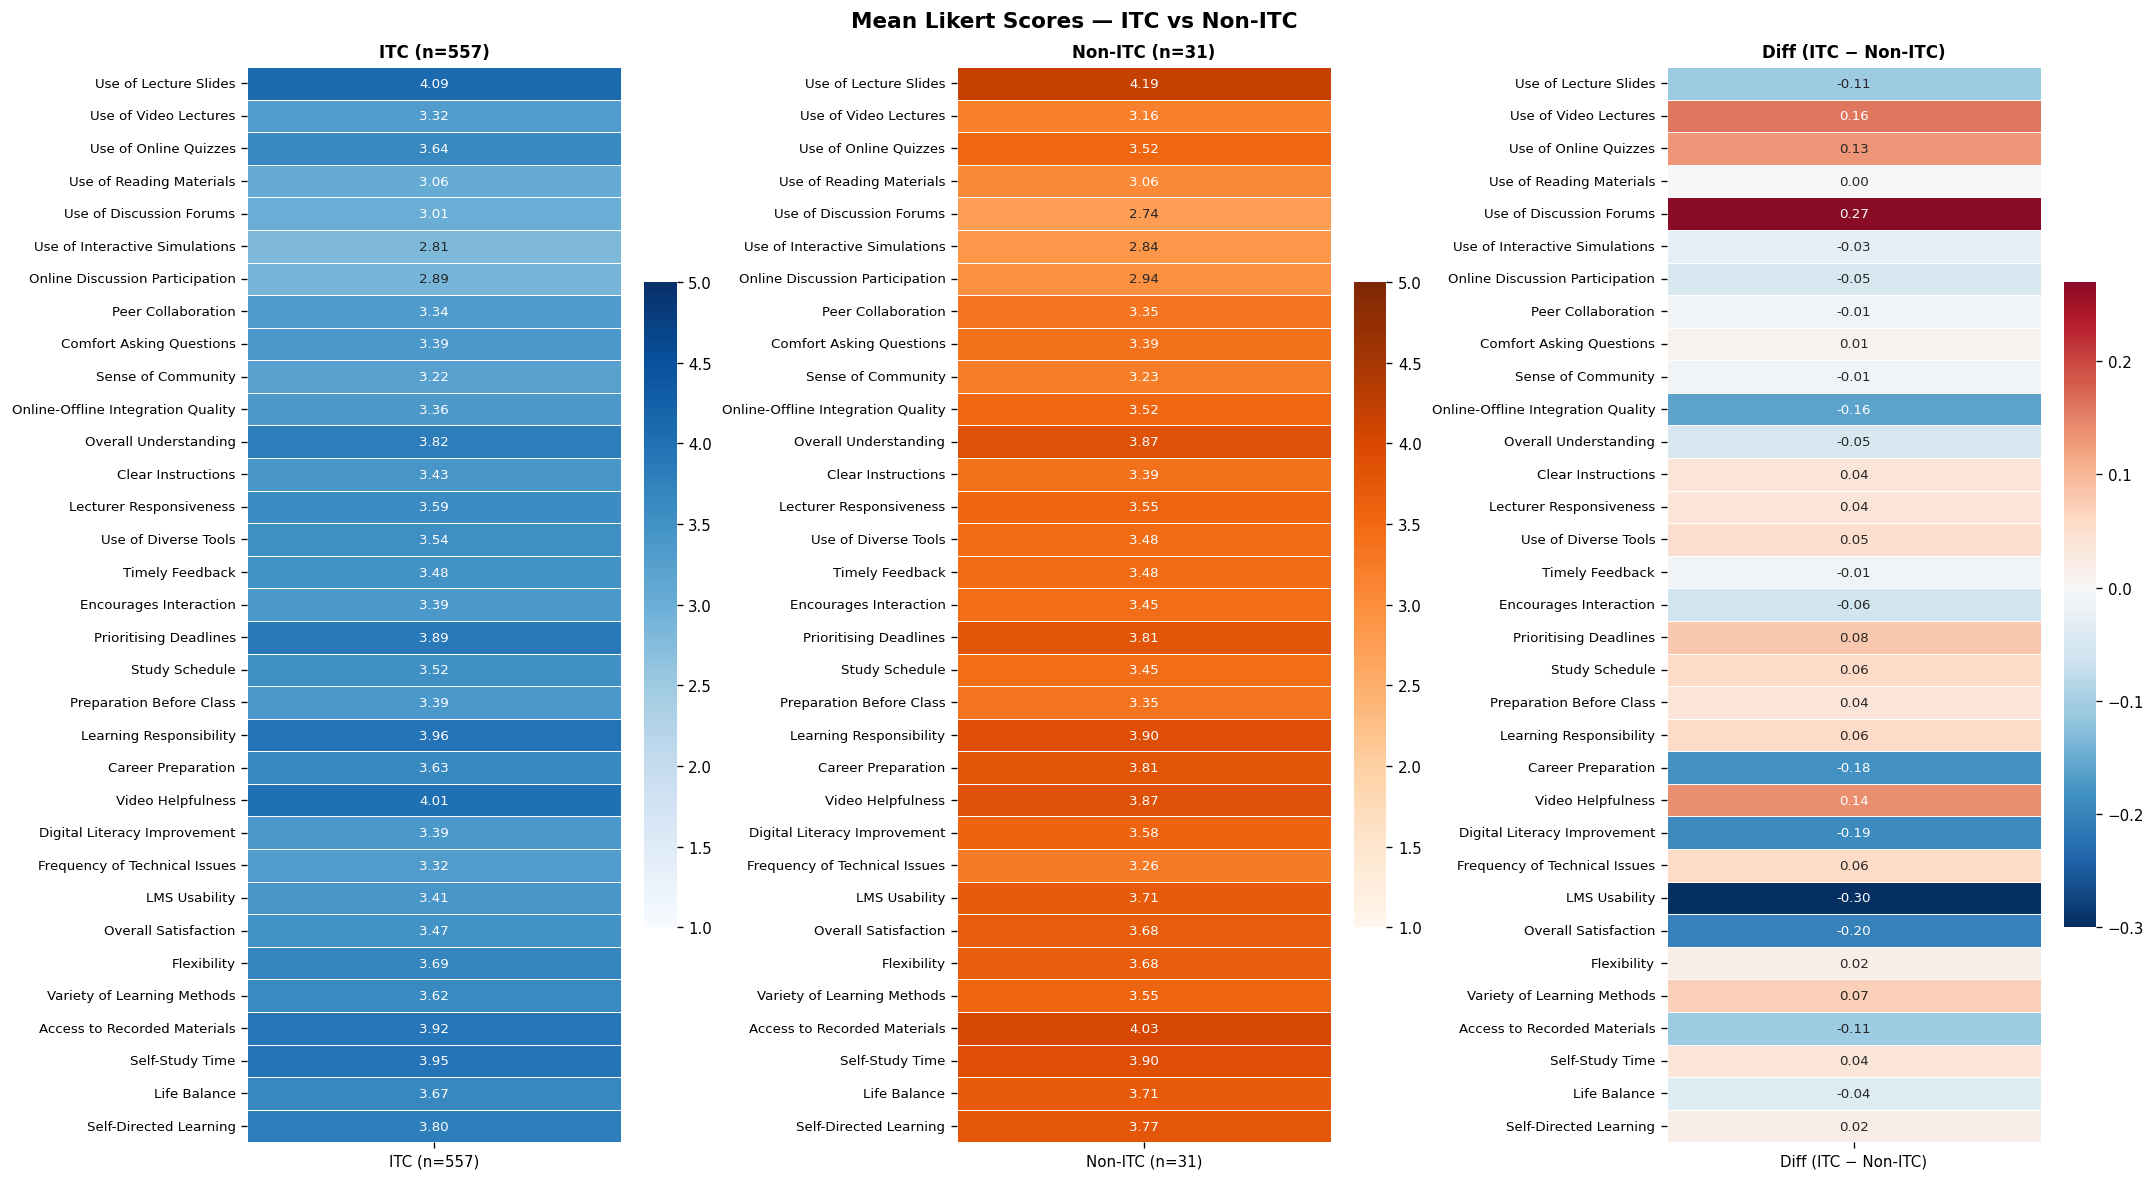


Top 5 items where ITC scores HIGHER than Non-ITC:
Use of Discussion Forums    0.270632
Use of Video Lectures       0.156483
Video Helpfulness           0.139804
Use of Online Quizzes       0.126600
Prioritising Deadlines      0.080442

Top 5 items where Non-ITC scores HIGHER than ITC:
LMS Usability                        -0.302137
Overall Satisfaction                 -0.203452
Digital Literacy Improvement         -0.194649
Career Preparation                   -0.176290
Online-Offline Integration Quality   -0.157063


In [73]:
# ── ITC vs Non-ITC: mean Likert scores across all ordinal items ───────────────

# Use readable label column created earlier
GROUP_COL = "itc_group"

if GROUP_COL not in df.columns:
    df[GROUP_COL] = df[ITC_COL].map({
        True: "ITC",
        False: "Non-ITC"
    }).fillna("Unknown")

# Keep only valid groups
analysis_df = df[df[GROUP_COL].isin(["ITC", "Non-ITC"])].copy()

# --------------------------------------------------
# Mean scores by group
# --------------------------------------------------
itc_means = (
    analysis_df.loc[
        analysis_df[GROUP_COL] == "ITC",
        oridinal_cols
    ]
    .mean()
)

non_itc_means = (
    analysis_df.loc[
        analysis_df[GROUP_COL] == "Non-ITC",
        oridinal_cols
    ]
    .mean()
)

diff = itc_means - non_itc_means

itc_n = (analysis_df[GROUP_COL] == "ITC").sum()
non_itc_n = (analysis_df[GROUP_COL] == "Non-ITC").sum()

# --------------------------------------------------
# Comparison dataframe
# --------------------------------------------------
compare_df = pd.DataFrame({
    f"ITC (n={itc_n})": itc_means.round(2),
    f"Non-ITC (n={non_itc_n})": non_itc_means.round(2),
    "Diff (ITC − Non-ITC)": diff.round(2),
})

compare_df = compare_df.rename(
    index={col: pl(col) for col in oridinal_cols}
)

# --------------------------------------------------
# Heatmap visualization
# --------------------------------------------------
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 10),
    gridspec_kw={"width_ratios": [1, 1, 1]}
)

fig.suptitle(
    "Mean Likert Scores — ITC vs Non-ITC",
    fontsize=13,
    fontweight="bold"
)

heatmap_configs = [
    (axes[0], compare_df.columns[0], "Blues", None),
    (axes[1], compare_df.columns[1], "Oranges", None),
    (axes[2], compare_df.columns[2], "RdBu_r", 0),
]

for ax, col, cmap, center in heatmap_configs:
    data = compare_df[[col]]

    sns.heatmap(
        data,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        center=center,
        vmin=(1 if center is None else None),
        vmax=(5 if center is None else None),
        linewidths=0.3,
        annot_kws={"size": 8},
        ax=ax,
        cbar_kws={"shrink": 0.6}
    )

    ax.set_title(
        col,
        fontsize=10,
        fontweight="bold"
    )

    ax.set_xlabel("")
    plt.setp(
        ax.get_yticklabels(),
        fontsize=8
    )

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Top differences summary
# --------------------------------------------------
pretty_diff = diff.rename(
    index={col: pl(col) for col in oridinal_cols}
)

print("\nTop 5 items where ITC scores HIGHER than Non-ITC:")
print(
    pretty_diff
    .sort_values(ascending=False)
    .head(5)
    .to_string()
)

print("\nTop 5 items where Non-ITC scores HIGHER than ITC:")
print(
    pretty_diff
    .sort_values(ascending=True)
    .head(5)
    .to_string()
)

#### 2.2.4.3 Satisfaction, understanding, and key perception items (violin)

In [ ]:
# ── ITC vs Non-ITC: key outcome variables — violin plots ─────────────────────

# Use readable label column created earlier
GROUP_COL = "itc_group"

if GROUP_COL not in df.columns:
    df[GROUP_COL] = df[ITC_COL].map({
        True: "ITC",
        False: "Non-ITC"
    }).fillna("Unknown")

# --------------------------------------------------
# Key outcome variables
# --------------------------------------------------
key_outcomes = [
    ("overall_satisfaction", "Overall Satisfaction"),
    ("overall_understanding", "Overall Understanding"),
    ("career_preparation", "Career Preparation"),
    (
        "lct_foster_interaction"
        if "lct_foster_interaction" in df.columns
        else "lect_foster_interaction",
        "Lecturer Interaction"
    ),
    ("self_responsibility", "Self Responsibility"),
    ("sense_of_community", "Sense of Community"),
]

# Keep only columns that actually exist
key_outcomes = [
    (col, label)
    for col, label in key_outcomes
    if col in df.columns
]

if not key_outcomes:
    print("[!] No key outcome columns found.")

else:
    # --------------------------------------------------
    # Figure layout
    # --------------------------------------------------
    fig, axes = plt.subplots(
        1,
        len(key_outcomes),
        figsize=(4 * len(key_outcomes), 5)
    )

    # Handle single subplot case
    if len(key_outcomes) == 1:
        axes = [axes]

    fig.suptitle(
        "Key Outcome Variables — ITC vs Non-ITC",
        fontsize=13,
        fontweight="bold"
    )

    # --------------------------------------------------
    # Violin plots
    # --------------------------------------------------
    for ax, (col, title) in zip(axes, key_outcomes):

        itc_data = (
            df.loc[
                df[GROUP_COL] == "ITC",
                col
            ]
            .dropna()
            .values
        )

        non_itc_data = (
            df.loc[
                df[GROUP_COL] == "Non-ITC",
                col
            ]
            .dropna()
            .values
        )

        # Skip empty columns safely
        if len(itc_data) == 0 and len(non_itc_data) == 0:
            ax.set_visible(False)
            continue

        vp = ax.violinplot(
            [itc_data, non_itc_data],
            showmedians=True,
            showmeans=False
        )

        # Styling
        vp["bodies"][0].set_facecolor("#2980b9")
        vp["bodies"][0].set_alpha(0.65)

        vp["bodies"][1].set_facecolor("#e67e22")
        vp["bodies"][1].set_alpha(0.65)

        vp["cmedians"].set_color("black")

        ax.set_xticks([1, 2])
        ax.set_xticklabels(
            ["ITC", "Non-ITC"],
            fontsize=9
        )

        ax.set_title(
            title,
            fontsize=9,
            fontweight="bold"
        )

        ax.set_ylabel("Score (1–5)")
        ax.set_ylim(0.5, 5.5)
        ax.yaxis.set_tick_params(labelsize=8)

        # --------------------------------------------------
        # Annotate median values
        # --------------------------------------------------
        for pos, values in [
            (1, itc_data),
            (2, non_itc_data)
        ]:
            if len(values):
                median_val = np.median(values)

                ax.text(
                    pos,
                    median_val + 0.15,
                    f"{median_val:.1f}",
                    ha="center",
                    fontsize=8,
                    color="black",
                    fontweight="bold"
                )

    plt.tight_layout()
    plt.show()

#### 2.2.4.4 Challenge prevalence ITC vs Non-ITC (grouped bar)

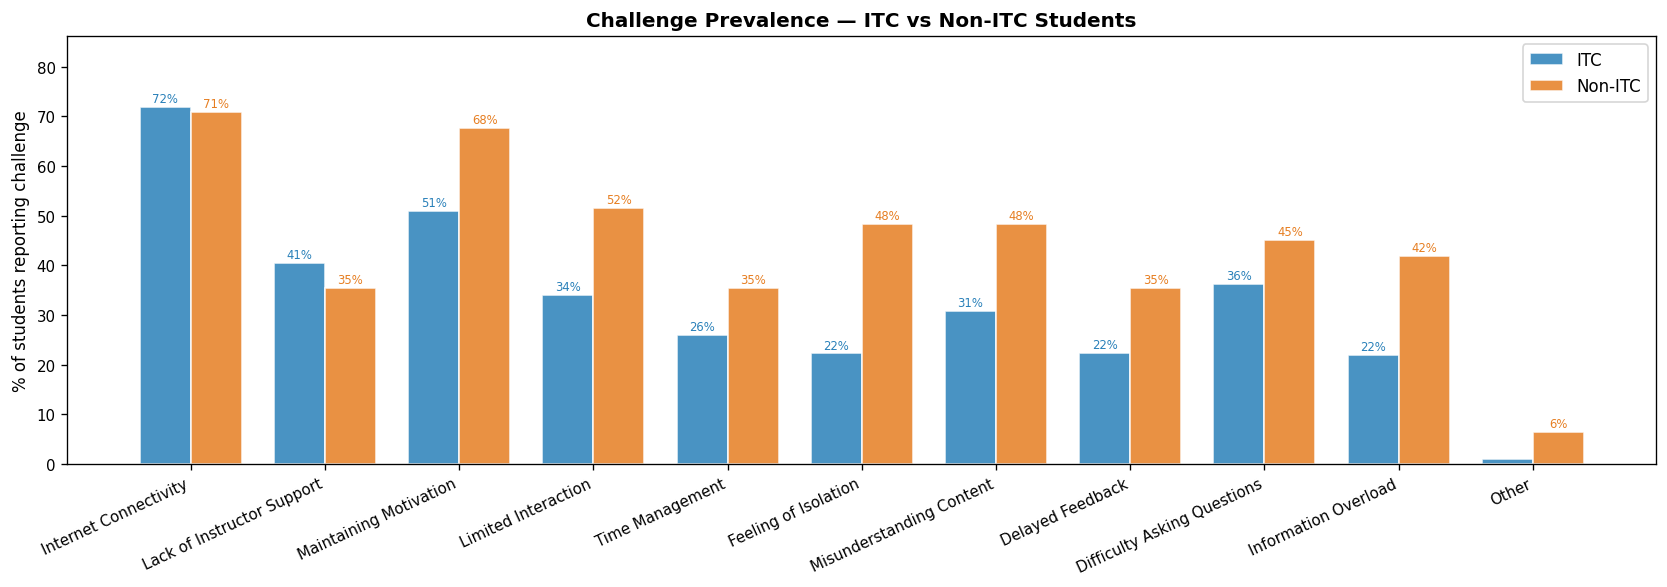


Challenge Prevalence — ITC vs Non-ITC
                             ITC %  Non-ITC %  Diff (ITC−Non)
Lack of Instructor Support    40.6       35.5             5.1
Internet Connectivity         71.8       71.0             0.8
Other                          1.1        6.5            -5.4
Difficulty Asking Questions   36.3       45.2            -8.9
Time Management               26.0       35.5            -9.5
Delayed Feedback              22.4       35.5           -13.0
Maintaining Motivation        51.0       67.7           -16.8
Limited Interaction           34.1       51.6           -17.5
Misunderstanding Content      30.9       48.4           -17.5
Information Overload          21.9       41.9           -20.0
Feeling of Isolation          22.3       48.4           -26.1


In [ ]:
# ── Challenge prevalence: ITC vs Non-ITC students ────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GROUP_COL = "itc_group"
ITC_COL = "is_itc_student"

if ITC_COL not in df.columns:
    print(f"[!] '{ITC_COL}' column not found. Cannot compare ITC vs Non-ITC groups.")

else:
    if GROUP_COL not in df.columns:
        df[GROUP_COL] = df[ITC_COL].map({
            True: "ITC",
            False: "Non-ITC"
        }).fillna("Unknown")

    if "MULTI_GROUPS" not in globals():
        if "multi_groups" in globals():
            MULTI_GROUPS = {
                g: [c for c in cols if c in df.columns]
                for g, cols in multi_groups.items()
            }
        else:
            MULTI_GROUPS = {}

    CH_COLS = MULTI_GROUPS.get("challenges", [])

    if not CH_COLS:
        CH_COLS = [
            c for c in df.columns
            if c.startswith("ch_")
        ]

    if "pl" in globals():
        CH_LABELS_MAP = {
            col: pl(col)
            for col in CH_COLS
        }
    else:
        CH_LABELS_MAP = {
            col: col.replace("_", " ").title()
            for col in CH_COLS
        }

    valid_ch_cols = [
        col for col in CH_COLS
        if col in df.columns
    ]

    if valid_ch_cols:
        itc_rates = (
            df.loc[df[GROUP_COL] == "ITC", valid_ch_cols]
            .fillna(0)
            .mean()
            * 100
        )

        non_itc_rates = (
            df.loc[df[GROUP_COL] == "Non-ITC", valid_ch_cols]
            .fillna(0)
            .mean()
            * 100
        )

        labels = [
            CH_LABELS_MAP.get(col, col)
            for col in valid_ch_cols
        ]

        x = np.arange(len(valid_ch_cols))
        width = 0.38

        fig, ax = plt.subplots(figsize=(14, 5))

        bars1 = ax.bar(
            x - width / 2,
            itc_rates.values,
            width,
            label="ITC",
            color="#2980b9",
            alpha=0.85,
            edgecolor="white"
        )

        bars2 = ax.bar(
            x + width / 2,
            non_itc_rates.values,
            width,
            label="Non-ITC",
            color="#e67e22",
            alpha=0.85,
            edgecolor="white"
        )

        for bar in bars1:
            if bar.get_height() > 2:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1,
                    f"{bar.get_height():.0f}%",
                    ha="center",
                    fontsize=7,
                    color="#2980b9"
                )

        for bar in bars2:
            if bar.get_height() > 2:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1,
                    f"{bar.get_height():.0f}%",
                    ha="center",
                    fontsize=7,
                    color="#e67e22"
                )

        ax.set_xticks(x)
        ax.set_xticklabels(
            labels,
            rotation=25,
            ha="right",
            fontsize=9
        )

        ax.set_ylabel("% of students reporting challenge")

        ax.set_title(
            "Challenge Prevalence — ITC vs Non-ITC Students",
            fontsize=12,
            fontweight="bold"
        )

        ax.legend(fontsize=10)

        max_rate = max(
            itc_rates.max(),
            non_itc_rates.max()
        )

        ax.set_ylim(
            0,
            max_rate * 1.2 if max_rate > 0 else 1
        )

        plt.tight_layout()
        plt.show()

        ch_compare = pd.DataFrame({
            "ITC %": itc_rates.round(1).values,
            "Non-ITC %": non_itc_rates.round(1).values,
            "Diff (ITC−Non)": (
                itc_rates - non_itc_rates
            ).round(1).values,
        }, index=labels)

        ch_compare = ch_compare.sort_values(
            "Diff (ITC−Non)",
            ascending=False
        )

        print("\nChallenge Prevalence — ITC vs Non-ITC")
        print(ch_compare.to_string())

    else:
        print(
            "[!] No valid ch_* binary columns found. "
            "Check preprocessing pipeline or parsed challenge columns."
        )

#### 2.2.4.5 Device and internet access comparison

In [ ]:
multi_groups

{'devices': ['device_mobile',
  'device_tablet',
  'device_laptop',
  'device_desktop',
  'device_other'],
 'internet_access': ['inet_mobile_data',
  'inet_home_wifi',
  'inet_public_wifi',
  'inet_university_wifi'],
 'coping_mechanisms': ['miss_resend_announcement',
  'miss_request_recording',
  'miss_ask_classmates',
  'miss_one_on_one',
  'miss_deadline_extension',
  'miss_self_study',
  'miss_ignore',
  'miss_other'],
 'challenges': ['ch_internet',
  'ch_no_instructor_support',
  'ch_motivation',
  'ch_limited_interaction',
  'ch_time_management',
  'ch_isolation',
  'ch_misunderstanding',
  'ch_delayed_feedback',
  'ch_asking_questions',
  'ch_info_overload',
  'ch_other']}

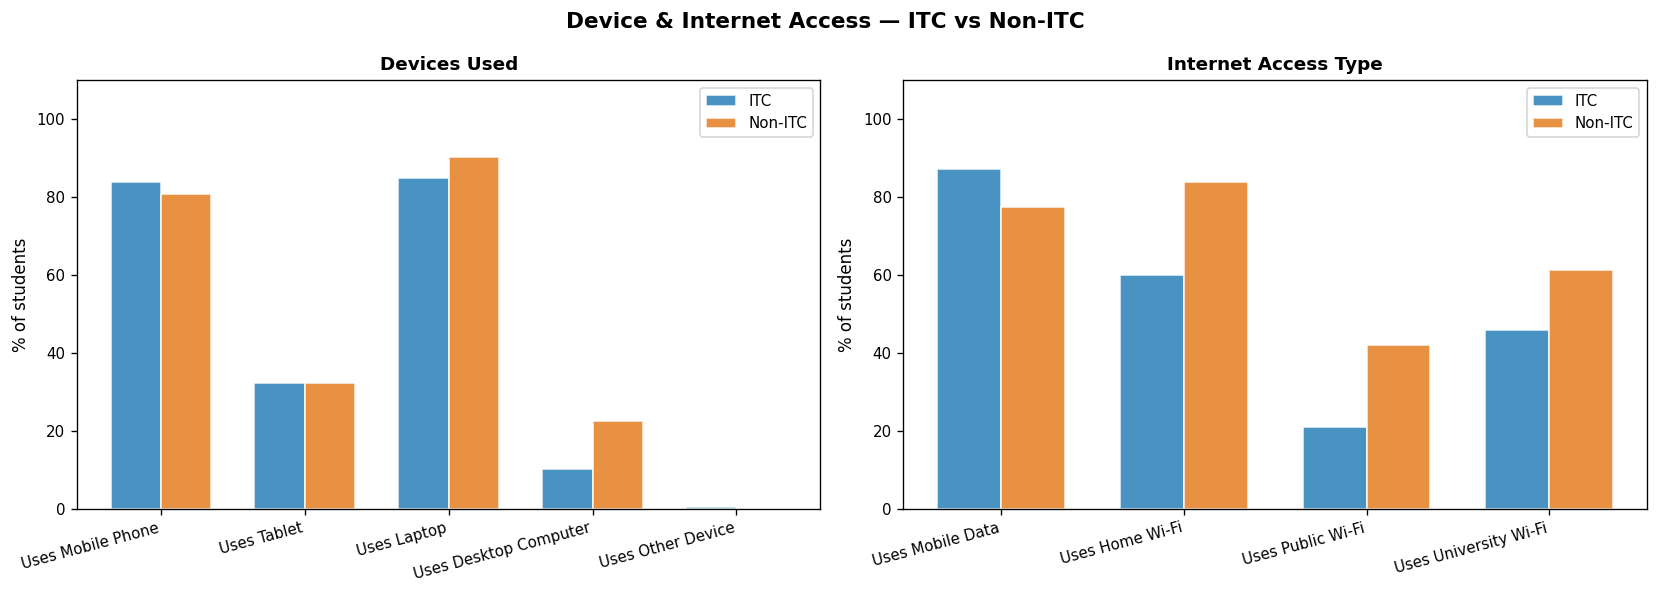

In [ ]:
# ── ITC vs Non-ITC: device and internet access patterns ──────────────────────

GROUP_COL = "itc_group"

# Create readable labels if missing
if GROUP_COL not in df.columns:
    df[GROUP_COL] = df[ITC_COL].map({
        True: "ITC",
        False: "Non-ITC"
    }).fillna("Unknown")

# --------------------------------------------------
# Column groups
# --------------------------------------------------
DEVICE_COLS = [
    col for col in multi_groups["devices"]
    if col in df.columns
]

INET_COLS = [
    col for col in multi_groups["internet_access"]
    if col in df.columns
]

DEVICE_LABELS = {
    col: pl(col)
    for col in DEVICE_COLS
}

INET_LABELS = {
    col: pl(col)
    for col in INET_COLS
}

# --------------------------------------------------
# Guard
# --------------------------------------------------
if DEVICE_COLS or INET_COLS:

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    fig.suptitle(
        "Device & Internet Access — ITC vs Non-ITC",
        fontsize=13,
        fontweight="bold"
    )

    panel_configs = [
        (
            axes[0],
            DEVICE_COLS,
            DEVICE_LABELS,
            "Devices Used"
        ),
        (
            axes[1],
            INET_COLS,
            INET_LABELS,
            "Internet Access Type"
        ),
    ]

    for ax, cols, labels_map, title in panel_configs:

        if not cols:
            ax.set_visible(False)
            continue

        # --------------------------------------------------
        # Calculate usage rates (%)
        # --------------------------------------------------
        itc_rates = (
            df.loc[
                df[GROUP_COL] == "ITC",
                cols
            ]
            .mean()
            * 100
        )

        non_itc_rates = (
            df.loc[
                df[GROUP_COL] == "Non-ITC",
                cols
            ]
            .mean()
            * 100
        )

        labels = [
            labels_map.get(col, col)
            for col in cols
        ]

        x = np.arange(len(cols))
        width = 0.35

        # --------------------------------------------------
        # Bar plots
        # --------------------------------------------------
        ax.bar(
            x - width / 2,
            itc_rates.values,
            width,
            label="ITC",
            color="#2980b9",
            alpha=0.85,
            edgecolor="white"
        )

        ax.bar(
            x + width / 2,
            non_itc_rates.values,
            width,
            label="Non-ITC",
            color="#e67e22",
            alpha=0.85,
            edgecolor="white"
        )

        # --------------------------------------------------
        # Formatting
        # --------------------------------------------------
        ax.set_xticks(x)

        ax.set_xticklabels(
            labels,
            rotation=15,
            ha="right",
            fontsize=9
        )

        ax.set_ylabel("% of students")

        ax.set_title(
            title,
            fontsize=11,
            fontweight="bold"
        )

        ax.set_ylim(0, 110)

        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

else:
    print(
        "[!] No valid device or internet access columns found. "
        "Check preprocessing pipeline or multi_groups config."
    )

#### 2.2.4.6 Social media hours and academic year distribution

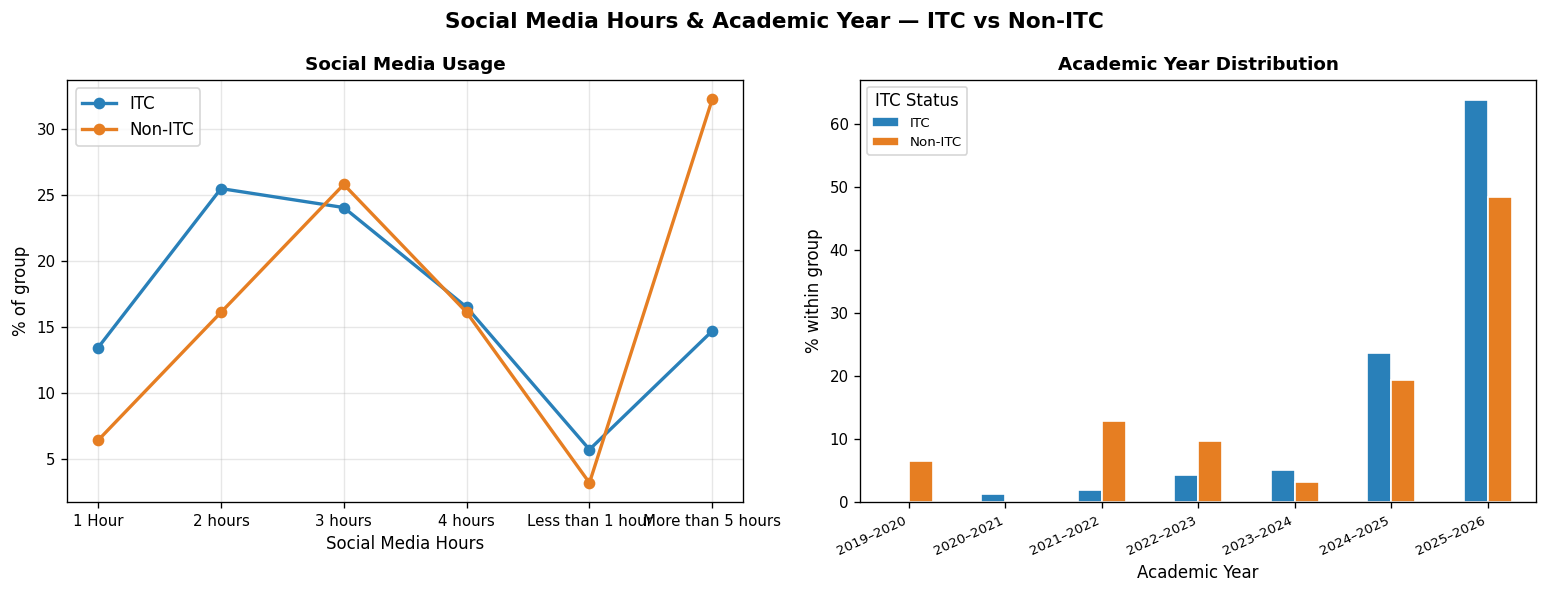

In [ ]:
# ── ITC vs Non-ITC: social media hours + academic year ───────────────────────

GROUP_COL = "itc_group"

# Ensure readable grouping
if GROUP_COL not in df.columns:
    df[GROUP_COL] = df[ITC_COL].map({
        True: "ITC",
        False: "Non-ITC"
    }).fillna("Unknown")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Social Media Hours & Academic Year — ITC vs Non-ITC",
    fontsize=13,
    fontweight="bold"
)

# ==================================================
# Panel 1: Social media usage
# ==================================================
if "social_media_hours" in df.columns:

    for grp, color in [("ITC", "#2980b9"), ("Non-ITC", "#e67e22")]:

        sub = df.loc[df[GROUP_COL] == grp, "social_media_hours"].dropna()

        if len(sub) == 0:
            continue

        counts = sub.value_counts().sort_index()

        pct = (counts / counts.sum()) * 100

        axes[0].plot(
            pct.index,
            pct.values,
            "o-",
            color=color,
            lw=2,
            ms=6,
            label=grp
        )

    axes[0].set_xlabel("Social Media Hours")
    axes[0].set_ylabel("% of group")
    axes[0].set_title(
        "Social Media Usage",
        fontsize=11,
        fontweight="bold"
    )
    axes[0].legend()
    axes[0].grid(alpha=0.3)

# ==================================================
# Panel 2: Academic year distribution
# ==================================================
if "academic_year" in df.columns:

    ay_counts = (
        df.groupby([GROUP_COL, "academic_year"], observed=True)
          .size()
          .unstack(fill_value=0)
    )

    ay_pct = ay_counts.div(ay_counts.sum(axis=1), axis=0) * 100

    ay_pct.T.plot(
        kind="bar",
        ax=axes[1],
        edgecolor="white",
        color=["#2980b9", "#e67e22"][:len(ay_pct)]
    )

    axes[1].set_title(
        "Academic Year Distribution",
        fontsize=11,
        fontweight="bold"
    )

    axes[1].set_xlabel("Academic Year")
    axes[1].set_ylabel("% within group")

    plt.setp(
        axes[1].get_xticklabels(),
        rotation=25,
        ha="right",
        fontsize=8
    )

    axes[1].legend(
        title="ITC Status",
        fontsize=8
    )

plt.tight_layout()
plt.show()

### 2.3  Association Analysis — CA 

**Correspondence Analysis (CA)** examines pairwise categorical associations between demographic and preference variables.

Both analyses complement the bivariate distributions in Section 3.2 by showing how categorical variables co-occur and cluster together.

#### 2.3.1  CA — Correspondence Analysis (Pairwise Categorical Relationships)

Pairwise correspondence analysis was used as an exploratory technique to visualize associations between selected categorical variables. Each panel should be interpreted independently. Chi-square tests confirm statistical significance of each association.

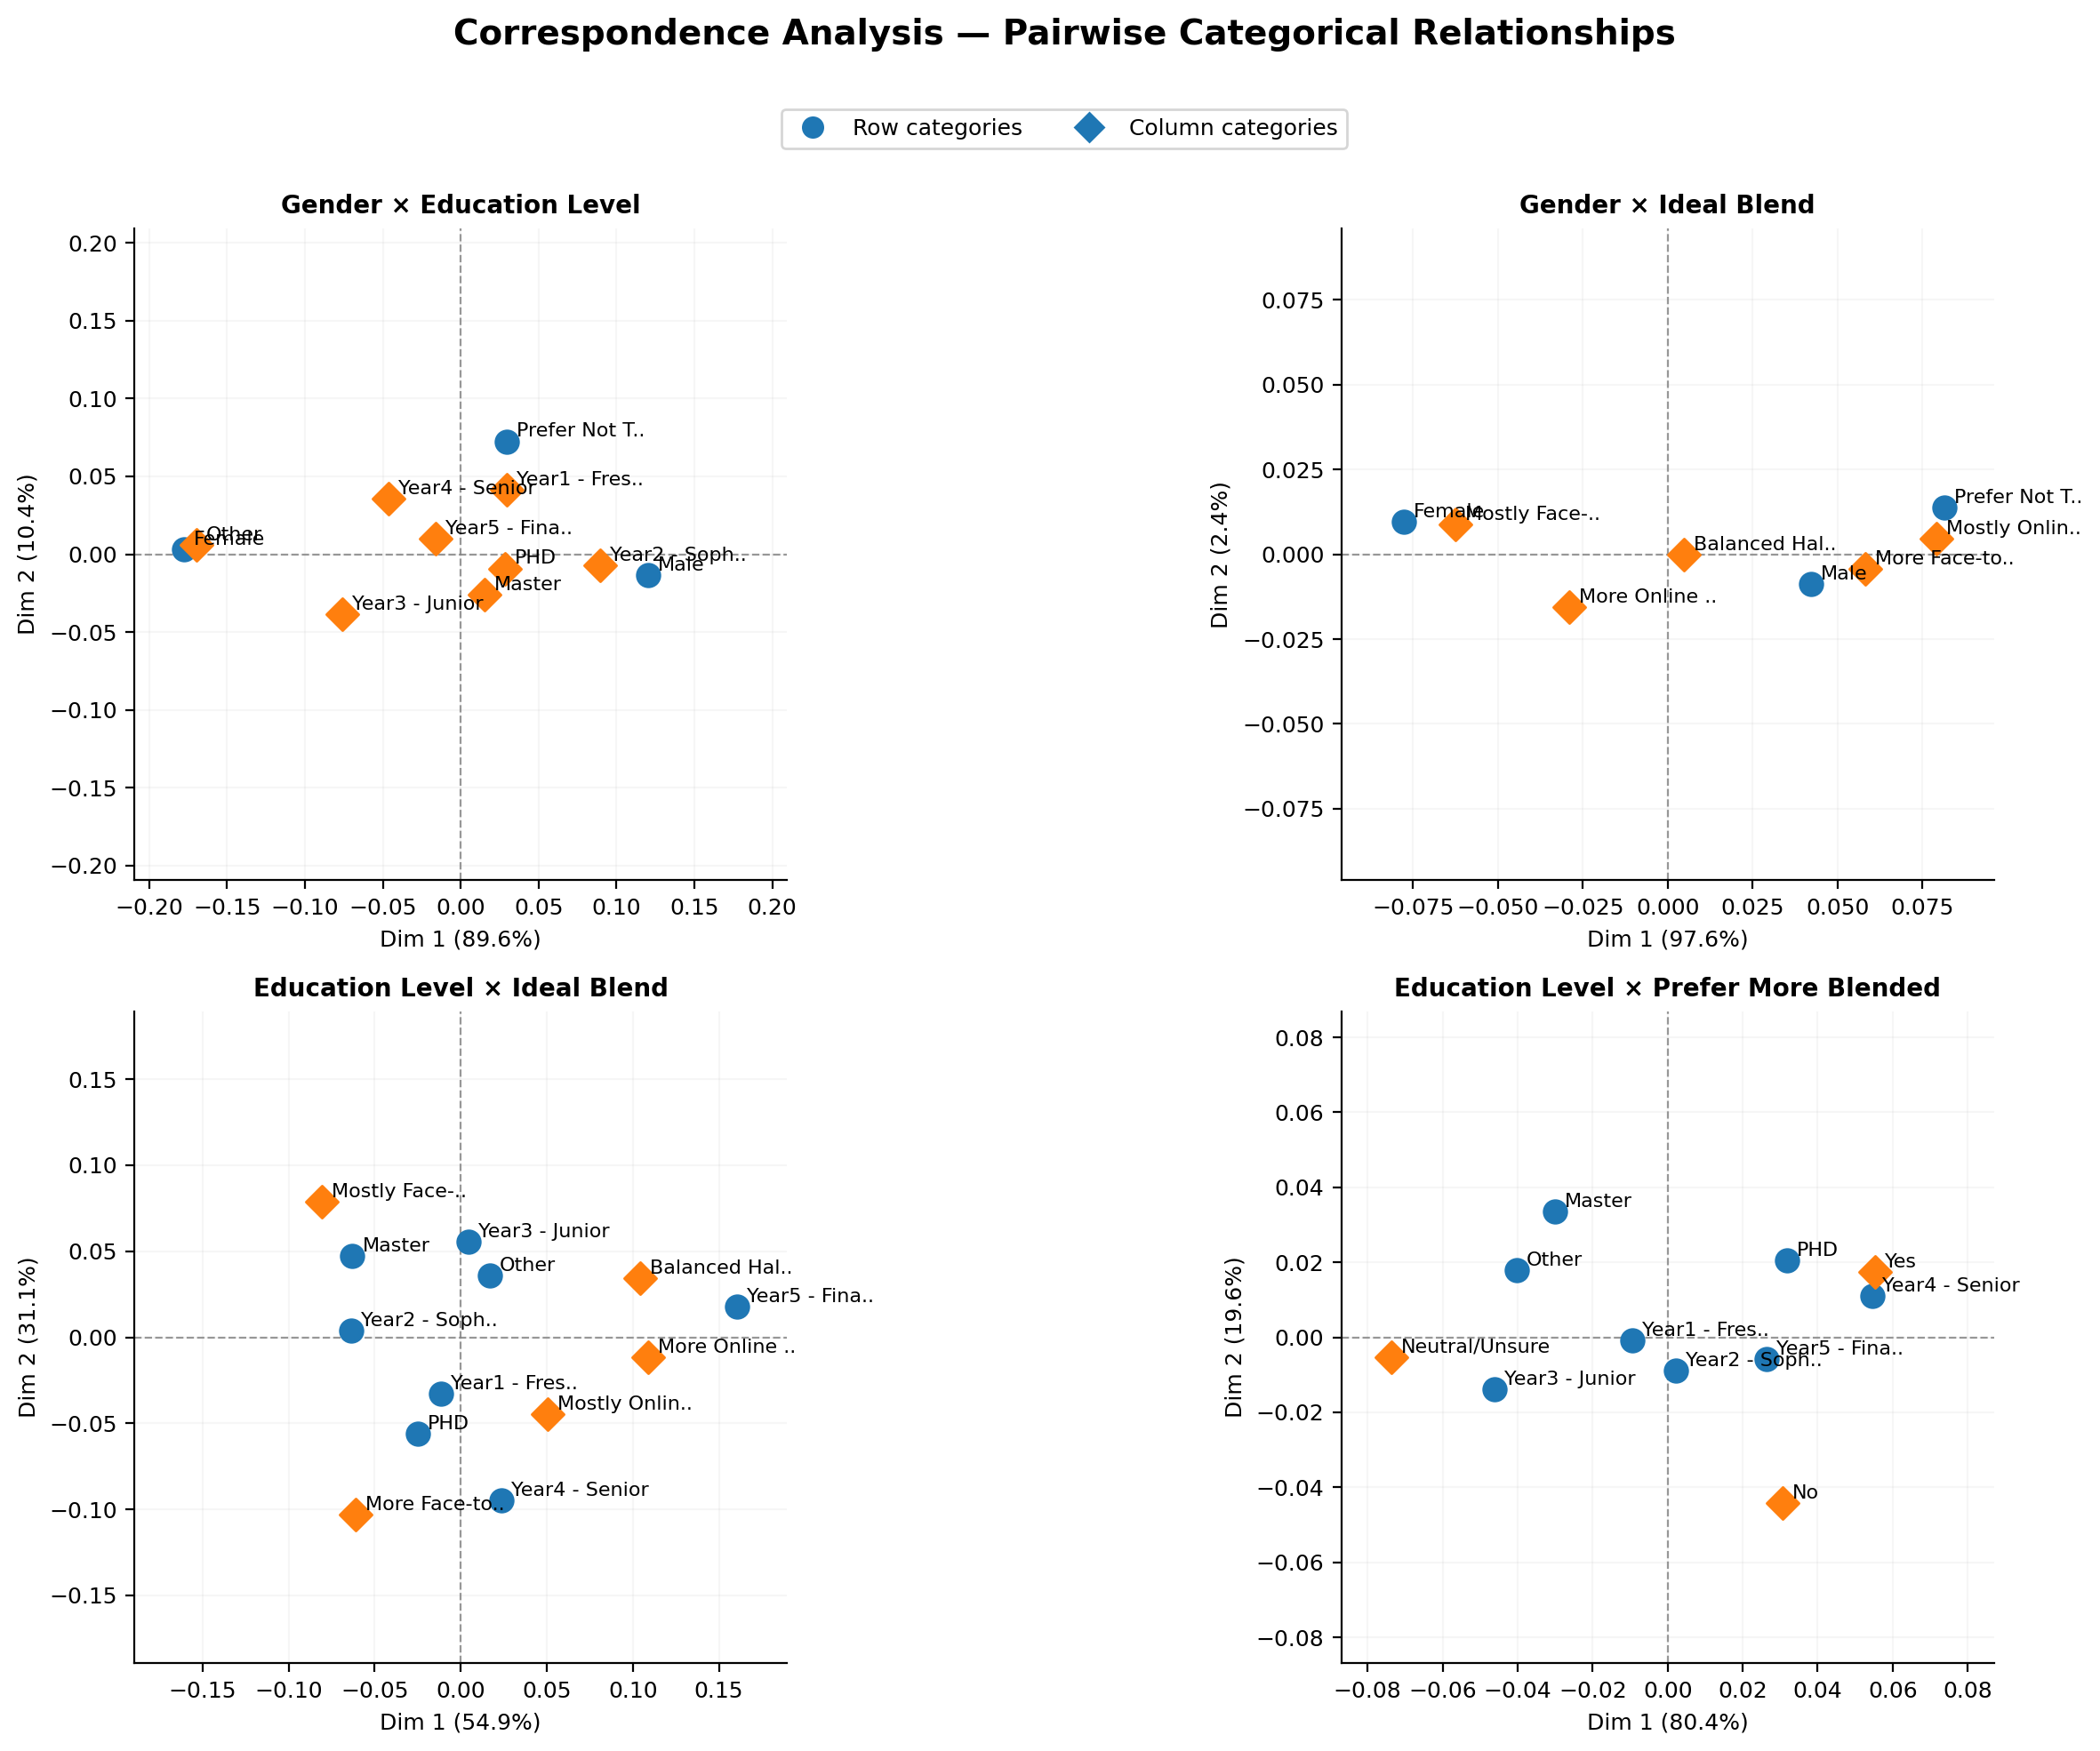

In [ ]:
# ── 10.1 CA pairs ────────────────────────────────────────────────────────────
CA_PAIRS = [
    ('gender',          'education_level',     'Gender × Education Level'),
    ('gender',          'ideal_balance',       'Gender × Ideal Blend'),
    ('education_level', 'ideal_balance',       'Education Level × Ideal Blend'),
    ('education_level', 'prefer_more_blended', 'Education Level × Prefer More Blended')
]


# ── 10.2 Short label helper ──────────────────────────────────────────────────
def shorten(label, maxlen=14):
    s = str(label)
    return s if len(s) <= maxlen else s[:maxlen-2] + '..'


# ── 10.3 CA runner ───────────────────────────────────────────────────────────
def run_ca(ctab):
    """
    Perform simple Correspondence Analysis on a contingency table.
    """
    N = ctab.to_numpy(dtype=float)
    grand_total = N.sum()

    if grand_total == 0:
        raise ValueError("Contingency table sum is zero.")

    # Relative frequencies
    P = N / grand_total

    # Row / column masses
    r = P.sum(axis=1)
    c = P.sum(axis=0)

    # Expected frequencies under independence
    E = np.outer(r, c)

    # Standardized residual matrix
    with np.errstate(divide='ignore', invalid='ignore'):
        S = np.where(E > 0, (P - E) / np.sqrt(E), 0)

    # Singular Value Decomposition
    U, s, VT = np.linalg.svd(S, full_matrices=False)

    # Principal coordinates
    row_coords = U[:, :2] * s[:2]
    col_coords = VT.T[:, :2] * s[:2]

    # Inertia proportions
    eig = s**2

    if eig.sum() == 0:
        inertia = np.array([0.0, 0.0])
    else:
        inertia = eig / eig.sum()

    # Ensure 2 dimensions even in degenerate cases
    if row_coords.shape[1] == 1:
        row_coords = np.column_stack([
            row_coords[:, 0],
            np.zeros(row_coords.shape[0])
        ])

    if col_coords.shape[1] == 1:
        col_coords = np.column_stack([
            col_coords[:, 0],
            np.zeros(col_coords.shape[0])
        ])

    if len(inertia) == 1:
        inertia = np.array([inertia[0], 0.0])

    return row_coords[:, :2], col_coords[:, :2], inertia[:2]


# ── 10.4 Improved CA plotting helper ─────────────────────────────────────────
def plot_ca_clean(ax, row_c, col_c, inertia, row_labels, col_labels, title):
    x_row = row_c[:, 0]
    y_row = row_c[:, 1]

    x_col = col_c[:, 0]
    y_col = col_c[:, 1]

    # Symmetric limits for balanced panels
    lim = max(
        np.max(np.abs(x_row)) if len(x_row) else 0,
        np.max(np.abs(y_row)) if len(y_row) else 0,
        np.max(np.abs(x_col)) if len(x_col) else 0,
        np.max(np.abs(y_col)) if len(y_col) else 0,
        0.05
    )

    lim = lim * 1.18

    # Adaptive text offsets
    dx = 0.03 * lim
    dy = 0.03 * lim

    # Points
    ax.scatter(
        x_row,
        y_row,
        s=85,
        marker='o',
        zorder=3,
        label='Row categories'
    )

    ax.scatter(
        x_col,
        y_col,
        s=85,
        marker='D',
        zorder=3,
        label='Column categories'
    )

    # Row labels
    for x, y, lab in zip(x_row, y_row, row_labels):
        ax.text(
            x + dx,
            y + dy,
            lab,
            fontsize=8,
            ha='left',
            va='center'
        )

    # Column labels
    for x, y, lab in zip(x_col, y_col, col_labels):
        ax.text(
            x + dx,
            y + dy,
            lab,
            fontsize=8,
            ha='left',
            va='center'
        )

    # Reference lines
    ax.axhline(
        0,
        color='gray',
        linestyle='--',
        linewidth=0.8,
        alpha=0.8
    )

    ax.axvline(
        0,
        color='gray',
        linestyle='--',
        linewidth=0.8,
        alpha=0.8
    )

    # Balanced axes
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

    # Axis labels
    ax.set_xlabel(f'Dim 1 ({inertia[0] * 100:.1f}%)', fontsize=9)
    ax.set_ylabel(f'Dim 2 ({inertia[1] * 100:.1f}%)', fontsize=9)

    # Styling
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.10)
    ax.set_aspect('equal', adjustable='box')


# ── 10.5 Thesis-visible CA figure 2 × 2 layout ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=200)
axes = axes.flatten()

fig.suptitle(
    'Correspondence Analysis — Pairwise Categorical Relationships',
    fontsize=14,
    fontweight='bold',
    y=0.98
)

for ax, (row_var, col_var, title) in zip(axes, CA_PAIRS):
    sub = df[[row_var, col_var]].dropna()

    ctab = pd.crosstab(
        sub[row_var],
        sub[col_var]
    )

    # Drop empty rows and columns
    ctab = ctab.loc[
        (ctab.sum(axis=1) > 0),
        (ctab.sum(axis=0) > 0)
    ]

    # Skip panels that cannot support CA
    if ctab.shape[0] < 2 or ctab.shape[1] < 2:
        ax.axis('off')
        ax.set_title(title, fontsize=10, fontweight='bold')
        continue

    row_c, col_c, iner = run_ca(ctab)

    plot_ca_clean(
        ax=ax,
        row_c=row_c,
        col_c=col_c,
        inertia=iner,
        row_labels=[shorten(r) for r in ctab.index],
        col_labels=[shorten(c) for c in ctab.columns],
        title=title
    )


# Shared legend
handles = [
    plt.Line2D(
        [0],
        [0],
        marker='o',
        linestyle='',
        markersize=8,
        label='Row categories'
    ),
    plt.Line2D(
        [0],
        [0],
        marker='D',
        linestyle='',
        markersize=8,
        label='Column categories'
    )
]

fig.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.935),
    ncol=2,
    frameon=True,
    fontsize=9
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

#### 2.3.2 Contingency tables + chi-square for each CA pair

In [ ]:
# ── 10.6 Contingency tables + chi-square for each CA pair ────────────────────
from scipy.stats import chi2_contingency

chi_rows = []

for row_var, col_var, title in CA_PAIRS:
    sub = df[[row_var, col_var]].dropna()

    ctab = pd.crosstab(
        sub[row_var],
        sub[col_var]
    )

    # Drop empty rows and columns
    ctab = ctab.loc[
        (ctab.sum(axis=1) > 0),
        (ctab.sum(axis=0) > 0)
    ]

    # Skip pairs that cannot support chi-square test
    if ctab.shape[0] < 2 or ctab.shape[1] < 2:
        continue

    # Chi-square test of independence
    chi2, pval, dof, expected = chi2_contingency(ctab)

    # Cramer's V effect size
    n = ctab.values.sum()
    min_dim = min(ctab.shape) - 1

    if n > 0 and min_dim > 0:
        cramers_v = np.sqrt(chi2 / (n * min_dim))
    else:
        cramers_v = np.nan

    chi_rows.append({
        'Pair': title,
        'Chi2': f'{chi2:.2f}',
        'df': dof,
        'p-value': f'{pval:.4f}',
        "Cramer's V": f'{cramers_v:.3f}',
        'Significant (α=0.05)': 'Yes' if pval < 0.05 else 'No'
    })


chi_df = pd.DataFrame(chi_rows)

if not chi_df.empty:
    chi_df = chi_df.set_index('Pair')

print('Chi-Square Tests for CA Pairs\n')
print(chi_df.to_string())

Chi-Square Tests for CA Pairs

                                        Chi2  df p-value Cramer's V Significant (α=0.05)
Pair                                                                                    
Gender × Education Level               30.78  14  0.0060      0.162                  Yes
Gender × Ideal Blend                    8.71   8  0.3670      0.086                   No
Education Level × Ideal Blend          37.98  28  0.0988      0.127                   No
Education Level × Prefer More Blended   6.89  14  0.9388      0.077                   No


### Interpretation of Correspondence Analysis and Chi-Square Tests

Correspondence Analysis (CA) was used to visually explore selected pairwise relationships among categorical variables, including gender, education level, ideal blended learning balance, and preference for more blended learning. The CA maps show the relative positions of row and column categories in a two-dimensional space, where categories located closer together may indicate a stronger descriptive association. Categories positioned near the origin generally represent more average or less distinctive profiles.

The chi-square test results show that only the relationship between **Gender × Education Level** was statistically significant at the 0.05 level, with a p-value of 0.0060. However, the effect size was small based on Cramer's V value of 0.162. This suggests that although gender and education level are statistically associated, the strength of the association is weak.

For the remaining pairs, **Gender × Ideal Blend**, **Education Level × Ideal Blend**, and **Education Level × Prefer More Blended**, the chi-square tests were not statistically significant at the 0.05 level. Their Cramer's V values were also small, indicating weak associations. Therefore, these CA plots should mainly be interpreted as descriptive visualizations rather than strong evidence of categorical relationships.

Overall, the results suggest that students' ideal blended learning balance and preference for more blended learning do not strongly differ by gender or education level in this dataset. The only statistically significant categorical relationship observed was between gender and education level, but its practical strength was limited.

## 3. Multivariate Analysis — Spearman Correlation 

### 3.1  Spearman Correlation — 33 Ordinal Variables 

In [ ]:
# variables
corr_features = oridinal_cols

# Compute Spearman correlation
corr = df[corr_features].apply(pd.to_numeric, errors="coerce").corr(method="spearman")

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool), k=0)
corr_lower = corr.mask(mask)

# Heatmap values
z = corr_lower.values
z_plot = np.where(pd.isna(z), None, z)

# Labels
short_labels = [pl(col) for col in corr_features]

# Text labels
text = np.where(pd.isna(z), "", np.round(z, 2))

# Plot
fig = px.imshow(
    z_plot,
    x=short_labels,
    y=short_labels,
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Spearman Correlation Heatmap (Ordinal Variables)"
)

# Text styling (bold values)
fig.update_traces(
    text=text,
    texttemplate="%{text}",
    textfont=dict(size=11, family="Arial Black")
)

# Layout
fig.update_layout(
    width=1400,
    height=1200,
    title_x=0.5,
    font=dict(size=12)
)

# Axes styling
fig.update_xaxes(
    showgrid=False,
    zeroline=False,
    tickangle=35,
    tickfont=dict(size=12, family="Arial Black")
)

fig.update_yaxes(
    showgrid=False,
    zeroline=False,
    tickfont=dict(size=12, family="Arial Black")
)

fig.show()

### 3.2  PCA-Based Visualization of the ordinal variables 

- PCA on the 33 ordinal Likert variables only
- StandardScaler before PCA
- PCA used for visualization and interpretation only

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# 1. Prepare ordinal data
# ---------------------------------------------------------
X_ord = df[oridinal_cols].copy().dropna()
idx_ord = X_ord.index

print("Input shape:", X_ord.shape)
print("Total nulls :", X_ord.isna().sum().sum())

# ---------------------------------------------------------
# 2. Standardize ordinal variables before PCA
# ---------------------------------------------------------
scaler_ord = StandardScaler()
X_sc = scaler_ord.fit_transform(X_ord)

# ---------------------------------------------------------
# 3. Full PCA for explained variance analysis
# ---------------------------------------------------------
pca_full = PCA(random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_sc)

explained_var = pca_full.explained_variance_ratio_
cumvar = np.cumsum(explained_var)
k_80 = int(np.searchsorted(cumvar, 0.80)) + 1

print(f"Components to reach 80% cumulative variance: k = {k_80}")

Input shape: (588, 33)
Total nulls : 0
Components to reach 80% cumulative variance: k = 19


####  3.2.1 Scree Plot

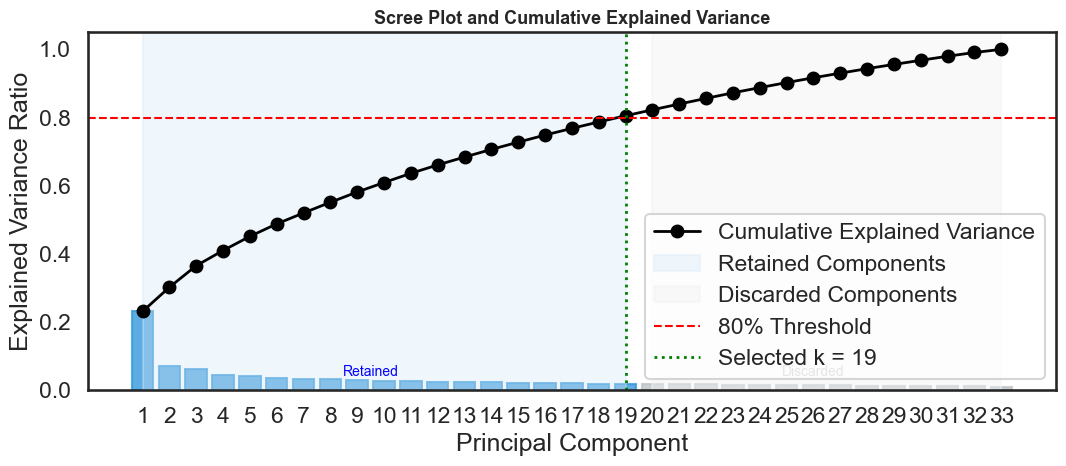

In [ ]:
# ---------------------------------------------------------
# 4. Scree plot with cumulative explained variance
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))

# cumulative variance line
ax.plot(
    range(1, len(cumvar) + 1),
    cumvar,
    marker='o',
    linestyle='-',
    linewidth=2,
    color='black',
    label='Cumulative Explained Variance'
)

# individual variance bars
bars = ax.bar(
    range(1, len(explained_var) + 1),
    explained_var,
    alpha=0.80
)

# color retained vs discarded
for i, bar in enumerate(bars):
    if i < k_80:
        bar.set_color('#3498db')   # retained
    else:
        bar.set_color('#bdc3c7')   # discarded

# highlight retained and discarded regions
ax.axvspan(1, k_80, color='#d6eaf8', alpha=0.35, label='Retained Components')
if k_80 < len(explained_var):
    ax.axvspan(k_80 + 1, len(explained_var), color='#f2f3f4', alpha=0.45, label='Discarded Components')

# threshold and selected k
ax.axhline(0.80, color='red', linestyle='--', linewidth=1.5, label='80% Threshold')
ax.axvline(k_80, color='green', linestyle=':', linewidth=2, label=f'Selected k = {k_80}')

# labels
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot and Cumulative Explained Variance', fontsize=13, fontweight='bold')

# small annotations
ax.text(max(k_80 / 2, 1), 0.04, 'Retained', ha='center', fontsize=10, color='blue')
if k_80 < len(explained_var):
    ax.text((k_80 + len(explained_var)) / 2, 0.04, 'Discarded', ha='center', fontsize=10, color='gray')
ax.set_xticks(range(1, len(explained_var) + 1))
ax.grid(False)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

#### 3.2.1.2 PCA biplot

Purpose: Intuition + direction
Note: 
A biplot has:

- points (students)
- arrows (variables)

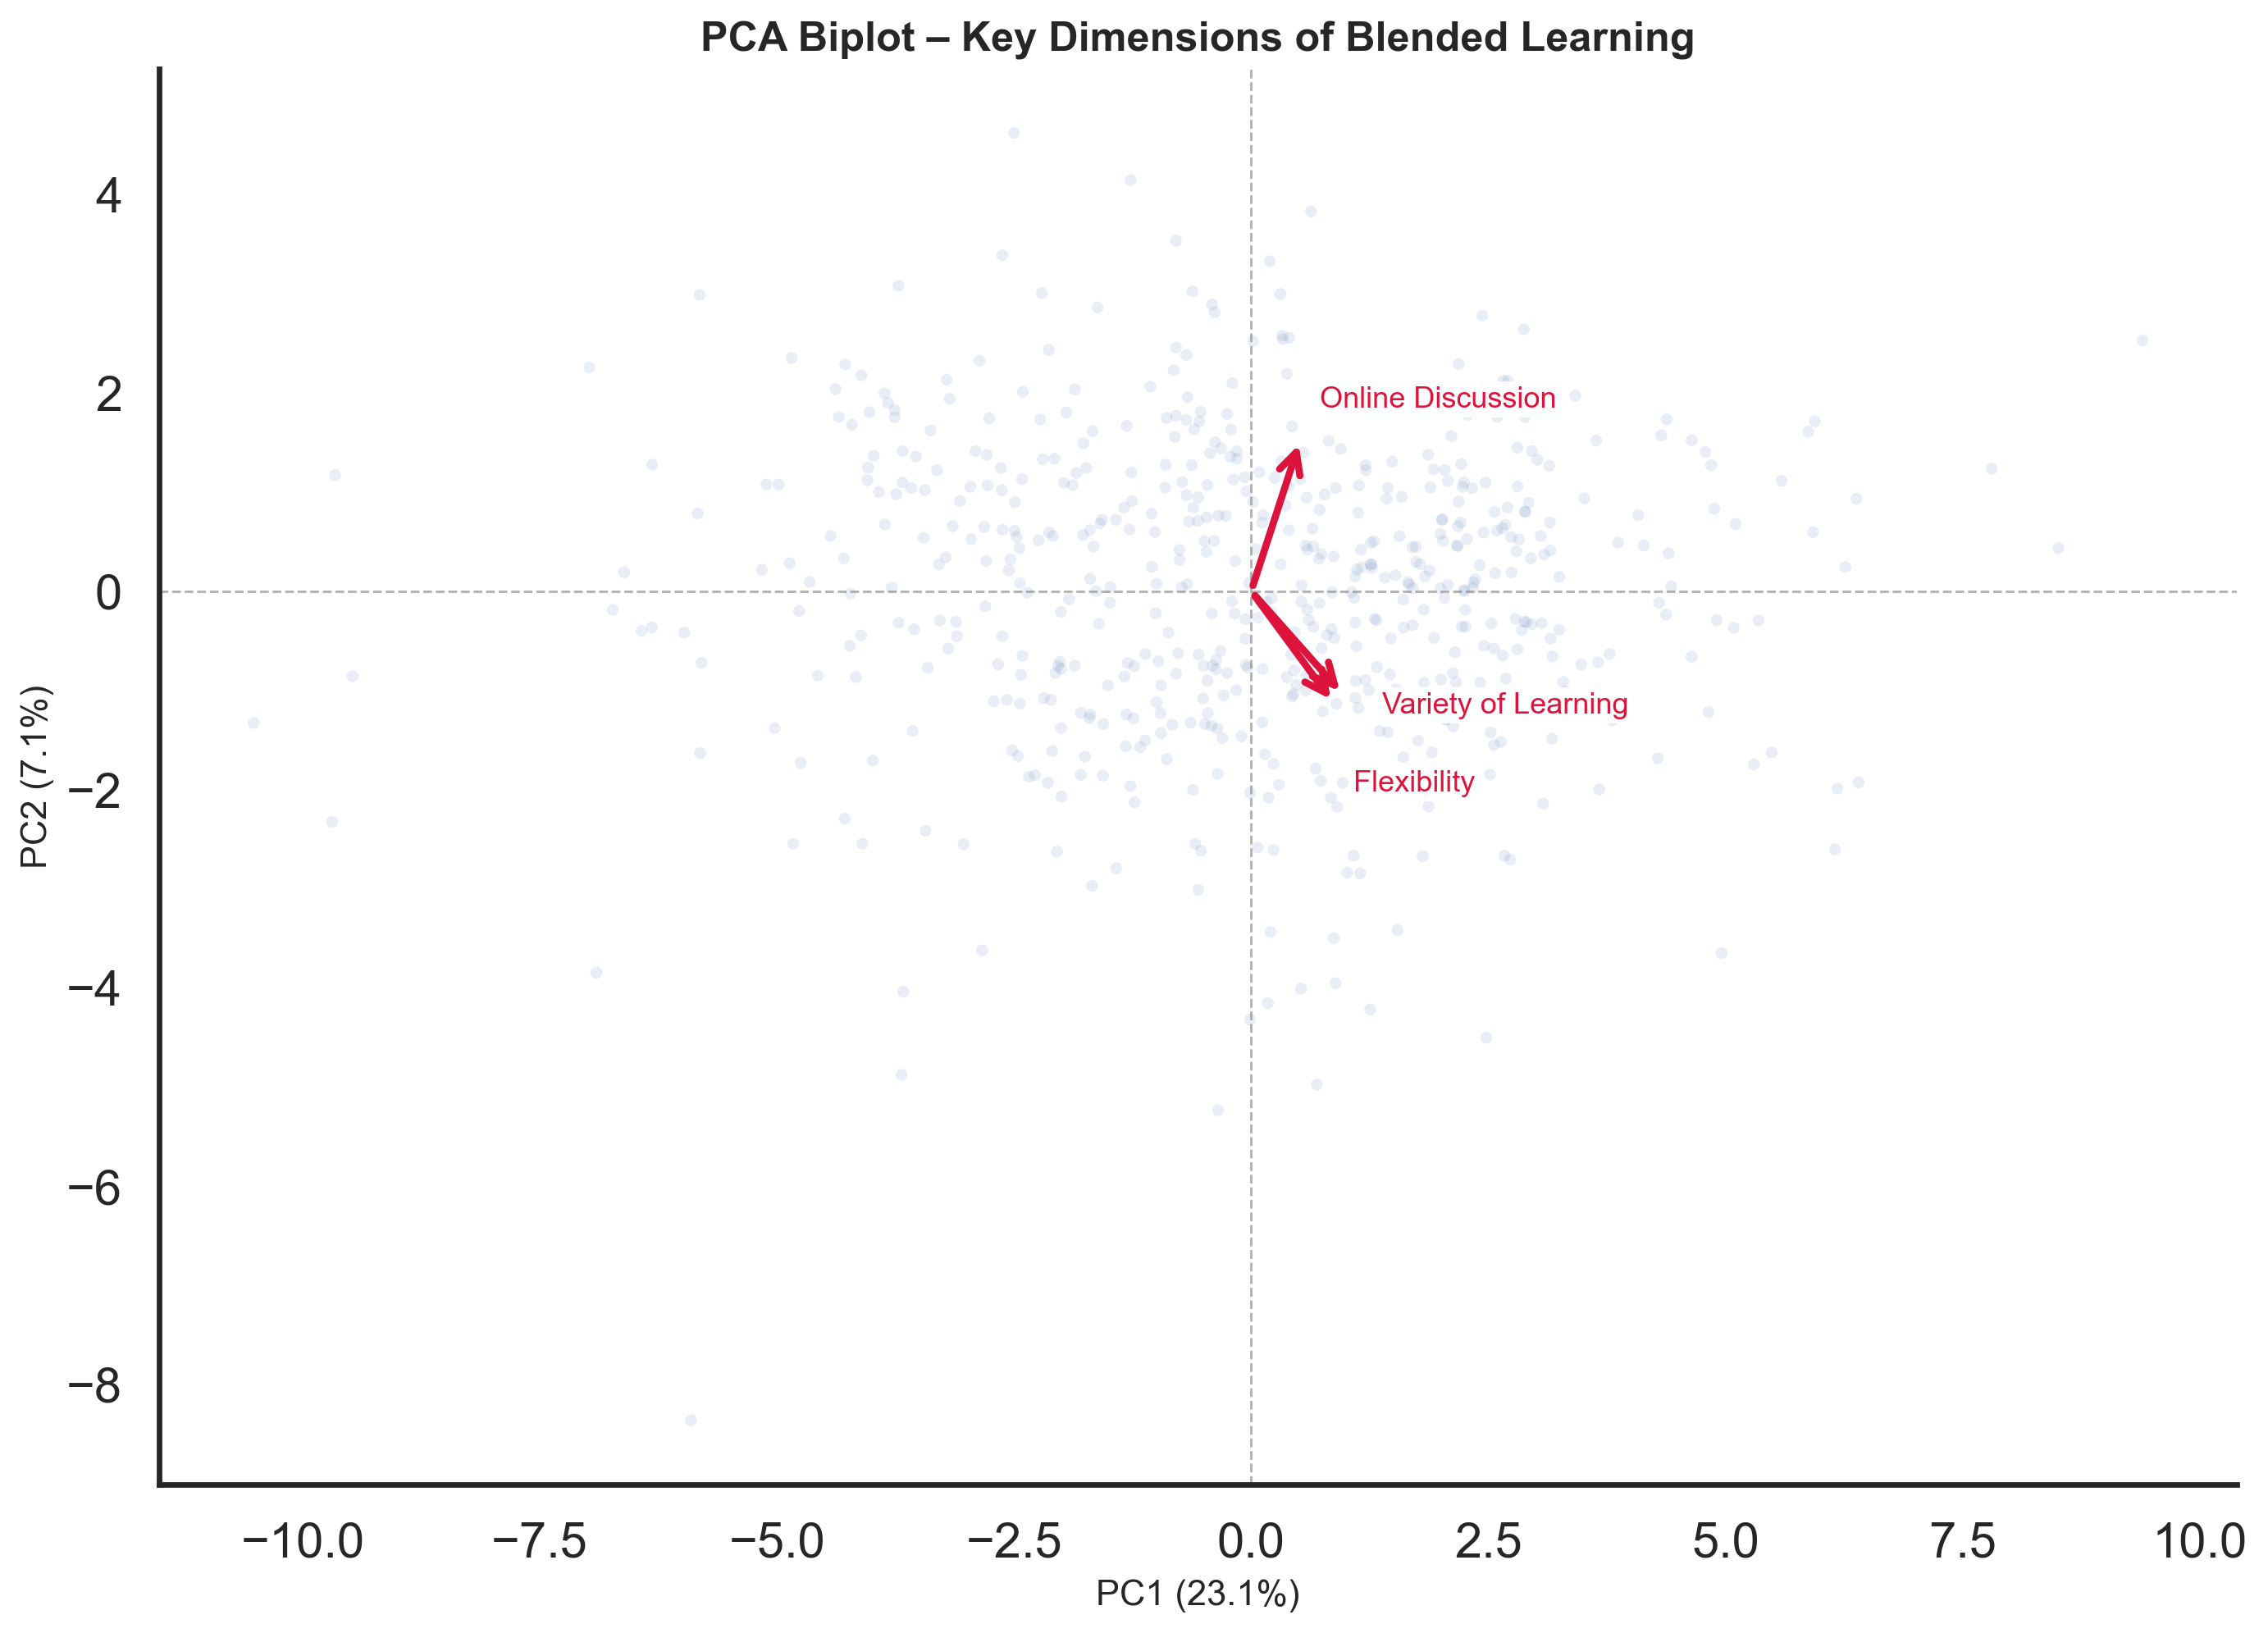

In [ ]:
# ---------------------------------------------------------
# FINAL INTERPRETABLE PCA BIPLOT (THESIS VERSION)
# ---------------------------------------------------------

pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
scores_2d = pca_2.fit_transform(X_sc)

loadings = pca_2.components_.T

#  Manually select 3 most interpretable variables
selected_vars = [
    'online_discussion_participation',
    'benefit_variety',
    'benefit_flexibility'
]

selected_idx = [oridinal_cols.index(v) for v in selected_vars]

label_map = {
    'online_discussion_participation': 'Online Discussion',
    'benefit_variety': 'Variety of Learning',
    'benefit_flexibility': 'Flexibility'
}

fig, ax = plt.subplots(figsize=(11, 8), dpi=260)

# scatter (background)
ax.scatter(
    scores_2d[:, 0],
    scores_2d[:, 1],
    s=16,
    alpha=0.12,
    color='#4c72b0',
    edgecolors='none'
)

# arrow scale
scale = 4.8

# strong manual separation
offsets = {
    'Online Discussion': (0.2, 0.4),       # up
    'Variety of Learning': (0.4, -0.1),    # right
    'Flexibility': (0.2, -0.8)             # down
}

for i in selected_idx:
    x = loadings[i, 0] * scale
    y = loadings[i, 1] * scale

    raw = oridinal_cols[i]
    label = label_map[raw]
    dx, dy = offsets[label]

    ax.annotate(
        '',
        xy=(x, y),
        xytext=(0, 0),
        arrowprops=dict(
            arrowstyle='->',
            color='crimson',
            lw=2.4
        )
    )

    ax.text(
        x + dx,
        y + dy,
        label,
        fontsize=10,
        color='crimson',
        ha='left',
        va='center',
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.9,
            pad=1.5
        )
    )

# axes
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.6)

ax.set_xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)

ax.set_title(
    'PCA Biplot – Key Dimensions of Blended Learning',
    fontsize=14,
    fontweight='bold'
)

# clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

PC1 (horizontal — 21.2%)

All arrows point to the right

Meaning: PC1 represents overall perceived benefits of blended learning

PC2 (vertical — 7.5%)

Clear separation:
- Up (positive PC2) → Online Discussion
- Down (negative PC2) → Flexibility + Variety

Meaning:PC2 represents a contrast between interactive learning and self-paced learning

The PCA biplot reveals two primary dimensions of blended learning. The first principal component (PC1) reflects overall perceived benefits, with all variables contributing positively, indicating that higher values correspond to more favorable learning experiences. The second principal component (PC2) differentiates between interaction-based learning and self-paced learning. Online discussion loads positively on PC2, while flexibility and variety of learning methods load negatively, suggesting a distinction between students who benefit from interactive engagement and those who prefer flexible, independent learning approaches.

#### 3.2.1.3 PCA loadings heatmap

Purpose: full variable detail

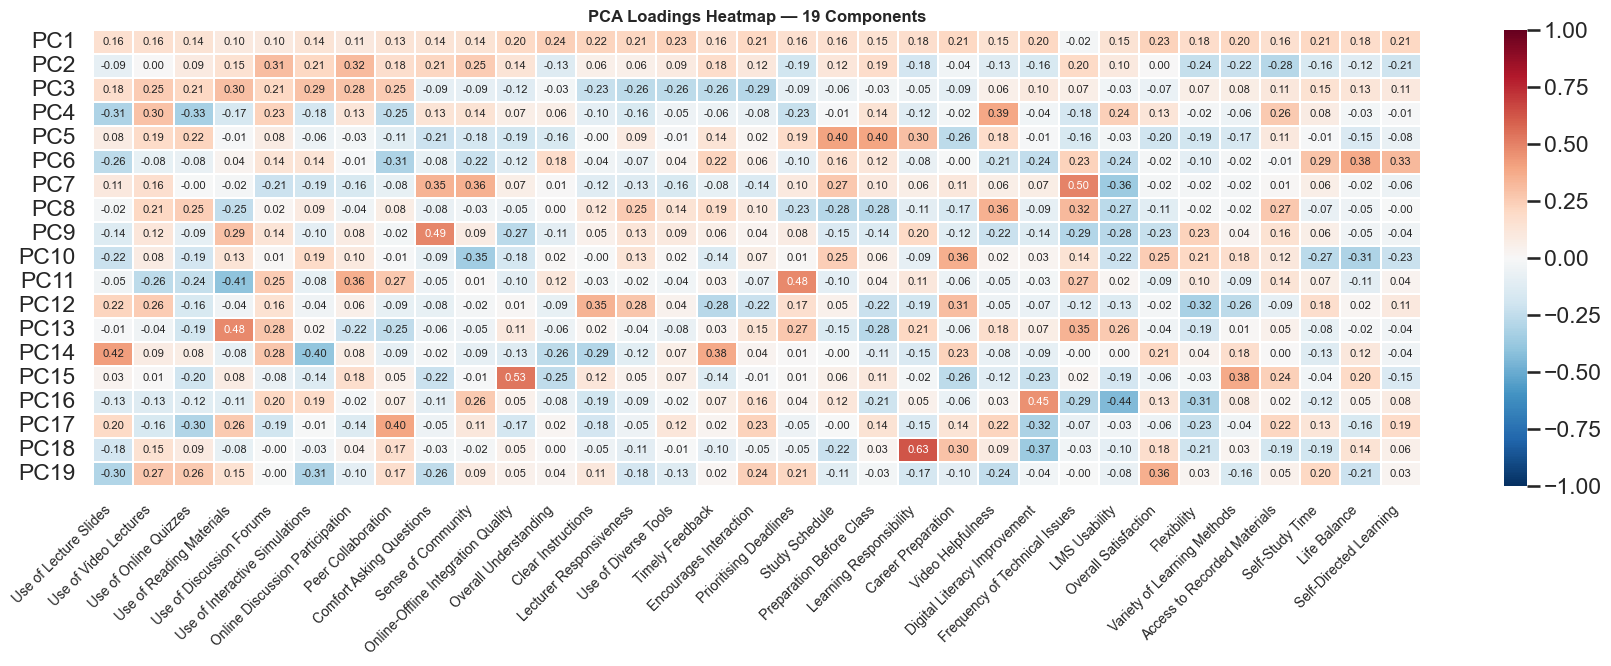

In [ ]:
# ── 5.5 PCA Loadings Heatmap (k_80 components) ───────────────
pca_k = PCA(n_components=min(k_80, 19), random_state=RANDOM_STATE)
pca_k.fit(X_sc)
loadings_df = pd.DataFrame(
    pca_k.components_,
    columns=[pl(c) for c in oridinal_cols],
    index=[f'PC{i+1}' for i in range(pca_k.n_components_)]
)

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.3, annot_kws={'size': 8}, ax=ax)
ax.set_title(f'PCA Loadings Heatmap — {pca_k.n_components_} Components',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout(); plt.show()

The PCA loadings heatmap reveals that the first principal component (PC1) captures a general dimension of blended learning effectiveness, with consistently positive contributions from most variables. This suggests that PC1 reflects overall student perceptions of learning quality and benefits.

In contrast, the second principal component (PC2) differentiates between interaction-based learning (e.g., discussion participation, collaboration) and self-paced learning (e.g., recorded materials, flexibility). This indicates the presence of two distinct learning modes within the blended learning environment.

Subsequent components capture more localized patterns of variation across subsets of variables, confirming that student experiences are multi-dimensional and complex.

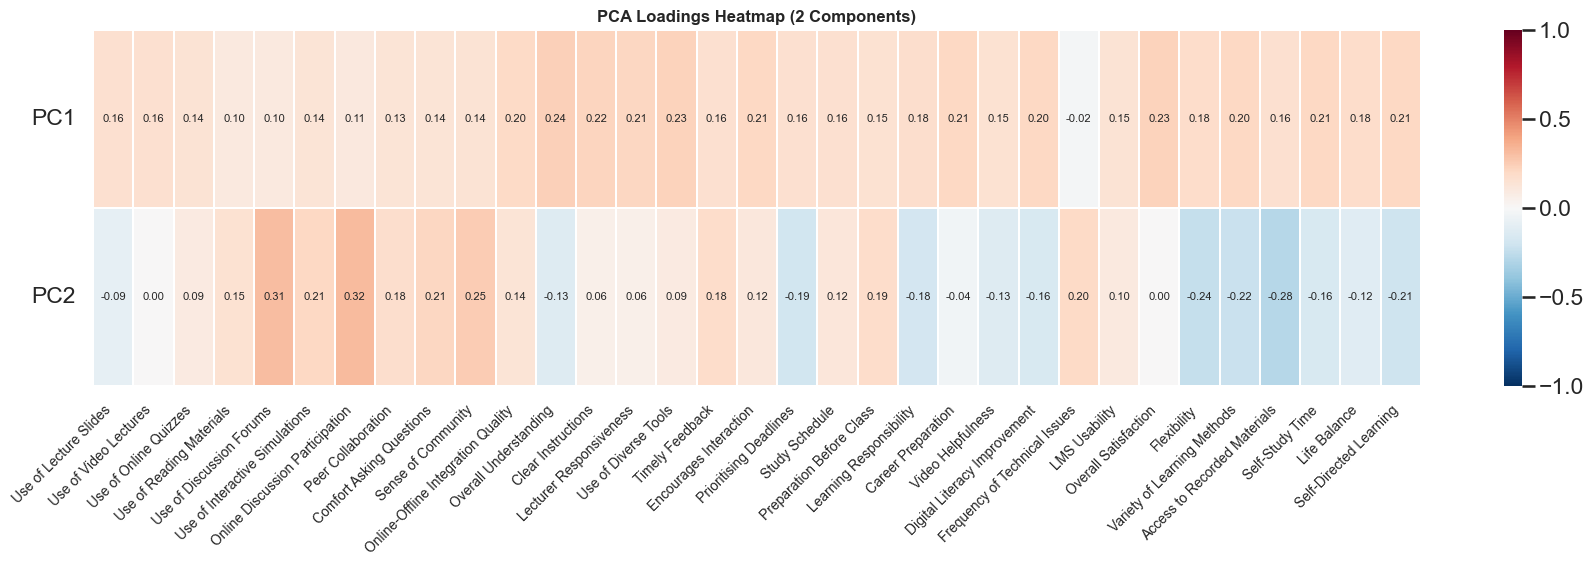

In [ ]:
# ---------------------------------------------------------
#  PCA loadings heatmap
# ---------------------------------------------------------
n_heatmap = min(k_80, 2)   # keep readable for thesis

pca_k = PCA(n_components=n_heatmap, random_state=RANDOM_STATE)
pca_k.fit(X_sc)

loadings_df = pd.DataFrame(
    pca_k.components_,
    columns=[pl(c) for c in oridinal_cols],
    index=[f'PC{i+1}' for i in range(pca_k.n_components_)]
)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    loadings_df,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot_kws={'size': 8},
    ax=ax
)

ax.set_title(f'PCA Loadings Heatmap ({n_heatmap} Components)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()